In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
help(np.std)

Help on _ArrayFunctionDispatcher in module numpy:

std(
    a,
    axis=None,
    dtype=None,
    out=None,
    ddof=0,
    keepdims=<no value>,
    *,
    where=<no value>,
    mean=<no value>,
    correction=<no value>
)
    Compute the standard deviation along the specified axis.

    Returns the standard deviation, a measure of the spread of a distribution,
    of the array elements. The standard deviation is computed for the
    flattened array by default, otherwise over the specified axis.

    Parameters
    ----------
    a : array_like
        Calculate the standard deviation of these values.
    axis : None or int or tuple of ints, optional
        Axis or axes along which the standard deviation is computed. The
        default is to compute the standard deviation of the flattened array.
        If this is a tuple of ints, a standard deviation is performed over
        multiple axes, instead of a single axis or all the axes as before.
    dtype : dtype, optional
        Type 

In [3]:
def g_mean(x):
    a = np.log(x)
    return np.exp(a.mean())
g_mean([4,12,36])

np.float64(12.0)

In [4]:
def standardize(x):
    return((x-np.mean(x))/np.std(x))
standardize([4,12,36])

array([-0.98058068, -0.39223227,  1.37281295])

In [5]:
smash_df = pd.read_csv('../data/updated_final_results.csv')

In [6]:
smash_df['diagnosis'] = smash_df['diagnosis'].str.lower().replace({'cd': 'IBD', 'uc': 'IBD', 'nonibd': 'Control'})

In [7]:
smash_df['total_run_gene_count'] = smash_df.groupby(['run'])['gene_name'].transform('count')
smash_df['gene_count'] = smash_df.groupby(['run', 'gene_name'])['gene_name'].transform('count')
smash_df['gene_mapped_sum'] = smash_df.groupby(['run','gene_name'])['mapped'].transform('sum')

In [8]:
smash_df=smash_df.drop_duplicates(subset=['run','diagnosis','gene_name'], keep='first').reset_index()
smash_df

,index,contig,run,diagnosis,read_count,length,mapped,unmapped,net_mapped,average_depth,gene_name,organism,total_run_gene_count,gene_count,gene_mapped_sum
0,0,GCF_907175785.1_lcl|NZ_CAJSIV010000001.1_cds_W...,SRR6468546,Control,13984243,2388,2,0,2,0.08,pheT,[organism=Escherichia coli str. K-12 substr. M...,22,2,4
1,1,GCF_900480325.1_lcl|NZ_UDAQ01000033.1_cds_WP_0...,SRR6468546,Control,13984243,2673,2,0,2,0.07,infB,[organism=Escherichia coli str. K-12 substr. M...,22,3,6
2,3,GCF_900536585.1_lcl|NZ_UNQF01000043.1_cds_WP_0...,SRR6468546,Control,13984243,279,1,0,1,0.36,rpsS,[organism=Escherichia coli str. K-12 substr. M...,22,1,1
3,4,GCF_900195445.1_lcl|NZ_FZFM01000005.1_cds_WP_0...,SRR6468546,Control,13984243,726,1,1,0,0.04,rpsB,[organism=Escherichia coli str. K-12 substr. M...,22,1,1
4,5,GCF_949281785.1_lcl|NZ_CASDNJ010000003.1_cds_W...,SRR6468546,Control,13984243,375,2,0,2,0.38,rpsL,[organism=Escherichia coli str. K-12 substr. M...,22,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21147,594559,GCF_907175395.1_lcl|NZ_CAJSHA010000002.1_cds_W...,ERR011251,Control,11207870,270,1,1,0,0.28,rpsO,[organism=Escherichia coli str. K-12 substr. M...,45,1,1
21148,594562,GCF_900449835.1_lcl|NZ_UGEI01000001.1_cds_WP_0...,ERR011251,Control,11207870,255,1,1,0,0.29,rpsQ,[organism=Escherichia coli str. K-12 substr. M...,45,2,3
21149,594563,GCF_900479665.1_lcl|NZ_UCYB01000004.1_cds_WP_0...,ERR011251,Control,11207870,333,1,1,0,0.23,rplV,[organism=Escherichia coli str. K-12 substr. M...,45,1,1
21150,594564,GCF_904809735.1_lcl|NZ_CAJGEV010000011.1_cds_W...,ERR011251,Control,11207870,357,1,1,0,0.21,rpsM,[organism=Escherichia coli str. K-12 substr. M...,45,1,1


In [9]:
smash_df['mapped_norm_by_read_count'] = smash_df['gene_mapped_sum']/smash_df['read_count'] * 1_000_000_000

smash_df['mapped_norm_by_contig_length'] = 0.0
smash_df.loc[smash_df['length'] > 0, 'mapped_norm_by_contig_length'] = (
    (smash_df.loc[smash_df['length'] > 0, 'gene_mapped_sum'] / smash_df.loc[smash_df['length'] > 0, 'length']) * 1000
)

smash_df['mapped_norm_by_read_count_and_contig_length'] = 0.0
smash_df.loc[smash_df['length'] > 0, 'mapped_norm_by_read_count_and_contig_length'] = (
    (smash_df.loc[smash_df['length'] > 0, 'mapped_norm_by_read_count'] / smash_df.loc[smash_df['length'] > 0, 'length']) * 1000
)

smash_df['log_map_norm'] = np.log2(smash_df['mapped_norm_by_read_count_and_contig_length'])
smash_df['standardized_norm'] = standardize(smash_df['log_map_norm']) #<- this is standardizing the entire column not grouping by gene_name!!!
                                                                      # see next code block for fix?
smash_df

,index,contig,run,diagnosis,read_count,length,mapped,unmapped,net_mapped,average_depth,gene_name,organism,total_run_gene_count,gene_count,gene_mapped_sum,mapped_norm_by_read_count,mapped_norm_by_contig_length,mapped_norm_by_read_count_and_contig_length,log_map_norm,standardized_norm
0,0,GCF_907175785.1_lcl|NZ_CAJSIV010000001.1_cds_W...,SRR6468546,Control,13984243,2388,2,0,2,0.08,pheT,[organism=Escherichia coli str. K-12 substr. M...,22,2,4,286.036219,1.675042,119.780661,6.904251,-1.716087
1,1,GCF_900480325.1_lcl|NZ_UDAQ01000033.1_cds_WP_0...,SRR6468546,Control,13984243,2673,2,0,2,0.07,infB,[organism=Escherichia coli str. K-12 substr. M...,22,3,6,429.054329,2.244669,160.514152,7.326557,-1.561831
2,3,GCF_900536585.1_lcl|NZ_UNQF01000043.1_cds_WP_0...,SRR6468546,Control,13984243,279,1,0,1,0.36,rpsS,[organism=Escherichia coli str. K-12 substr. M...,22,1,1,71.509055,3.584229,256.304856,8.001717,-1.315213
3,4,GCF_900195445.1_lcl|NZ_FZFM01000005.1_cds_WP_0...,SRR6468546,Control,13984243,726,1,1,0,0.04,rpsB,[organism=Escherichia coli str. K-12 substr. M...,22,1,1,71.509055,1.377410,98.497321,6.622013,-1.819181
4,5,GCF_949281785.1_lcl|NZ_CASDNJ010000003.1_cds_W...,SRR6468546,Control,13984243,375,2,0,2,0.38,rpsL,[organism=Escherichia coli str. K-12 substr. M...,22,2,4,286.036219,10.666667,762.763252,9.575092,-0.740503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21147,594559,GCF_907175395.1_lcl|NZ_CAJSHA010000002.1_cds_W...,ERR011251,Control,11207870,270,1,1,0,0.28,rpsO,[organism=Escherichia coli str. K-12 substr. M...,45,1,1,89.223019,3.703704,330.455627,8.368313,-1.181306
21148,594562,GCF_900449835.1_lcl|NZ_UGEI01000001.1_cds_WP_0...,ERR011251,Control,11207870,255,1,1,0,0.29,rpsQ,[organism=Escherichia coli str. K-12 substr. M...,45,2,3,267.669058,11.764706,1049.682579,10.035737,-0.572241
21149,594563,GCF_900479665.1_lcl|NZ_UCYB01000004.1_cds_WP_0...,ERR011251,Control,11207870,333,1,1,0,0.23,rplV,[organism=Escherichia coli str. K-12 substr. M...,45,1,1,89.223019,3.003003,267.936995,8.065750,-1.291824
21150,594564,GCF_904809735.1_lcl|NZ_CAJGEV010000011.1_cds_W...,ERR011251,Control,11207870,357,1,1,0,0.21,rpsM,[organism=Escherichia coli str. K-12 substr. M...,45,1,1,89.223019,2.801120,249.924423,7.965348,-1.328498


In [10]:
smash_df['log_map_norm_standardized'] = smash_df.groupby(['gene_name', 'diagnosis'])['log_map_norm'].transform(standardize)

# Display summary statistics to verify standardization
print("Summary by run and diagnosis:")
print(smash_df.groupby(['run', 'diagnosis'])['log_map_norm_standardized'].agg(['mean', 'std', 'count']))

# Check for any NaN values (which occur if std=0 for a group)
nan_count = smash_df['log_map_norm_standardized'].isna().sum()
print(f"\nNumber of NaN values in standardized column: {nan_count}")

# Optional: Display first few rows
print("\nFirst few rows with standardized values:")
print(smash_df[['run', 'diagnosis', 'log_map_norm', 'standardized_norm', 'log_map_norm_standardized']].head(10))

Summary by run and diagnosis:
                          mean       std  count
run        diagnosis                           
ERR011087  Control   -1.101975  0.205421      7
ERR011088  Control   -1.039954  0.181217      6
ERR011089  Control   -0.318384  0.289878     30
ERR011090  Control   -0.722456  0.318740     34
ERR011091  Control   -0.420278  0.352271     34
...                        ...       ...    ...
SRR6468714 IBD       -1.207143  0.378540     26
SRR6468715 IBD       -0.076675  0.332028     40
SRR6468716 IBD       -1.139595  0.009479      2
SRR6468717 IBD       -0.923148       NaN      1
SRR6468718 IBD       -1.248721  0.306881     20

[963 rows x 3 columns]

Number of NaN values in standardized column: 0

First few rows with standardized values:
          run diagnosis  log_map_norm  standardized_norm  \
0  SRR6468546   Control      6.904251          -1.716087   
1  SRR6468546   Control      7.326557          -1.561831   
2  SRR6468546   Control      8.001717          -1.31

In [11]:
smash_df

,index,contig,run,diagnosis,read_count,length,mapped,unmapped,net_mapped,average_depth,...,organism,total_run_gene_count,gene_count,gene_mapped_sum,mapped_norm_by_read_count,mapped_norm_by_contig_length,mapped_norm_by_read_count_and_contig_length,log_map_norm,standardized_norm,log_map_norm_standardized
0,0,GCF_907175785.1_lcl|NZ_CAJSIV010000001.1_cds_W...,SRR6468546,Control,13984243,2388,2,0,2,0.08,...,[organism=Escherichia coli str. K-12 substr. M...,22,2,4,286.036219,1.675042,119.780661,6.904251,-1.716087,-0.882602
1,1,GCF_900480325.1_lcl|NZ_UDAQ01000033.1_cds_WP_0...,SRR6468546,Control,13984243,2673,2,0,2,0.07,...,[organism=Escherichia coli str. K-12 substr. M...,22,3,6,429.054329,2.244669,160.514152,7.326557,-1.561831,-0.785006
2,3,GCF_900536585.1_lcl|NZ_UNQF01000043.1_cds_WP_0...,SRR6468546,Control,13984243,279,1,0,1,0.36,...,[organism=Escherichia coli str. K-12 substr. M...,22,1,1,71.509055,3.584229,256.304856,8.001717,-1.315213,-1.399910
3,4,GCF_900195445.1_lcl|NZ_FZFM01000005.1_cds_WP_0...,SRR6468546,Control,13984243,726,1,1,0,0.04,...,[organism=Escherichia coli str. K-12 substr. M...,22,1,1,71.509055,1.377410,98.497321,6.622013,-1.819181,-1.433211
4,5,GCF_949281785.1_lcl|NZ_CASDNJ010000003.1_cds_W...,SRR6468546,Control,13984243,375,2,0,2,0.38,...,[organism=Escherichia coli str. K-12 substr. M...,22,2,4,286.036219,10.666667,762.763252,9.575092,-0.740503,-0.684026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21147,594559,GCF_907175395.1_lcl|NZ_CAJSHA010000002.1_cds_W...,ERR011251,Control,11207870,270,1,1,0,0.28,...,[organism=Escherichia coli str. K-12 substr. M...,45,1,1,89.223019,3.703704,330.455627,8.368313,-1.181306,-1.283348
21148,594562,GCF_900449835.1_lcl|NZ_UGEI01000001.1_cds_WP_0...,ERR011251,Control,11207870,255,1,1,0,0.29,...,[organism=Escherichia coli str. K-12 substr. M...,45,2,3,267.669058,11.764706,1049.682579,10.035737,-0.572241,-0.644279
21149,594563,GCF_900479665.1_lcl|NZ_UCYB01000004.1_cds_WP_0...,ERR011251,Control,11207870,333,1,1,0,0.23,...,[organism=Escherichia coli str. K-12 substr. M...,45,1,1,89.223019,3.003003,267.936995,8.065750,-1.291824,-1.249650
21150,594564,GCF_904809735.1_lcl|NZ_CAJGEV010000011.1_cds_W...,ERR011251,Control,11207870,357,1,1,0,0.21,...,[organism=Escherichia coli str. K-12 substr. M...,45,1,1,89.223019,2.801120,249.924423,7.965348,-1.328498,-1.261844


In [12]:
# Check that the minimum value is > 0
min(smash_df['average_depth'])

0.01

In [13]:
# Check that the minimum value is > 0
min(smash_df['log_map_norm'])

3.1635695925112066

In [14]:
# Check that the minimum value is > 0
max(smash_df['log_map_norm'])

18.745887494581385

In [15]:
# the geometric mean of the SCGs
allowed = ["hemC",'infB','pheS','pheT','rnhB','rplA','rplB','rplC','rplD','rplE','rplF','rplJ','rplK','rplM','rplN','rplO','rplP','rplR','rplV','rplX','rplY','rpmC','rpsA','rpsB', 'rpsC','rpsE','rpsG','rpsH','rpsI','rpsJ','rpsK','rpsL','rpsM','rpsO','rpsQ','rpsS','truB']
scg_control_log_map_norm_list = smash_df.loc[
                                    (smash_df["gene_name"].isin(allowed)) &
                                    (smash_df["diagnosis"] == "Control"), 
                                    "log_map_norm"
    ].tolist()
scg_control_g_mean = g_mean(scg_control_log_map_norm_list)
scg_control_g_mean

np.float64(10.841701992455553)

In [16]:
scg_control_log_map_norm_df = smash_df.loc[
                                    (smash_df["gene_name"].isin(allowed)) &
                                    (smash_df["diagnosis"] == "Control"), 
                                    ["gene_name","log_map_norm"]
    ]
scg_control_gmeans_df = scg_control_log_map_norm_df.groupby("gene_name")["log_map_norm"].apply(g_mean)
scg_control_gmeans_df

gene_name
hemC    10.467160
infB     9.399199
pheS    10.214440
pheT     9.223610
rnhB    11.053395
rplA    10.613676
rplB    10.670856
rplC    10.686010
rplD    11.010674
rplE    11.003504
rplF    11.048540
rplJ    11.156133
rplK    10.987958
rplM    11.247451
rplN    10.870338
rplO    11.082622
rplP    11.217852
rplR    11.447323
rplV    11.267567
rplX    11.441414
rplY    11.244008
rpmC    11.816405
rpsA     9.529238
rpsB    10.445362
rpsC    10.245356
rpsE    11.001038
rpsG    11.102999
rpsH    11.380420
rpsI    11.136388
rpsJ    11.524326
rpsK    11.230635
rpsL    11.119635
rpsM    11.147488
rpsO    11.501664
rpsQ    11.483785
rpsS    11.511728
truB    10.242448
Name: log_map_norm, dtype: float64

In [17]:
# the geometric mean of the IBD - result implies less bacteria?
scg_list = ["hemC",'infB','pheS','pheT','rnhB','rplA','rplB','rplC','rplD','rplE','rplF','rplJ','rplK','rplM','rplN','rplO','rplP','rplR','rplV','rplX','rplY','rpmC','rpsA','rpsB', 'rpsC','rpsE','rpsG','rpsH','rpsI','rpsJ','rpsK','rpsL','rpsM','rpsO','rpsQ','rpsS','truB']
scg_case_log_map_norm_list = smash_df.loc[
                            (smash_df["gene_name"].isin(scg_list)) &
                            (smash_df["diagnosis"] == "IBD"), 
                            "log_map_norm"
    ].tolist()
scg_case_g_mean = g_mean(scg_case_log_map_norm_list)
scg_case_g_mean

np.float64(11.512389443217938)

In [18]:
scg_case_log_map_norm_df = smash_df.loc[
                                    (smash_df["gene_name"].isin(scg_list)) &
                                    (smash_df["diagnosis"] == "IBD"), 
                                    ["gene_name","log_map_norm"]
    ]
scg_case_gmeans_df = scg_case_log_map_norm_df.groupby("gene_name")["log_map_norm"].apply(g_mean)
scg_case_gmeans_df

gene_name
hemC    11.133499
infB    10.204573
pheS    11.006821
pheT    10.229753
rnhB    11.381555
rplA    11.196584
rplB    11.105386
rplC    11.419696
rplD    11.374553
rplE    11.523414
rplF    11.603545
rplJ    11.668190
rplK    11.772698
rplM    11.874898
rplN    11.845026
rplO    11.825274
rplP    11.897097
rplR    11.962928
rplV    12.049846
rplX    12.059436
rplY    11.834315
rpmC    12.335990
rpsA    10.548112
rpsB    11.192232
rpsC    11.051915
rpsE    11.567502
rpsG    11.534991
rpsH    11.803852
rpsI    11.792648
rpsJ    12.016268
rpsK    11.870665
rpsL    11.840914
rpsM    12.032837
rpsO    12.181391
rpsQ    12.261617
rpsS    12.171191
truB    10.979858
Name: log_map_norm, dtype: float64

In [19]:
# the geometric mean of the GoI
goi_list = ["STM3354","STM3355","ttdA","ttdB"]
goi_control_log_map_norm_list = smash_df.loc[
    (smash_df["gene_name"].isin(goi_list)) &
    (smash_df["diagnosis"] == "Control"),
     "log_map_norm"
     ].tolist()
goi_control_g_mean = g_mean(goi_control_log_map_norm_list)
goi_control_g_mean

np.float64(10.480600334905855)

In [20]:
goi_control_log_map_norm_df = smash_df.loc[
                                    (smash_df["gene_name"].isin(goi_list)) &
                                    (smash_df["diagnosis"] == "Control"), 
                                    ["gene_name","log_map_norm"]
    ]
goi_control_gmeans_df = goi_control_log_map_norm_df.groupby("gene_name")["log_map_norm"].apply(g_mean)
goi_control_gmeans_df

gene_name
STM3354     9.649194
STM3355     8.769216
ttdA       10.380943
ttdB       10.979601
Name: log_map_norm, dtype: float64

In [21]:
# the geometric mean of the GoI
goi_list = ["STM3354","STM3355","ttdA","ttdB"]
goi_case_log_map_norm_list = smash_df.loc[
    (smash_df["gene_name"].isin(goi_list)) &
    (smash_df["diagnosis"] == "IBD"),
     "log_map_norm"
     ].tolist()
goi_case_g_mean = g_mean(goi_case_log_map_norm_list)
goi_case_g_mean

np.float64(10.72132173598638)

In [22]:
goi_case_log_map_norm_df = smash_df.loc[
                                    (smash_df["gene_name"].isin(goi_list)) &
                                    (smash_df["diagnosis"] == "IBD"), 
                                    ["gene_name","log_map_norm"]
    ]
goi_case_gmeans_df = goi_case_log_map_norm_df.groupby("gene_name")["log_map_norm"].apply(g_mean)
goi_case_gmeans_df

gene_name
STM3354     9.482142
STM3355     7.593073
ttdA       11.106194
ttdB       11.309732
Name: log_map_norm, dtype: float64

<Axes: xlabel='lab'>

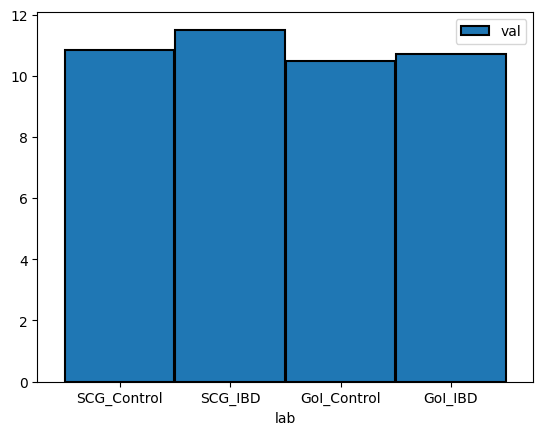

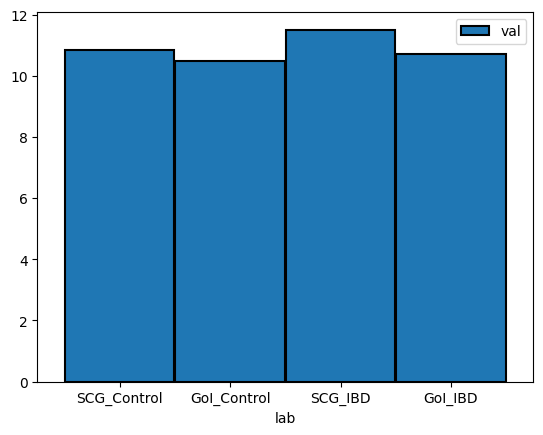

In [23]:
df = pd.DataFrame({
    "SCG_Control": [scg_control_g_mean],
    "SCG_IBD": [scg_case_g_mean],
    "GoI_Control": [goi_control_g_mean],
    "GoI_IBD": [goi_case_g_mean]
})
df

df = pd.DataFrame({
    'lab': ["SCG_Control", "SCG_IBD", "GoI_Control", "GoI_IBD"],
    'val': [scg_control_g_mean,scg_case_g_mean,goi_control_g_mean,goi_case_g_mean],
})
df.plot.bar(x='lab', y='val', rot=0, width=.99, edgecolor='black', linewidth=1.5)

df = pd.DataFrame({
    'lab': ["SCG_Control", "GoI_Control", "SCG_IBD", "GoI_IBD"],
    'val': [scg_control_g_mean,goi_control_g_mean,scg_case_g_mean,goi_case_g_mean],
})
df.plot.bar(x='lab', y='val', rot=0, width=.99, edgecolor='black', linewidth=1.5)

<Axes: xlabel='gene_name'>

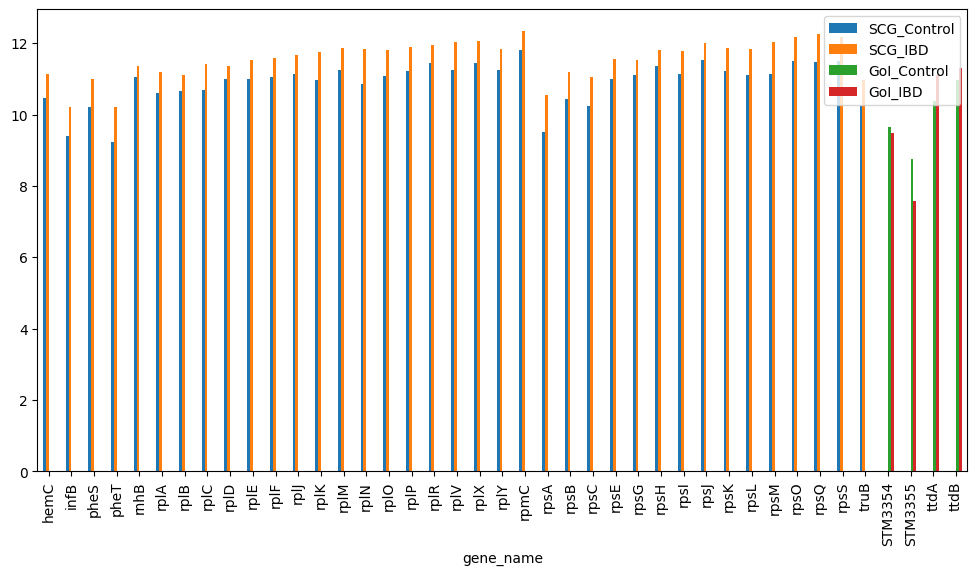

In [24]:
combined = pd.concat(
    [scg_control_gmeans_df, scg_case_gmeans_df, goi_control_gmeans_df, goi_case_gmeans_df],
    axis=1
)

combined.columns = ["SCG_Control", "SCG_IBD", "GoI_Control", "GoI_IBD"]

combined.plot.bar(figsize=(12,6))

In [25]:
scg_diff = scg_case_gmeans_df - scg_control_gmeans_df
goi_diff = goi_case_gmeans_df - goi_control_gmeans_df
scg_diff
goi_diff

gene_name
STM3354   -0.167052
STM3355   -1.176143
ttdA       0.725252
ttdB       0.330131
Name: log_map_norm, dtype: float64

In [26]:
diff = pd.concat(
    {
        "SCG": scg_diff,
        "GOI": goi_diff
    }
).to_frame("GOI_SCG")
diff = diff.reset_index(names=["group", "gene_name"])
diff

,group,gene_name,GOI_SCG
0,SCG,hemC,0.666340
1,SCG,infB,0.805375
2,SCG,pheS,0.792380
3,SCG,pheT,1.006142
4,SCG,rnhB,0.328160
5,SCG,rplA,0.582908
6,SCG,rplB,0.434530
7,SCG,rplC,0.733686
8,SCG,rplD,0.363879
9,SCG,rplE,0.519910


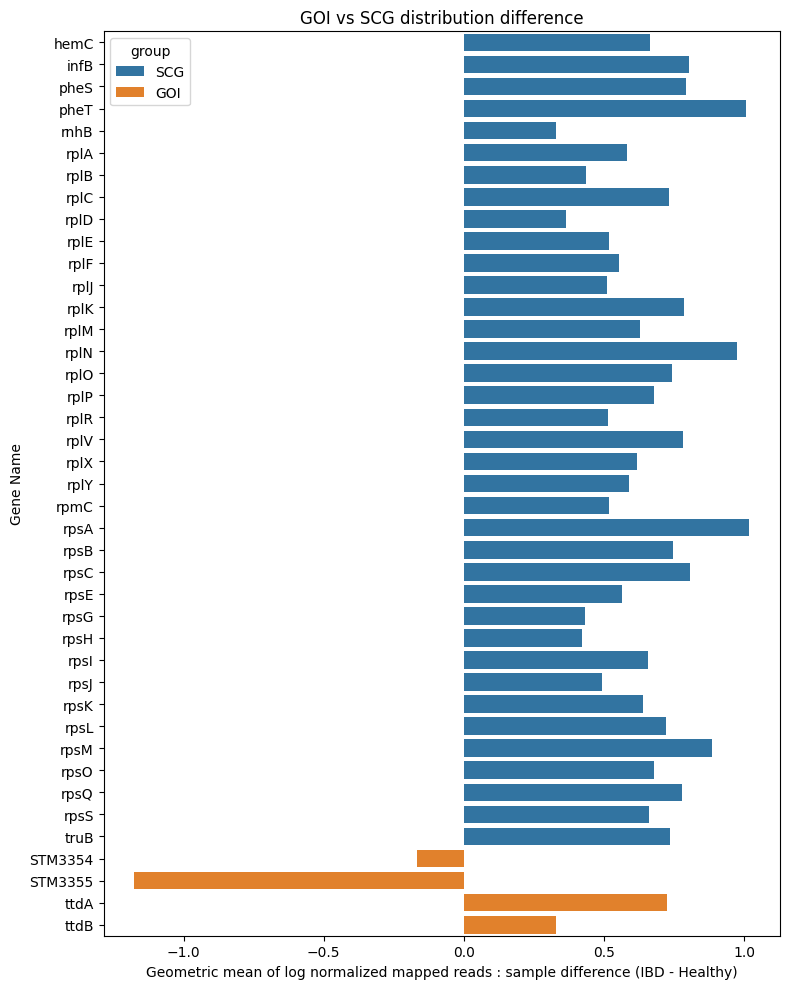

In [27]:
plt.figure(figsize=(8, 10))
sns.barplot(
    data=diff,
    y="gene_name",
    x="GOI_SCG",
    hue='group'
)

plt.xlabel("Geometric mean of log normalized mapped reads : sample difference (IBD - Healthy)")
plt.ylabel("Gene Name")
plt.title("GOI vs SCG distribution difference")

plt.tight_layout()
plt.savefig('geo_mean_diff.png', dpi=300, bbox_inches='tight')
plt.show()


In [28]:
print('Number of samples for each diagnosis')
smash_df.groupby(['diagnosis'])['run'].nunique()

Number of samples for each diagnosis


diagnosis
Control    317
IBD        646
Name: run, dtype: int64

In [29]:
print('Number of samples for each diagnosis')
smash_df.groupby(['gene_name'])['run'].nunique()

Number of samples for each diagnosis


gene_name
STM3354    199
STM3355     42
hemC       536
infB       686
pheS       527
pheT       612
rnhB       480
rplA       625
rplB       595
rplC       563
rplD       552
rplE       552
rplF       524
rplJ       542
rplK       524
rplM       494
rplN       590
rplO       512
rplP       513
rplR       500
rplV       503
rplX       508
rplY       434
rpmC       437
rpsA       653
rpsB       596
rpsC       681
rpsE       547
rpsG       560
rpsH       521
rpsI       504
rpsJ       493
rpsK       524
rpsL       513
rpsM       505
rpsO       471
rpsQ       478
rpsS       503
truB       549
ttdA       522
ttdB       482
Name: run, dtype: int64

In [30]:
print('Subsetting the dataframe by the number of controls to give an even weight to the study...?')
sample_counts = smash_df.groupby('run').first().reset_index()
print(sample_counts.head())

control = sample_counts[sample_counts['diagnosis'] == 'Control']['run']
n = len(control)
print("Using", n, 'case samples')

case = sample_counts[sample_counts['diagnosis'] == 'IBD']['run'].sample(n=n, random_state=42)
print(case.head())
df_subset = smash_df[smash_df['run'].isin(control.tolist() + case.tolist())]


Subsetting the dataframe by the number of controls to give an even weight to the study...?
         run   index                                             contig  \
0  ERR011087  584561  GCF_907175515.1_lcl|NZ_CAJSHP010000006.1_cds_W...   
1  ERR011088  118378  GCF_900195835.1_lcl|NZ_FZGS01000004.1_cds_WP_0...   
2  ERR011089   79709  GCF_030491335.1_lcl|NZ_JAGUCS010000063.1_cds_W...   
3  ERR011090  526308  GCF_039682635.1_lcl|NZ_JBDKNQ010000063.1_cds_W...   
4  ERR011091  473212  GCA_003150815.1_lcl|CP028704.1_cds_AWM70317.1_...   

  diagnosis  read_count  length  mapped  unmapped  net_mapped  average_depth  \
0   Control    11640976     726       2         0           2           0.12   
1   Control    10868175    1674       1         1           0           0.02   
2   Control     4190512    2388       2         0           2           0.06   
3   Control    11169067    2388       2         0           2           0.06   
4   Control     7928489    1674       1         1         

In [31]:
long_table = (
    smash_df
    .groupby(['run', 'gene_name', 'diagnosis'])['log_map_norm']
    .sum()
    .reset_index()
)
long_table

,run,gene_name,diagnosis,log_map_norm
0,ERR011087,rplA,Control,8.513912
1,ERR011087,rplC,Control,8.091220
2,ERR011087,rplN,Control,7.851270
3,ERR011087,rpsA,Control,5.681345
4,ERR011087,rpsB,Control,7.886603
...,...,...,...,...
21147,SRR6468718,rpsK,IBD,8.894807
21148,SRR6468718,rpsL,IBD,7.951391
21149,SRR6468718,rpsO,IBD,9.425322
21150,SRR6468718,rpsQ,IBD,9.507784


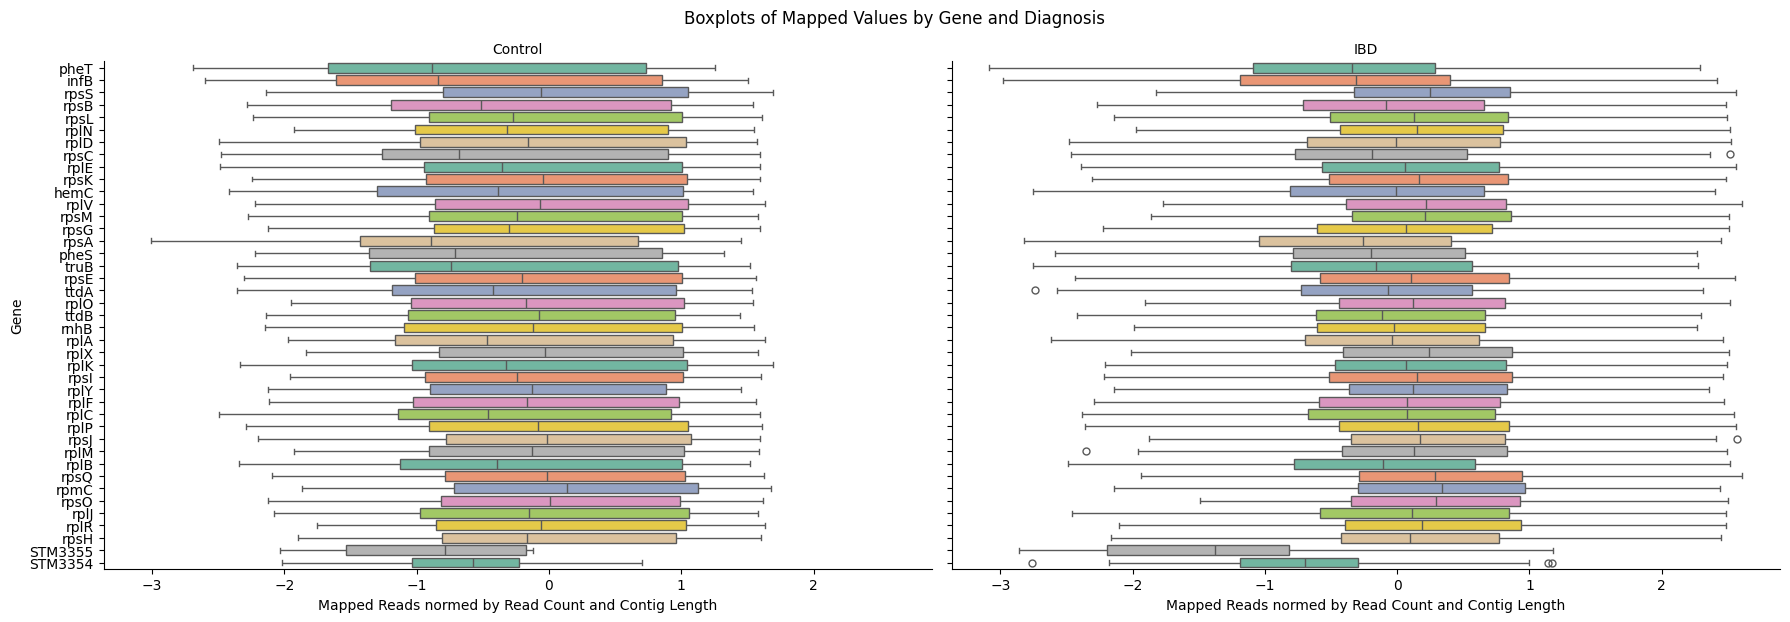

In [32]:
p = sns.catplot(
    data=smash_df,
    x="standardized_norm",
    y="gene_name",
    hue="gene_name", 
    kind="box",
    col="diagnosis",
    palette="Set2",
    height=6,
    aspect=1.5
)
p.set_titles(col_template="{col_name}")
p.set_xlabels("Mapped Reads normed by Read Count and Contig Length")
p.set_ylabels("Gene")

plt.suptitle("Boxplots of Mapped Values by Gene and Diagnosis", y=1.03)
plt.show()

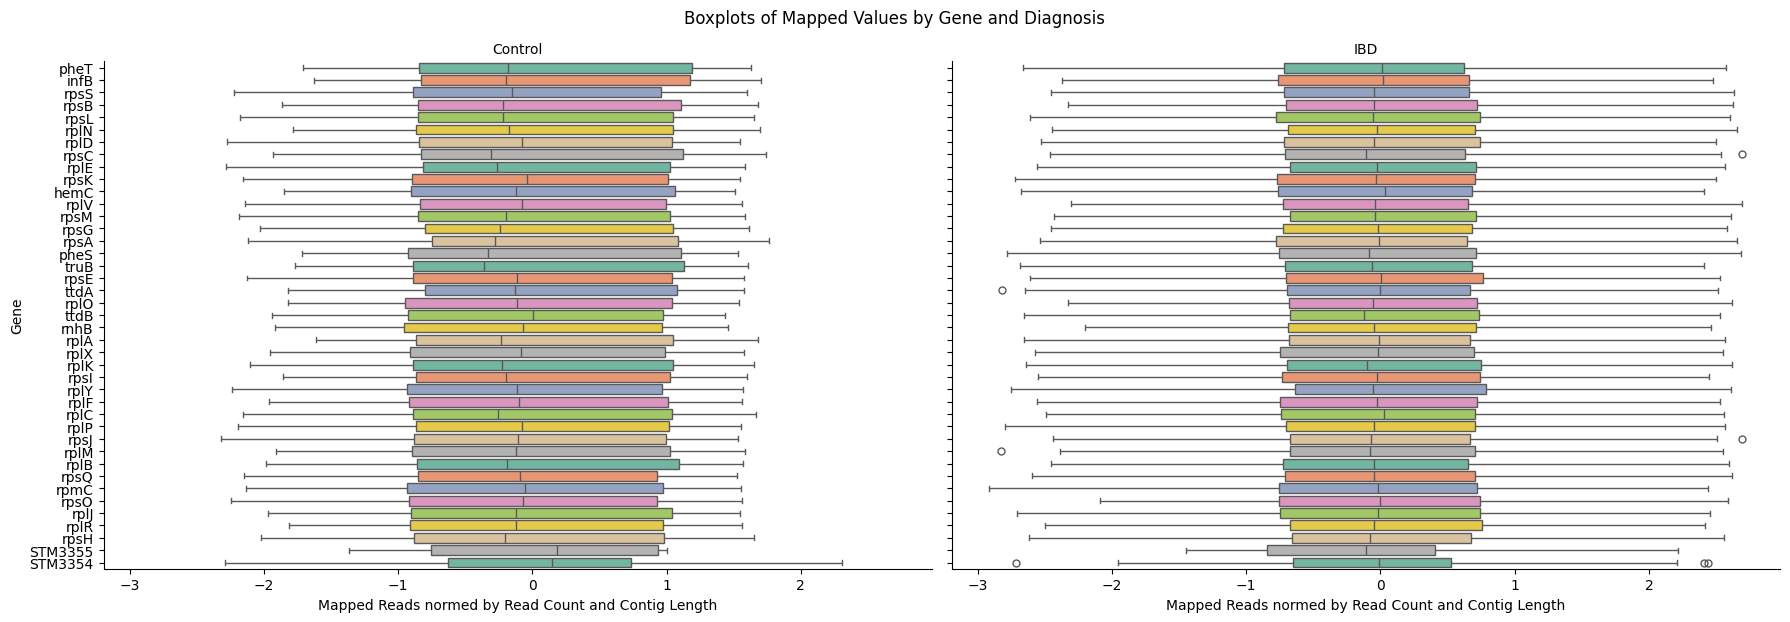

In [33]:
p = sns.catplot(
    data=smash_df,
    x="log_map_norm_standardized", #"standardized_norm"
    y="gene_name",
    hue="gene_name", 
    kind="box",
    col="diagnosis",
    palette="Set2",
    height=6,
    aspect=1.5
)
p.set_titles(col_template="{col_name}")
p.set_xlabels("Mapped Reads normed by Read Count and Contig Length")
p.set_ylabels("Gene")

plt.suptitle("Boxplots of Mapped Values by Gene and Diagnosis", y=1.03)
plt.show()

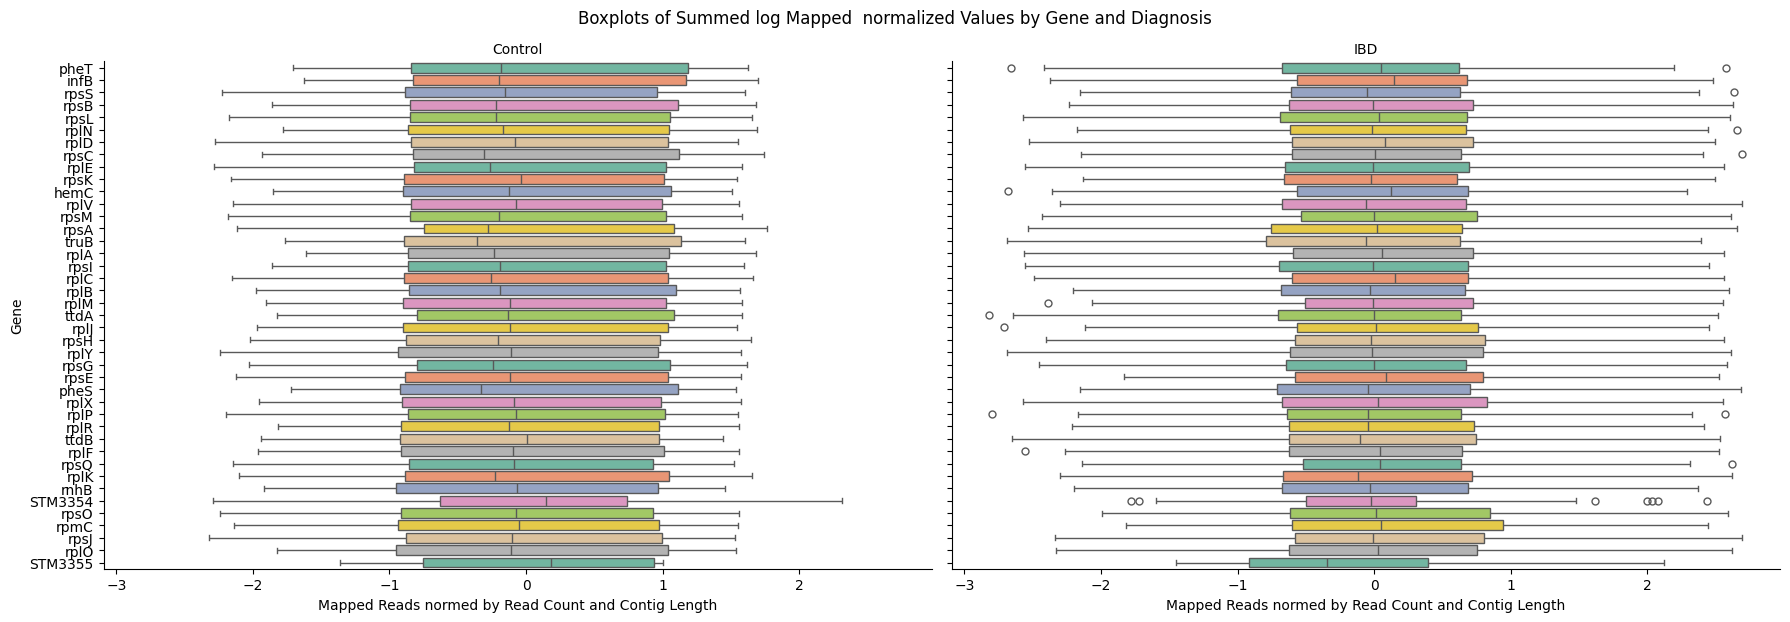

In [34]:
p = sns.catplot(
    data=df_subset,
    x="log_map_norm_standardized",
    y="gene_name",
    hue="gene_name", 
    kind="box",
    col="diagnosis",
    palette="Set2",
    height=6,
    aspect=1.5
)
p.set_titles(col_template="{col_name}")
p.set_xlabels("Mapped Reads normed by Read Count and Contig Length")
p.set_ylabels("Gene")

plt.suptitle("Boxplots of Summed log Mapped  normalized Values by Gene and Diagnosis", y=1.03)
plt.show()

In [35]:
# the list of gene names to remove
genes_to_remove = ['infB', 'pheT', 'rpsA']

filtered_df = smash_df[~smash_df['gene_name'].isin(genes_to_remove)]
filtered_subset_df = df_subset[~df_subset['gene_name'].isin(genes_to_remove)]

In [36]:
filtered_table = (
    filtered_df
    .groupby(['run', 'gene_name', 'diagnosis'])['standardized_norm']
    .sum()
    .reset_index()
)
filtered_subset_table = (
    filtered_subset_df
    .groupby(['run', 'gene_name', 'diagnosis'])['standardized_norm']
    .sum()
    .reset_index()
)

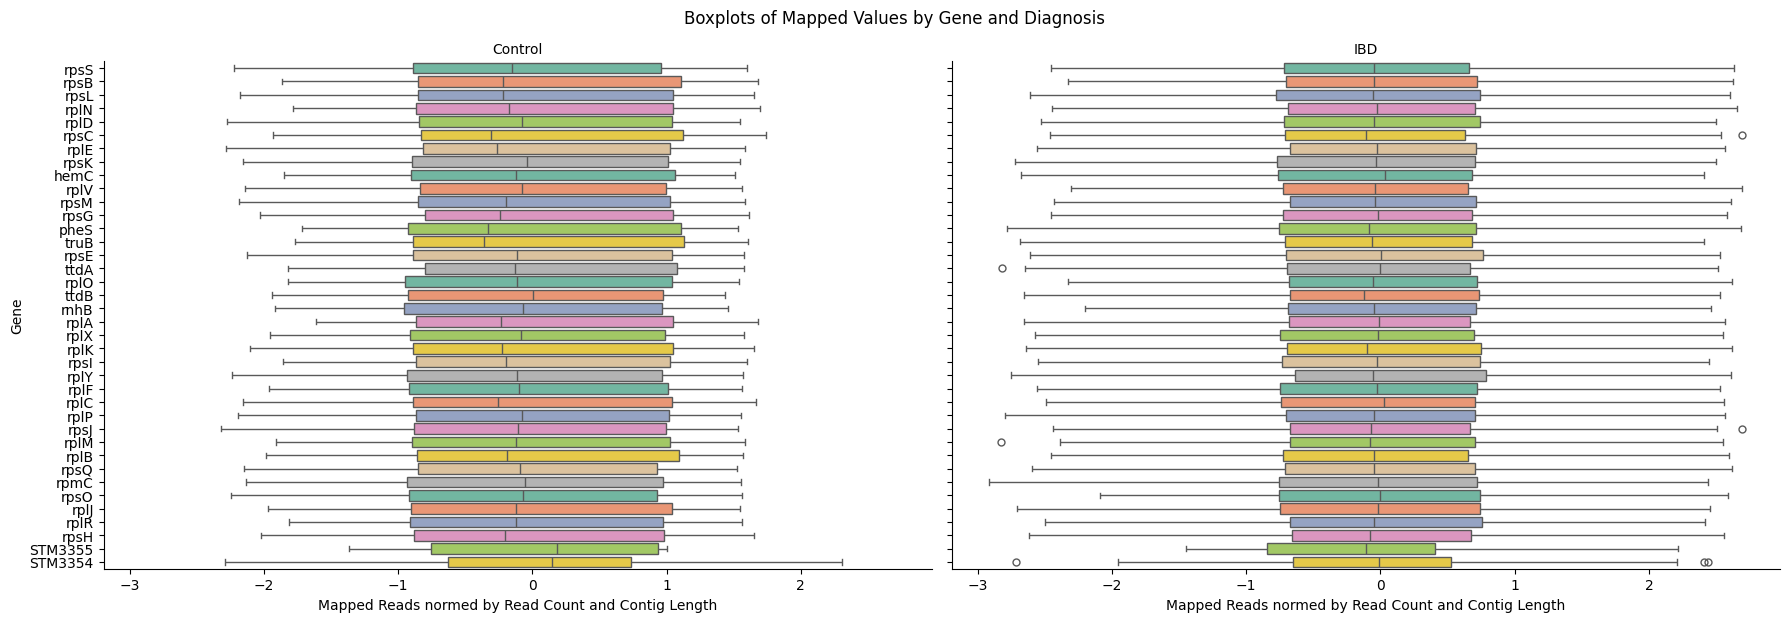

In [37]:
p = sns.catplot(
    data=filtered_df,
    x="log_map_norm_standardized",
    y="gene_name",
    hue="gene_name", 
    kind="box",
    col="diagnosis",
    palette="Set2",
    height=6,
    aspect=1.5
)
p.set_titles(col_template="{col_name}")
p.set_xlabels("Mapped Reads normed by Read Count and Contig Length")
p.set_ylabels("Gene")

plt.suptitle("Boxplots of Mapped Values by Gene and Diagnosis", y=1.03)
plt.show()

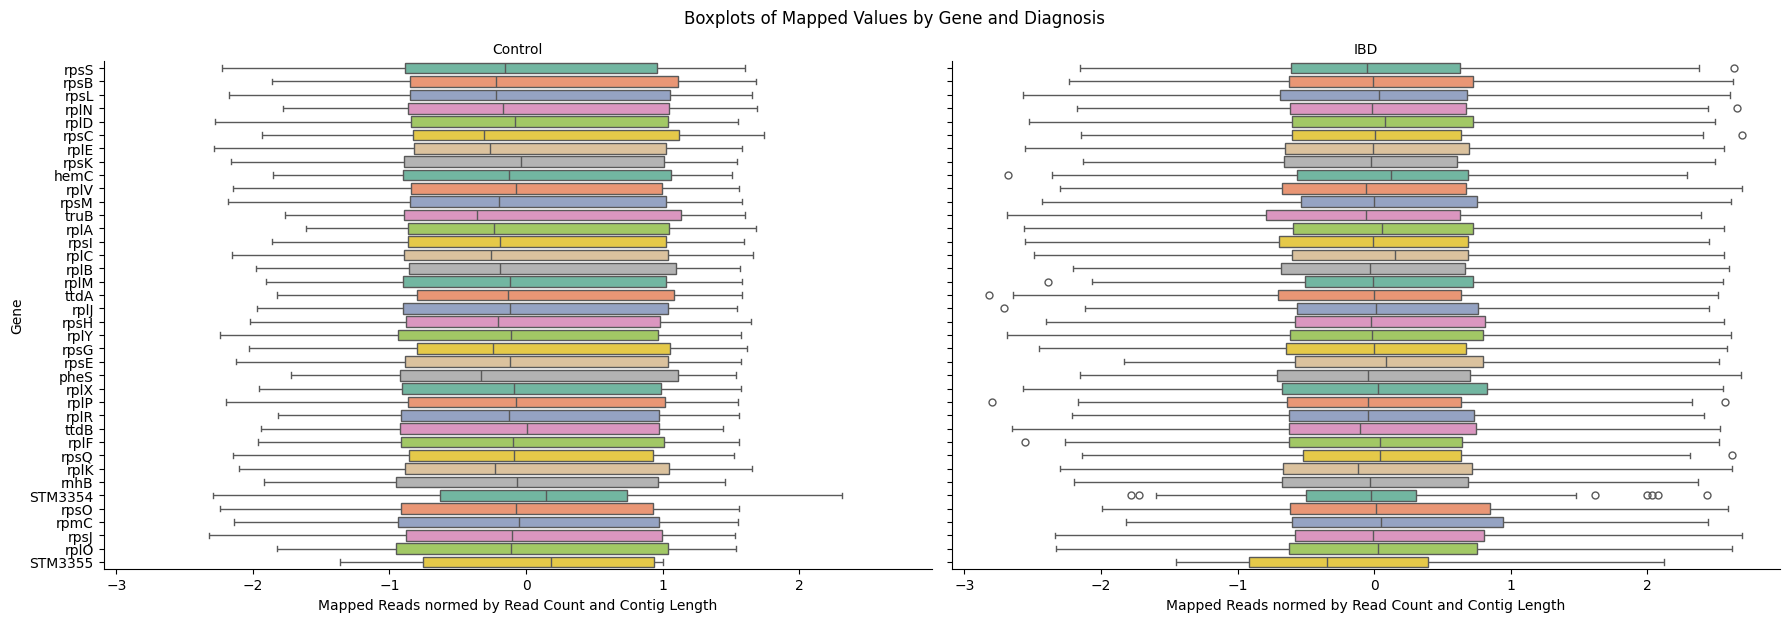

In [38]:
p = sns.catplot(
    data=filtered_subset_df,
    x="log_map_norm_standardized",
    y="gene_name",
    hue="gene_name", 
    kind="box",
    col="diagnosis",
    palette="Set2",
    height=6,
    aspect=1.5
)
p.set_titles(col_template="{col_name}")
p.set_xlabels("Mapped Reads normed by Read Count and Contig Length")
p.set_ylabels("Gene")

plt.suptitle("Boxplots of Mapped Values by Gene and Diagnosis", y=1.03)
plt.show()

In [39]:
single_copy_genes = ['rpsA', 'rpsB', 'rpsS', 'rplE', 'rplA', 'rplR', 'rplM']
                     #'infB', 'pheT', 'pheS']  # single copy genes
genes_of_interest = ['ttdA', 'ttdB', 'STM3354', 'STM3355']  # genes of interest

# Filter data for each gene set
single_copy_df = smash_df[smash_df['gene_name'].isin(single_copy_genes)].copy()
interest_df = smash_df[smash_df['gene_name'].isin(genes_of_interest)].copy()

# Method 1: Sum standardized values (for relative abundance comparison)
# This preserves the standardization you already did per contig
single_copy_std = (
    single_copy_df
    .groupby(['run', 'diagnosis'])['log_map_norm_standardized']
    .sum()
    .reset_index()
    .rename(columns={'log_map_norm_standardized': 'sc_log_std_sum'})
)

interest_std = (
    interest_df
    .groupby(['run', 'diagnosis'])['log_map_norm_standardized']
    .sum()
    .reset_index()
    .rename(columns={'log_map_norm_standardized': 'goi_log_std_sum'})
)

comparison_std = single_copy_std.merge(interest_std, on=['run', 'diagnosis'], how='outer')
comparison_std['ratio_std'] = comparison_std['goi_log_std_sum'] / comparison_std['sc_log_std_sum']
comparison_std['diff_std'] = comparison_std['goi_log_std_sum'] - comparison_std['sc_log_std_sum']

print("Comparison using standardized log-normalized values:")
print(comparison_std)

single_copy_mapped = (
    single_copy_df
    .groupby(['run', 'diagnosis'])
    .agg({
        'mapped': 'sum',
        'net_mapped': 'sum'
    })
    .reset_index()
    .rename(columns={'mapped': 'sc_mapped', 'net_mapped': 'sc_net_mapped'})
)

interest_mapped = (
    interest_df
    .groupby(['run', 'diagnosis'])
    .agg({
        'mapped': 'sum',
        'net_mapped': 'sum'
    })
    .reset_index()
    .rename(columns={'mapped': 'goi_mapped', 'net_mapped': 'goi_net_mapped'})
)

comparison_mapped = single_copy_mapped.merge(interest_mapped, on=['run', 'diagnosis'], how='outer')
comparison_mapped['ratio_mapped'] = comparison_mapped['goi_mapped'] / comparison_mapped['sc_mapped']

print("\n" + "="*80)
print("Comparison using raw mapped read counts:")
print("="*80)
print(comparison_mapped)

def calculate_gene_abundance(df, group_cols=['run', 'diagnosis']):
    """
    Calculate total normalized abundance for a gene group
    """
    result = (
        df
        .groupby(group_cols)
        .apply(lambda x: pd.Series({
            'total_mapped': x['mapped'].sum(),
            'total_net_mapped': x['net_mapped'].sum(),
            'avg_read_count': x['read_count'].iloc[0],  # Same for all rows in a run
            'num_contigs': len(x),
            # Sum the already normalized values is appropriate since each contig 
            # was normalized independently
            'sum_mapped_norm': x['mapped_norm_by_read_count_and_contig_length'].sum(),
            'sum_log_norm': x['log_map_norm'].sum(),
            'sum_standardized': x['standardized_norm'].sum()
        }))
        .reset_index()
    )
    return result

sc_abundance = calculate_gene_abundance(single_copy_df)
sc_abundance = sc_abundance.add_prefix('sc_', axis=1).rename(columns={'sc_run': 'run', 'sc_diagnosis': 'diagnosis'})

goi_abundance = calculate_gene_abundance(interest_df)
goi_abundance = goi_abundance.add_prefix('goi_', axis=1).rename(columns={'goi_run': 'run', 'goi_diagnosis': 'diagnosis'})

comparison_full = sc_abundance.merge(goi_abundance, on=['run', 'diagnosis'], how='outer')

print("\n" + "="*80)
print("Detailed abundance comparison:")
print("="*80)
print(comparison_full[['run', 'diagnosis', 'sc_total_mapped', 'goi_total_mapped', 
                        'sc_sum_standardized', 'goi_sum_standardized', 'sc_num_contigs', 'goi_num_contigs']])

# Summary by diagnosis
print("\n" + "="*80)
print("Summary by Diagnosis:")
print("="*80)
summary = comparison_std.groupby('diagnosis').agg({
    'sc_log_std_sum': 'mean',
    'goi_log_std_sum': 'mean',
    'ratio_std': 'mean',
    'diff_std': 'mean'
})
print(summary)

Comparison using standardized log-normalized values:
            run diagnosis  sc_log_std_sum  goi_log_std_sum  ratio_std  \
0     ERR011087   Control       -3.223253              NaN        NaN   
1     ERR011088   Control       -2.341958              NaN        NaN   
2     ERR011089   Control       -1.517698        -0.891289   0.587264   
3     ERR011090   Control       -3.831238        -1.962877   0.512335   
4     ERR011091   Control       -1.737282        -1.340923   0.771851   
..          ...       ...             ...              ...        ...   
852  SRR6468714       IBD       -3.695588        -0.933521   0.252604   
853  SRR6468715       IBD       -0.965398        -0.361939   0.374912   
854  SRR6468716       IBD       -1.146298              NaN        NaN   
855  SRR6468717       IBD       -0.923148              NaN        NaN   
856  SRR6468718       IBD       -4.743319              NaN        NaN   

     diff_std  
0         NaN  
1         NaN  
2    0.626409  
3    1

/tmp/ipykernel_657426/774907148.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_657426/774907148.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


In [40]:
def visualize_transformation_across_runs(df, gene_name='hemC', max_runs=10):
    """
    Visualize how data transforms across multiple runs for a specific gene.
    Shows aggregated values (sum per run) at each transformation stage.
    
    Parameters:
    -----------
    df : DataFrame
        Your smash_df dataframe
    gene_name : str
        Gene to visualize (e.g., 'hemC')
    max_runs : int
        Maximum number of runs to display (for readability)
    """
    
    # Filter data for the gene
    gene_df = df[df['gene_name'] == gene_name].copy()
    
    # Aggregate by run
    run_agg = gene_df.groupby('run').agg({
        'gene_mapped_sum': 'sum',
        'mapped_norm_by_read_count': 'sum',
        'mapped_norm_by_contig_length': 'sum',
        'mapped_norm_by_read_count_and_contig_length': 'sum',
        'log_map_norm': 'sum',
        'standardized_norm': 'sum' if 'standardized_norm' in gene_df.columns else 'count',
        'diagnosis': 'first'
    }).reset_index()
    
    # Limit runs for readability
    if len(run_agg) > max_runs:
        run_agg = run_agg.sample(max_runs, random_state=42)
    
    run_agg = run_agg.sort_values('run')
    
    # Create figure
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle(f'Data Transformation Pipeline Across Runs: {gene_name}', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Colors for diagnosis
    diagnosis_colors = {'IBD': '#e74c3c', 'Control': '#3498db', 'CD': '#e67e22', 
                       'UC': '#9b59b6', 'NonIBD': '#2ecc71'}
    colors = [diagnosis_colors.get(d, '#95a5a6') for d in run_agg['diagnosis']]
    
    x_pos = np.arange(len(run_agg))
    run_labels = [r[:8] + '...' if len(r) > 8 else r for r in run_agg['run']]
    
    stages = [
        ('gene_mapped_sum', 'Step 1: Raw Mapped Reads\n(sum across all contigs per run)', 'Count'),
        ('mapped_norm_by_read_count', 'Step 2: Normalized by Read Count', 'Normalized'),
        ('mapped_norm_by_contig_length', 'Step 3: Normalized by Length', 'Normalized'),
        ('mapped_norm_by_read_count_and_contig_length', 'Step 4: Fully Normalized', 'RPKM-like'),
        ('log_map_norm', 'Step 5: Log2 Transformed\n(sum of log values)', 'Log2'),
        ('standardized_norm', 'Step 6: Standardized (Z-score)\n(sum per run)', 'Z-score')
    ]
    
    for idx, (col, title, ylabel) in enumerate(stages):
        ax = axes[idx // 2, idx % 2]
        
        if col in run_agg.columns:
            bars = ax.bar(x_pos, run_agg[col], color=colors, alpha=0.8, edgecolor='black')
            ax.set_xlabel('Run', fontweight='bold')
            ax.set_ylabel(ylabel, fontweight='bold')
            ax.set_title(title, fontweight='bold', fontsize=11)
            ax.set_xticks(x_pos)
            ax.set_xticklabels(run_labels, rotation=45, ha='right', fontsize=8)
            ax.grid(axis='y', alpha=0.3)
            
            if col == 'standardized_norm':
                ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Mean=0')
                ax.legend()
            
            # Format y-axis for large numbers
            if run_agg[col].max() > 1000:
                ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        else:
            ax.text(0.5, 0.5, f'{col} not found', transform=ax.transAxes, 
                   ha='center', va='center')
            ax.axis('off')
    
    # Add legend for diagnosis colors
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=diagnosis_colors.get(d, '#95a5a6'), 
                             label=d, alpha=0.8) 
                      for d in run_agg['diagnosis'].unique()]
    fig.legend(handles=legend_elements, loc='upper right', title='Diagnosis', 
              bbox_to_anchor=(0.99, 0.99))
    
    plt.tight_layout()
    return fig


def compare_gene_groups_across_runs(df, gene_groups, max_runs=10):
    """
    Compare summed values for gene groups (e.g., single-copy vs genes of interest) across runs.
    
    Parameters:
    -----------
    df : DataFrame
        Your smash_df dataframe
    gene_groups : dict
        Dictionary like {'Single Copy': ['rpsA', 'rpsB'], 'Genes of Interest': ['hemC']}
    max_runs : int
        Maximum number of runs to display
    """
    
    # Sample runs
    all_runs = df['run'].unique()
    if len(all_runs) > max_runs:
        selected_runs = np.random.choice(all_runs, max_runs, replace=False)
    else:
        selected_runs = all_runs
    
    df_subset = df[df['run'].isin(selected_runs)].copy()
    
    # Create aggregations for each gene group
    results = []
    for group_name, genes in gene_groups.items():
        group_df = df_subset[df_subset['gene_name'].isin(genes)]
        agg = group_df.groupby(['run', 'diagnosis']).agg({
            'gene_mapped_sum': 'sum',
            'mapped_norm_by_read_count_and_contig_length': 'sum',
            'log_map_norm': 'sum',
            'standardized_norm': 'sum' if 'standardized_norm' in group_df.columns else 'count',
        }).reset_index()
        agg['gene_group'] = group_name
        results.append(agg)
    
    combined = pd.concat(results, ignore_index=True)
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Gene Group Comparison Across Runs', fontsize=16, fontweight='bold')
    
    stages = [
        ('gene_mapped_sum', 'Raw Mapped Reads (sum)', 'Count'),
        ('mapped_norm_by_read_count_and_contig_length', 'Fully Normalized (sum)', 'RPKM-like'),
        ('log_map_norm', 'Log2 Transformed (sum)', 'Log2 Sum'),
        ('standardized_norm', 'Standardized (sum)', 'Z-score Sum')
    ]
    
    for idx, (col, title, ylabel) in enumerate(stages):
        ax = axes[idx // 2, idx % 2]
        
        if col in combined.columns:
            # Pivot for grouped bar chart
            pivot_data = combined.pivot_table(
                index='run', 
                columns='gene_group', 
                values=col, 
                aggfunc='sum'
            )
            
            pivot_data.plot(kind='bar', ax=ax, alpha=0.8, edgecolor='black', width=0.8)
            ax.set_xlabel('Run', fontweight='bold')
            ax.set_ylabel(ylabel, fontweight='bold')
            ax.set_title(title, fontweight='bold', fontsize=12)
            ax.legend(title='Gene Group', loc='best')
            ax.grid(axis='y', alpha=0.3)
            ax.set_xticklabels([r[:8] + '...' if len(r) > 8 else r 
                               for r in pivot_data.index], 
                              rotation=45, ha='right', fontsize=9)
            
            if col == 'standardized_norm':
                ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
            
            if pivot_data.max().max() > 1000:
                ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    plt.tight_layout()
    return fig


def visualize_distribution_across_runs(df, gene_name='hemC'):
    """
    Show distribution of values across ALL runs using boxplots and histograms.
    
    Parameters:
    -----------
    df : DataFrame
        Your smash_df dataframe
    gene_name : str
        Gene to visualize
    """
    
    # Filter data
    gene_df = df[df['gene_name'] == gene_name].copy()
    
    # Aggregate by run
    run_agg = gene_df.groupby(['run', 'diagnosis']).agg({
        'gene_mapped_sum': 'sum',
        'log_map_norm': 'sum',
        'standardized_norm': 'sum' if 'standardized_norm' in gene_df.columns else 'count',
    }).reset_index()
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Distribution Analysis Across All Runs: {gene_name}', 
                 fontsize=16, fontweight='bold')
    
    stages = [
        ('gene_mapped_sum', 'Raw Mapped Reads'),
        ('log_map_norm', 'Log2 Normalized'),
        ('standardized_norm', 'Standardized')
    ]
    
    # Calculate run counts per diagnosis
    diagnosis_counts = run_agg.groupby('diagnosis')['run'].nunique()
    
    for idx, (col, title) in enumerate(stages):
        if col not in run_agg.columns:
            continue
            
        # Boxplot by diagnosis
        ax = axes[0, idx]
        run_agg.boxplot(column=col, by='diagnosis', ax=ax, patch_artist=True)
        ax.set_title(f'{title}\nby Diagnosis', fontweight='bold')
        ax.set_xlabel('Diagnosis', fontweight='bold')
        ax.set_ylabel('Sum per Run', fontweight='bold')
        plt.sca(ax)
        
        # Update x-tick labels with counts
        diagnoses = run_agg['diagnosis'].unique()
        labels = [f'{d}\n(n={diagnosis_counts[d]})' for d in diagnoses]
        ax.set_xticklabels(labels, rotation=0)
        ax.get_figure().suptitle('')  # Remove automatic title
        
        if col == 'standardized_norm':
            ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
        
        # Histogram
        ax = axes[1, idx]
        for diagnosis in run_agg['diagnosis'].unique():
            data = run_agg[run_agg['diagnosis'] == diagnosis][col]
            count = diagnosis_counts[diagnosis]
            ax.hist(data, alpha=0.6, label=f'{diagnosis} (n={count})', bins=15, edgecolor='black')
        
        ax.set_xlabel('Sum per Run', fontweight='bold')
        ax.set_ylabel('Frequency', fontweight='bold')
        ax.set_title(f'{title}\nDistribution', fontweight='bold')
        ax.legend(title='Diagnosis')
        ax.grid(axis='y', alpha=0.3)
        
        if col == 'standardized_norm':
            ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    
    plt.tight_layout()
    return fig

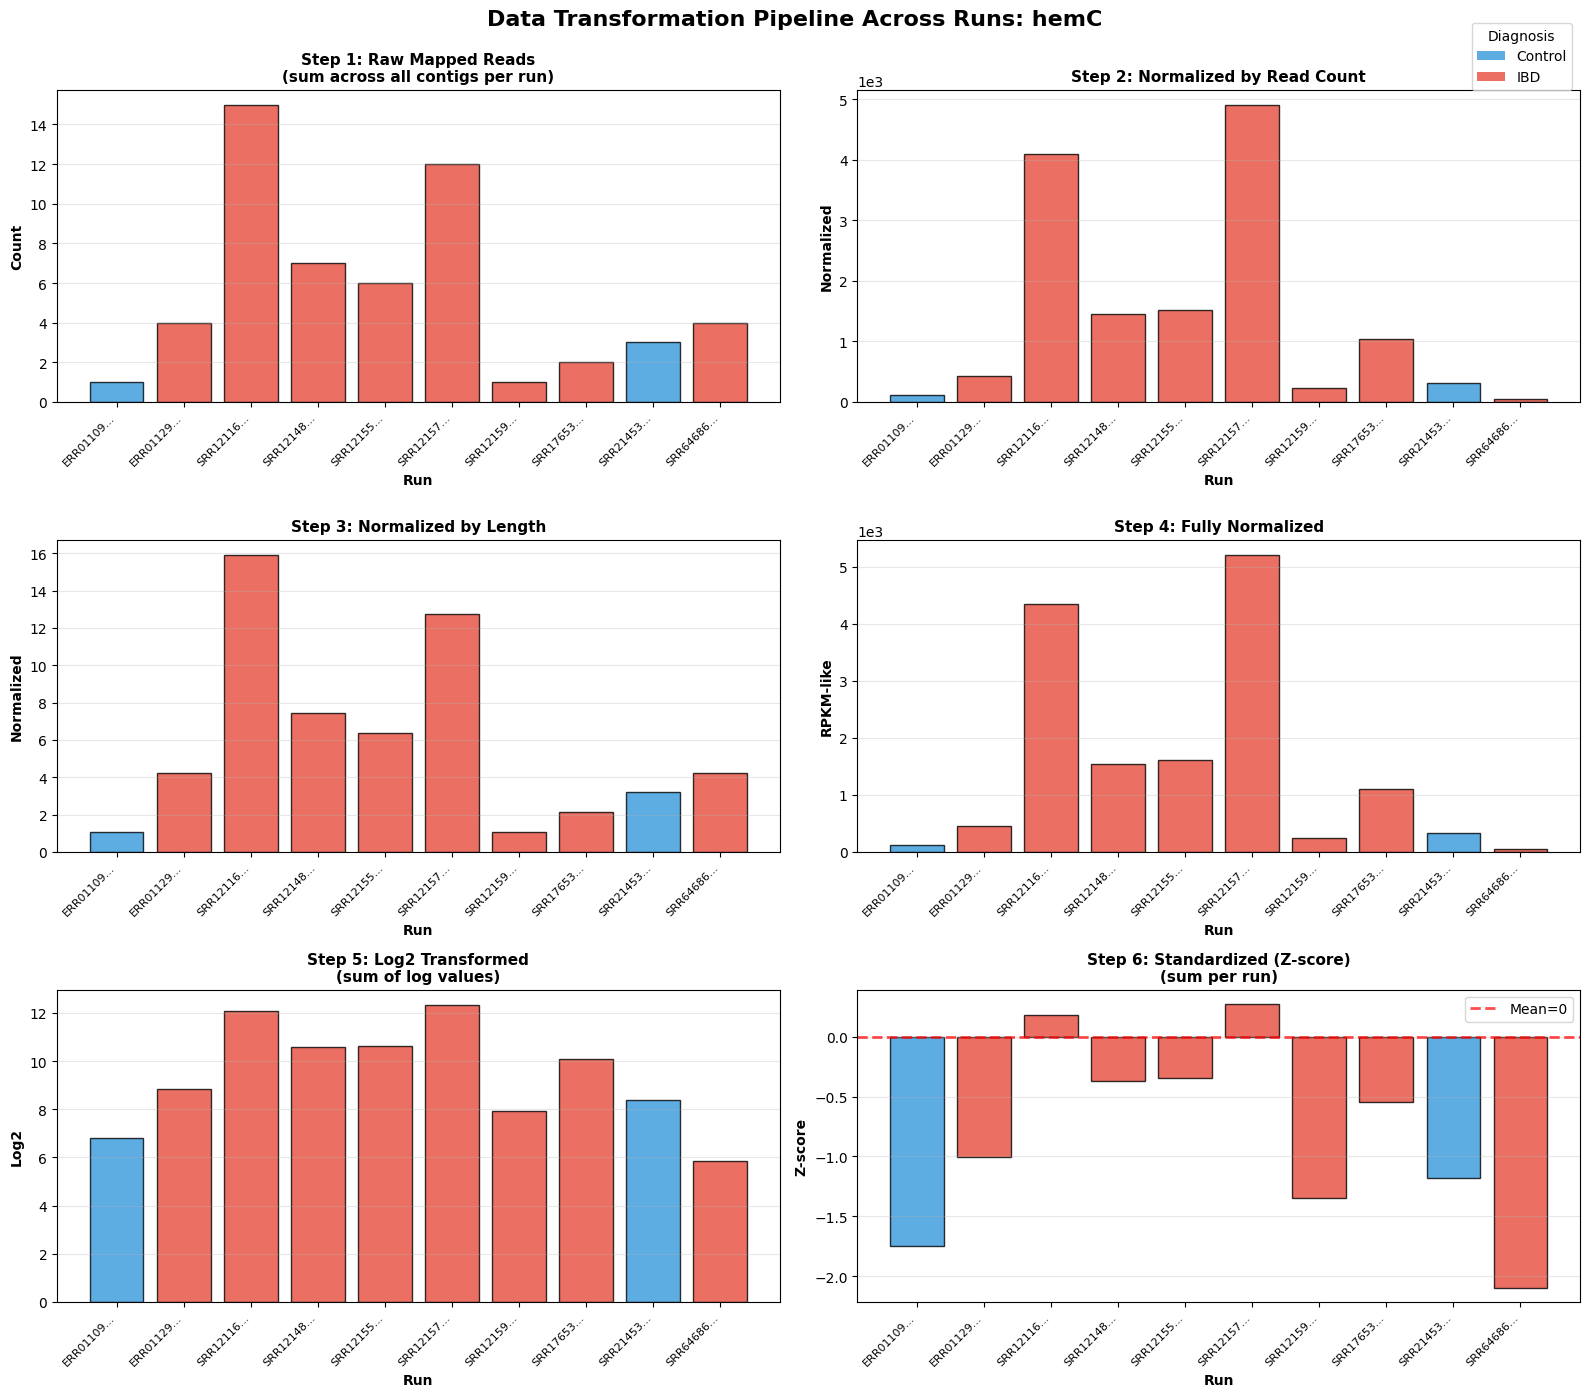

In [41]:
fig = visualize_transformation_across_runs(smash_df, gene_name='hemC')
plt.show()

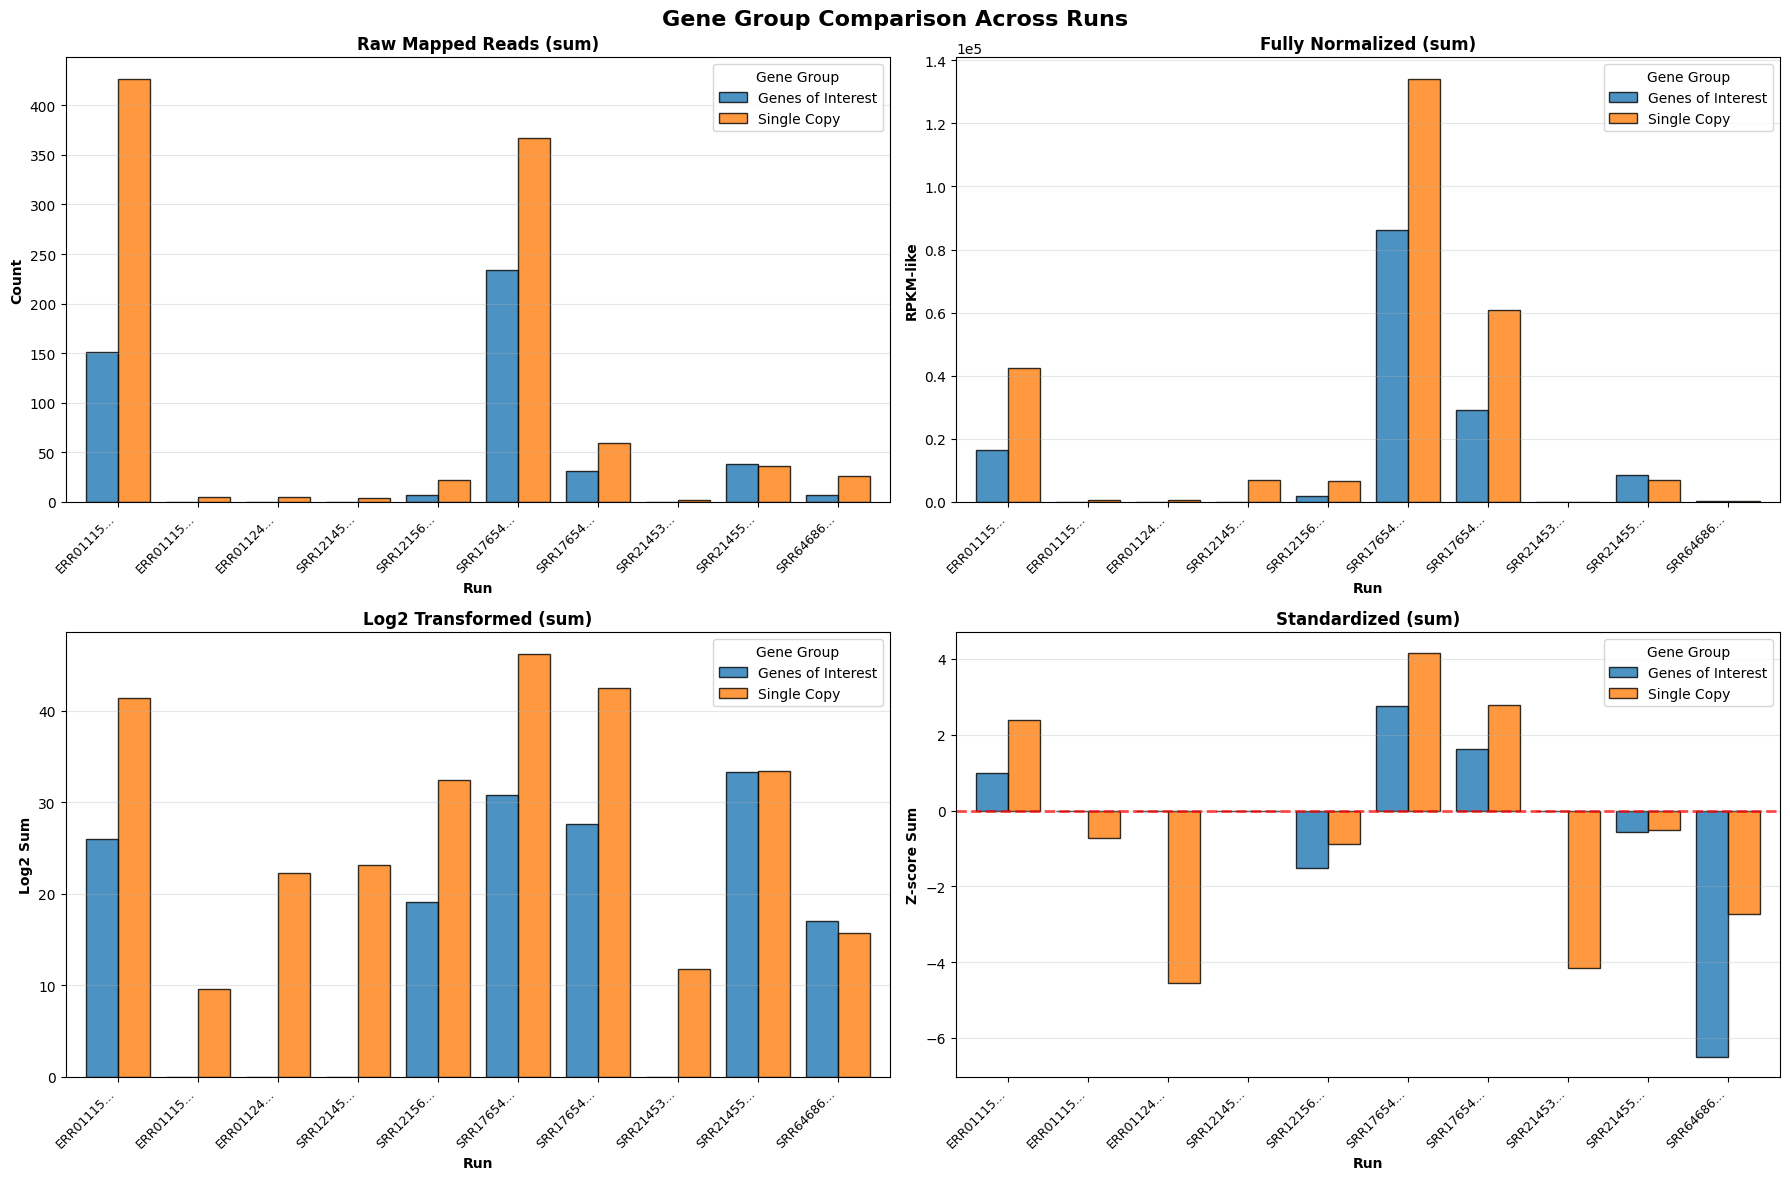

In [42]:
gene_groups = {
       'Single Copy': ['rpsA', 'rpsB', 'rpsS'],
       'Genes of Interest': ['STM3354', 'STM3355', 'ttdB', 'ttdA']
   }
fig = compare_gene_groups_across_runs(smash_df, gene_groups)
plt.show()

In [43]:
def visualize_distribution_across_runs(df, gene_name='hemC', colors=None):
    """
    Show distribution of values across ALL runs using boxplots and histograms.
    
    Parameters:
    -----------
    df : DataFrame
        Your smash_df dataframe
    gene_name : str
        Gene to visualize
    colors : dict, optional
        Dictionary mapping diagnosis to colors, e.g., {'IBD': '#e74c3c', 'Control': '#3498db'}
        If None, uses default colors
    """
    
    gene_df = df[df['gene_name'] == gene_name].copy()
    
    run_agg = gene_df.groupby(['run', 'diagnosis']).agg({
        'gene_mapped_sum': 'sum',
        'log_map_norm': 'sum',
        'log_map_norm_standardized': 'sum',
    }).reset_index()
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Distribution Analysis Across All Runs: {gene_name}', 
                 fontsize=16, fontweight='bold')
    
    stages = [
        ('gene_mapped_sum', 'Raw Mapped Reads'),
        ('log_map_norm', 'Log2 Normalized'),
        ('log_map_norm_standardized', 'Standardized')
    ]
    
    if colors is None:
        colors = {
            'IBD': '#9b59b6',      # Red
            'Control': '#3498db',  # Blue
            'CD': '#e67e22',       # Orange
            'UC': '#e74c3c',       # Purple
            'NonIBD': '#2ecc71'    # Green
        }
    
    diagnosis_counts = run_agg.groupby('diagnosis')['run'].nunique()
    
    for idx, (col, title) in enumerate(stages):
        if col not in run_agg.columns:
            continue
            
        ax = axes[0, idx]
        
        # Create boxplot with colors
        diagnoses = sorted(run_agg['diagnosis'].unique())
        box_data = [run_agg[run_agg['diagnosis'] == d][col].values for d in diagnoses]
        bp = ax.boxplot(box_data, patch_artist=True, tick_labels=diagnoses)
        
        # Color the boxplots
        for patch, diagnosis in zip(bp['boxes'], diagnoses):
            patch.set_facecolor(colors.get(diagnosis, '#95a5a6'))
            patch.set_alpha(0.7)
        
        ax.set_title(f'{title}\nby Diagnosis', fontweight='bold')
        ax.set_xlabel('Diagnosis', fontweight='bold')
        ax.set_ylabel('Sum per Run', fontweight='bold')
        
        # Update x-tick labels with counts
        labels = [f'{d}\n(n={diagnosis_counts[d]})' for d in diagnoses]
        ax.set_xticklabels(labels, rotation=0)
        ax.grid(axis='y', alpha=0.3)
        
        if col == 'log_map_norm_standardized':
            ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
        
        # Histogram
        ax = axes[1, idx]
        for diagnosis in sorted(run_agg['diagnosis'].unique()):
            data = run_agg[run_agg['diagnosis'] == diagnosis][col]
            count = diagnosis_counts[diagnosis]
            color = colors.get(diagnosis, '#95a5a6')
            ax.hist(data, alpha=0.6, label=f'{diagnosis} (n={count})', bins=15, 
                   edgecolor='black', color=color)
        
        ax.set_xlabel('Sum per Run', fontweight='bold')
        ax.set_ylabel('Frequency', fontweight='bold')
        ax.set_title(f'{title}\nDistribution', fontweight='bold')
        ax.legend(title='Diagnosis')
        ax.grid(axis='y', alpha=0.3)
        
        if col == 'standardized_norm':
            ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=1)
    
    plt.tight_layout()
    return fig

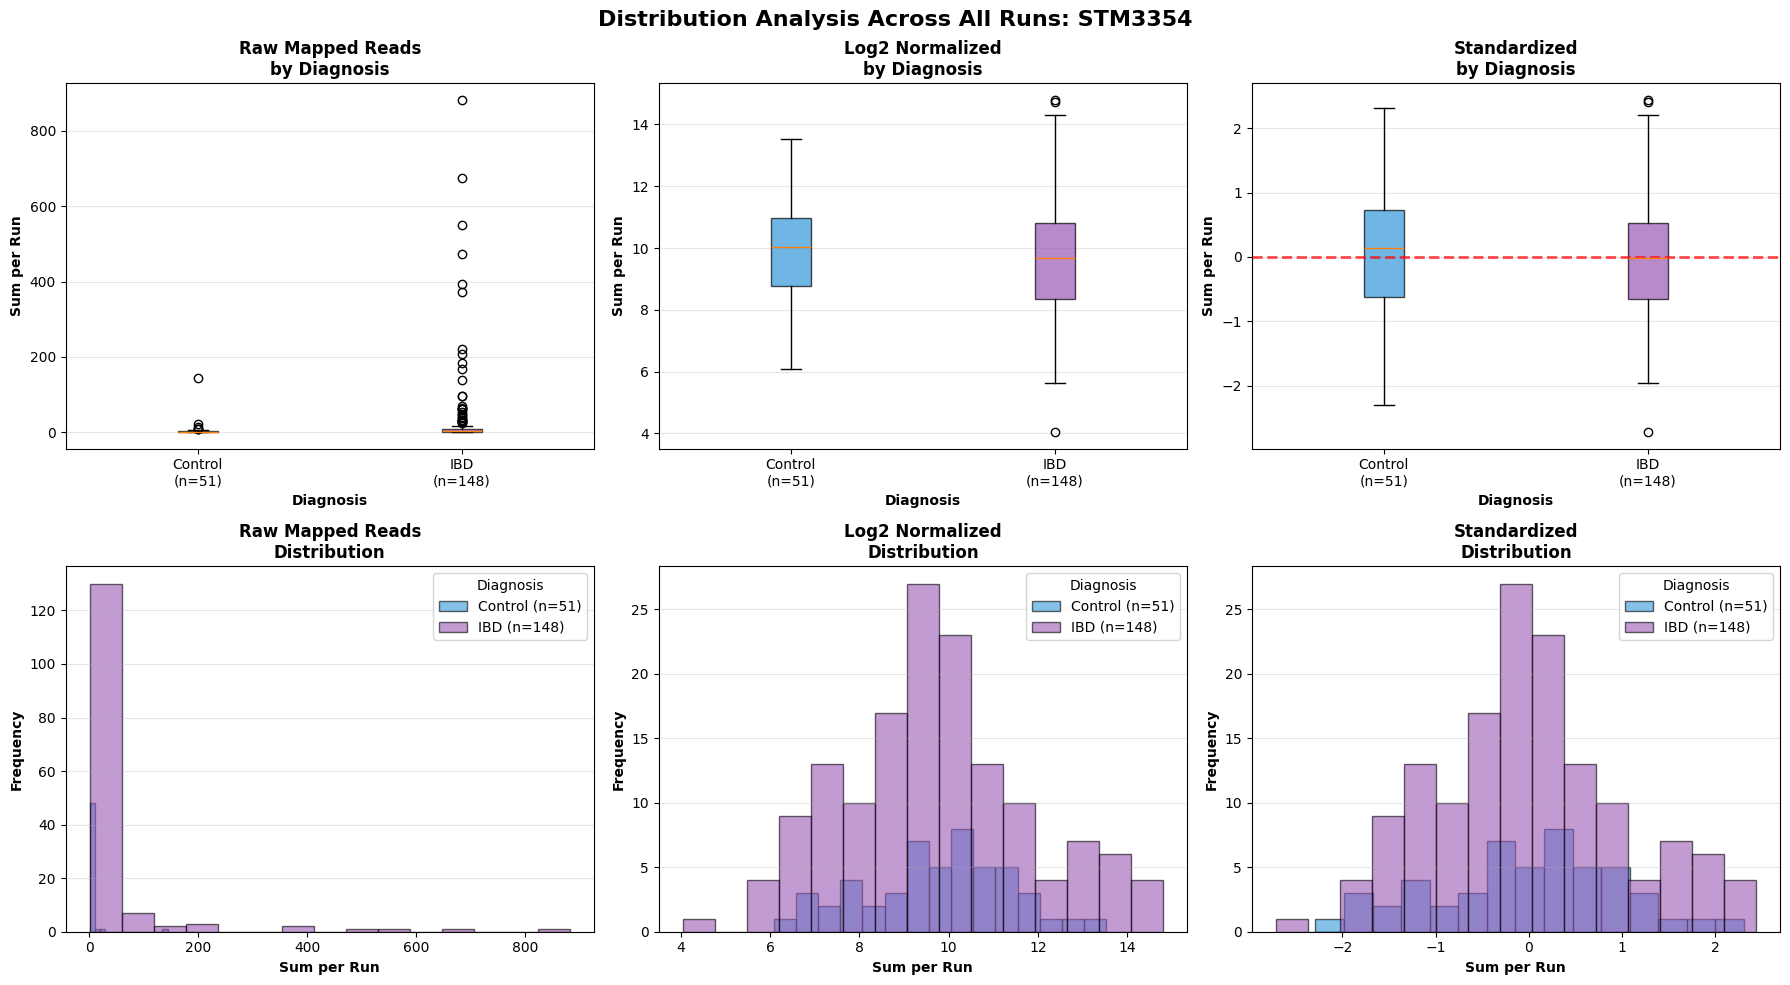

In [44]:
fig = visualize_distribution_across_runs(smash_df, gene_name='STM3354')
plt.savefig('STM3354-subset-distribution.png', dpi=300, bbox_inches='tight')
plt.show()


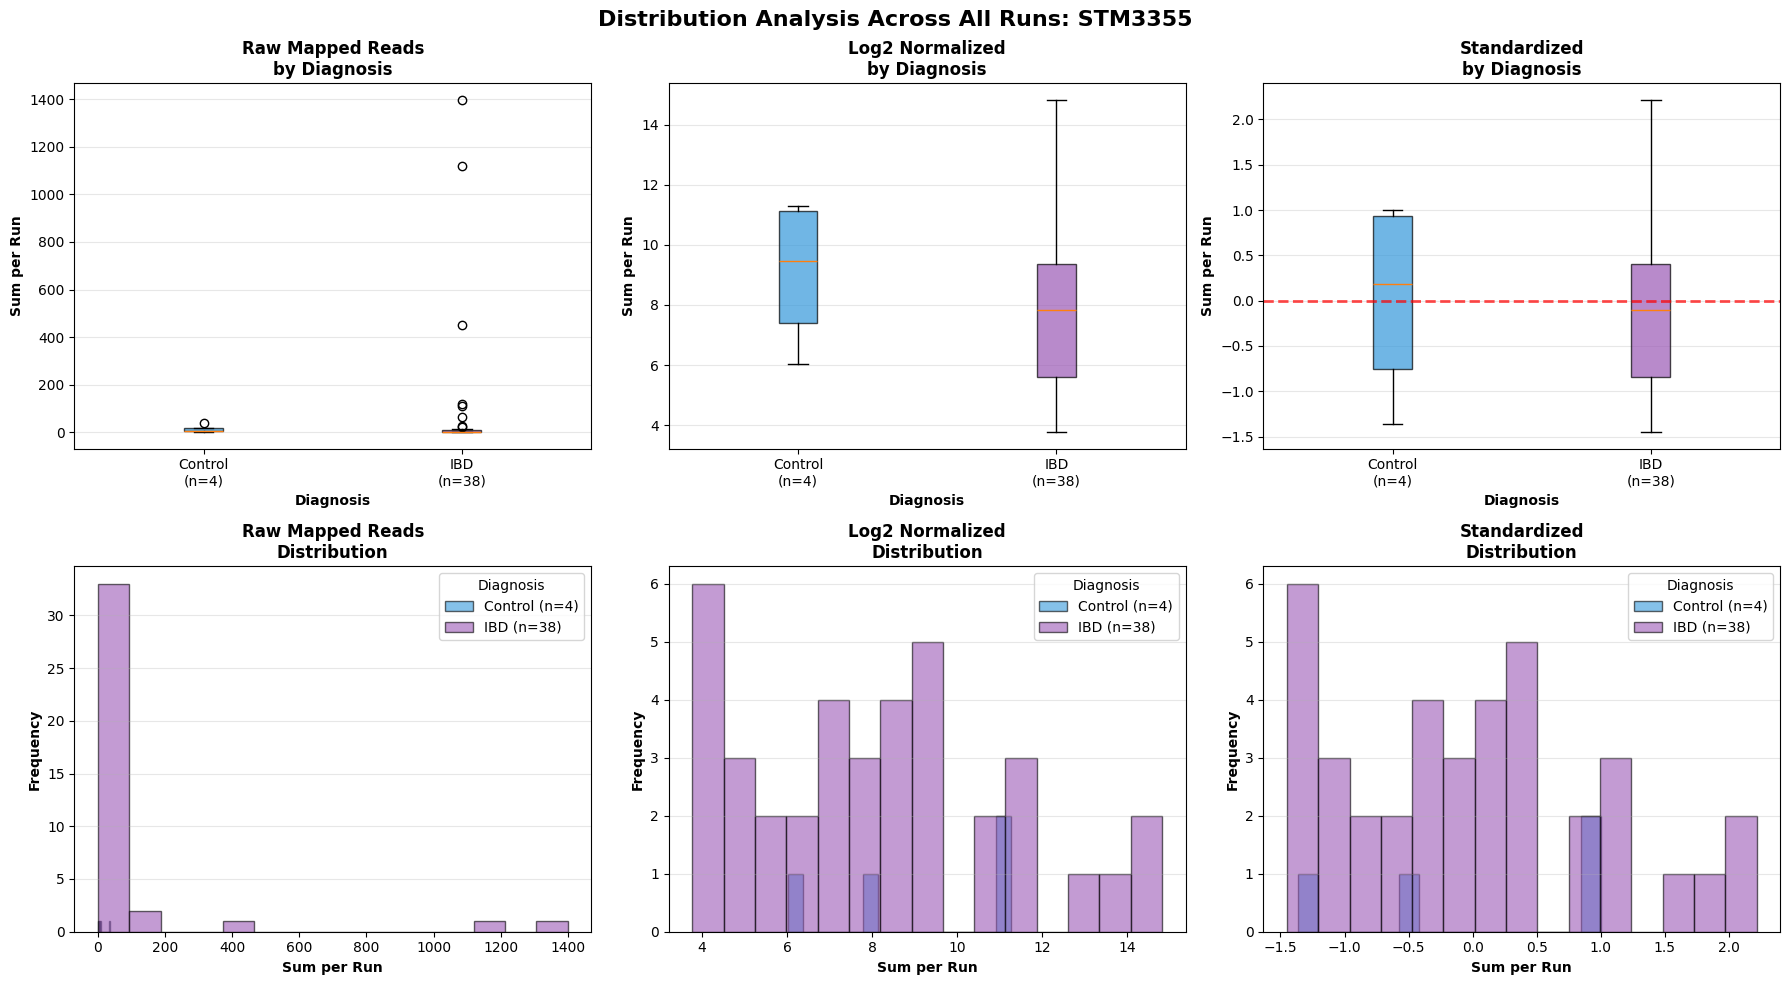

In [45]:
fig = visualize_distribution_across_runs(smash_df, gene_name='STM3355')
plt.savefig('STM3355-smash-distribution.png', dpi=300, bbox_inches='tight')
plt.show()


In [46]:
smash_df[(smash_df['gene_name']=='STM3355') & (smash_df['diagnosis']=='Control')]
smash_df[
    smash_df['gene_name'].isin(['STM3355', 'STM3354']) &
    (smash_df['diagnosis'] == 'Control')
]['run'].tolist()
",".join(
    smash_df[
        smash_df['gene_name'].isin(['STM3355', 'STM3354']) &
        (smash_df['diagnosis'] == 'Control')
    ]['run'].astype(str)
)

'ERR011193,SRR6468578,SRR1765527,SRR1765375,ERR011192,SRR6468547,SRR6468639,SRR6468639,SRR1212273,SRR6468597,SRR1215868,SRR6468544,SRR1765530,SRR6468673,SRR1765025,ERR011126,SRR1765587,SRR6468542,ERR011127,SRR1765389,SRR1215976,SRR1212216,SRR2145369,SRR1211680,SRR1765464,SRR6468523,SRR1211568,SRR1765341,SRR2145364,SRR1213913,ERR011128,SRR1765589,SRR1215919,SRR1765504,SRR6468680,SRR1765454,SRR1765384,SRR6468681,SRR1765558,SRR6468622,ERR011164,SRR6468549,SRR1765397,SRR1211665,SRR1211606,SRR2145375,SRR1765383,SRR1765517,SRR1765427,SRR1765216,SRR5650176,SRR5650176,SRR6468643,SRR6468528,SRR1765395'

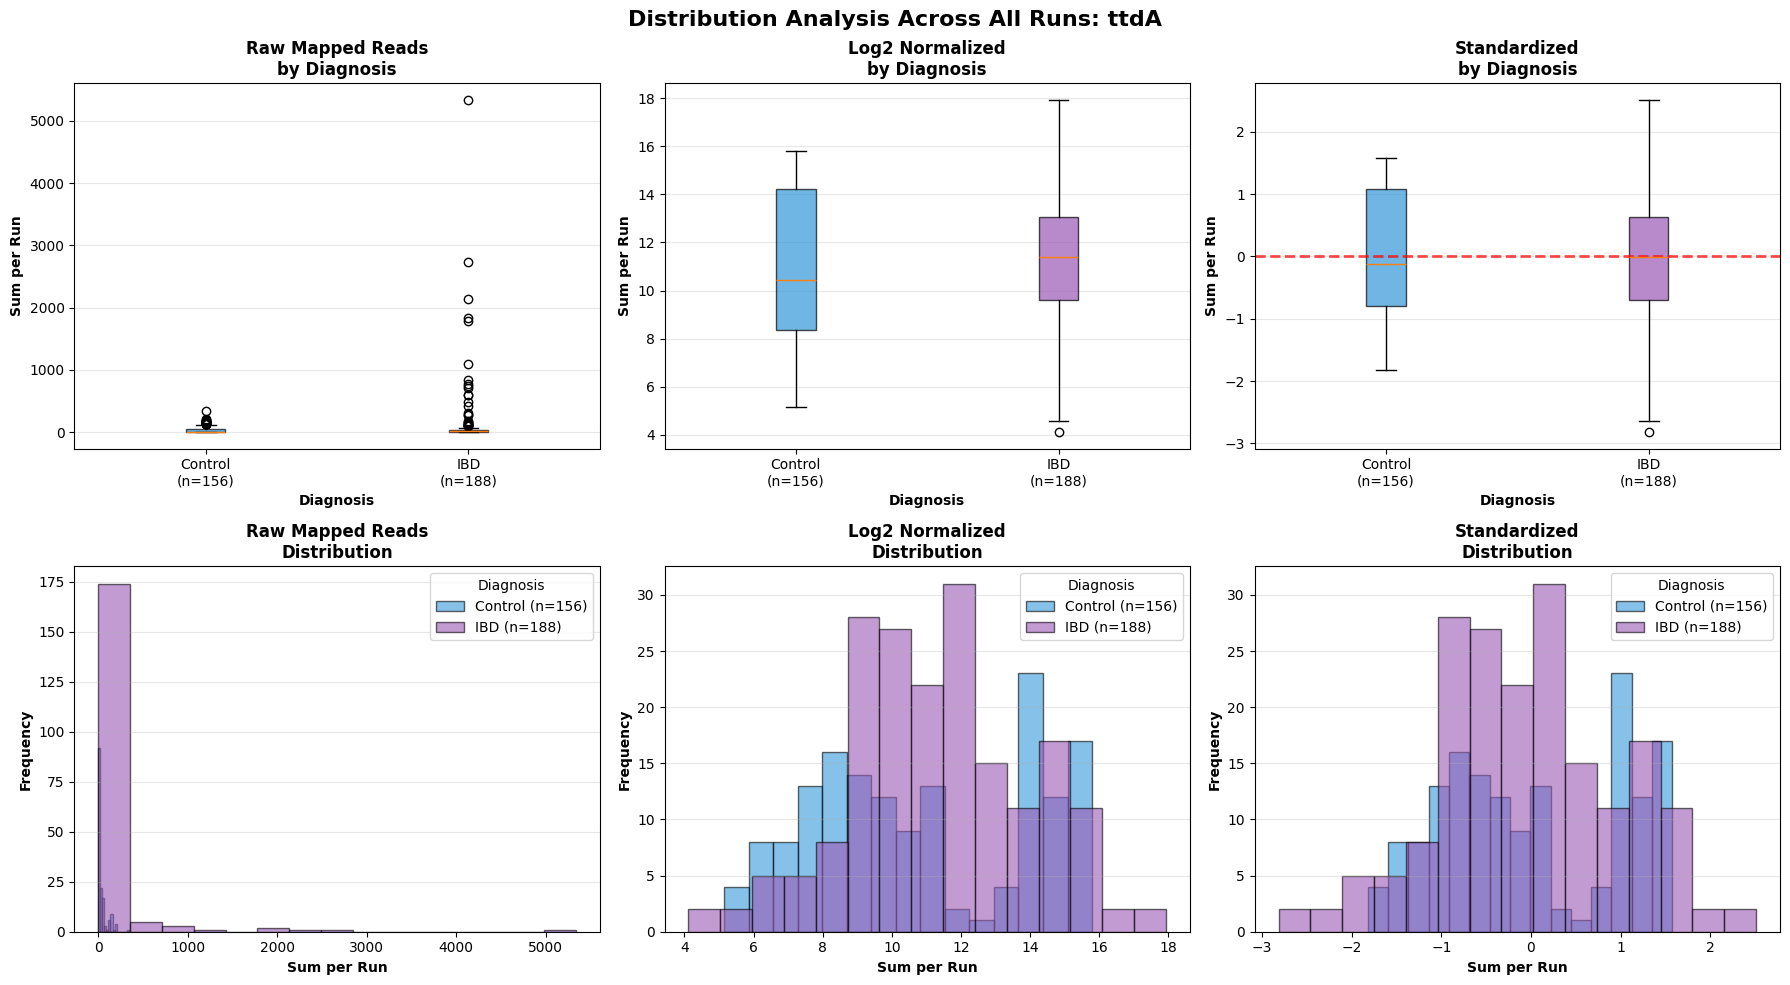

In [47]:
fig = visualize_distribution_across_runs(df_subset, gene_name='ttdA')
plt.show()

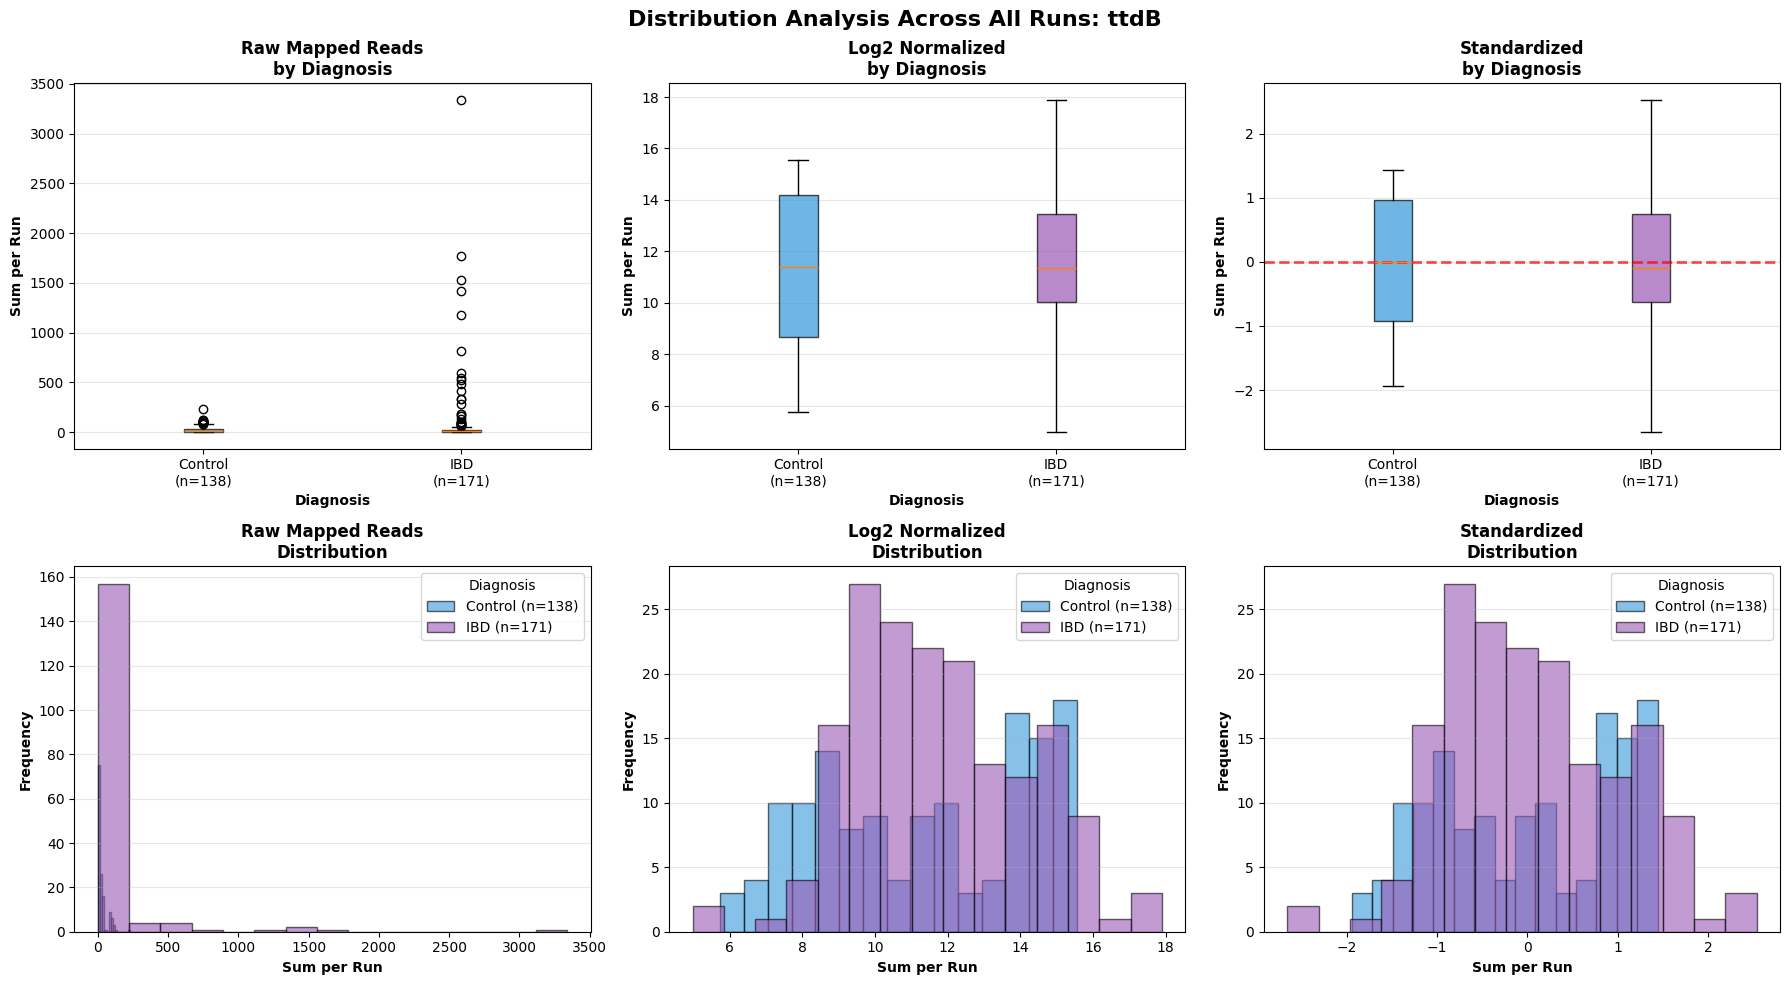

In [48]:
fig = visualize_distribution_across_runs(df_subset, gene_name='ttdB')
plt.show()

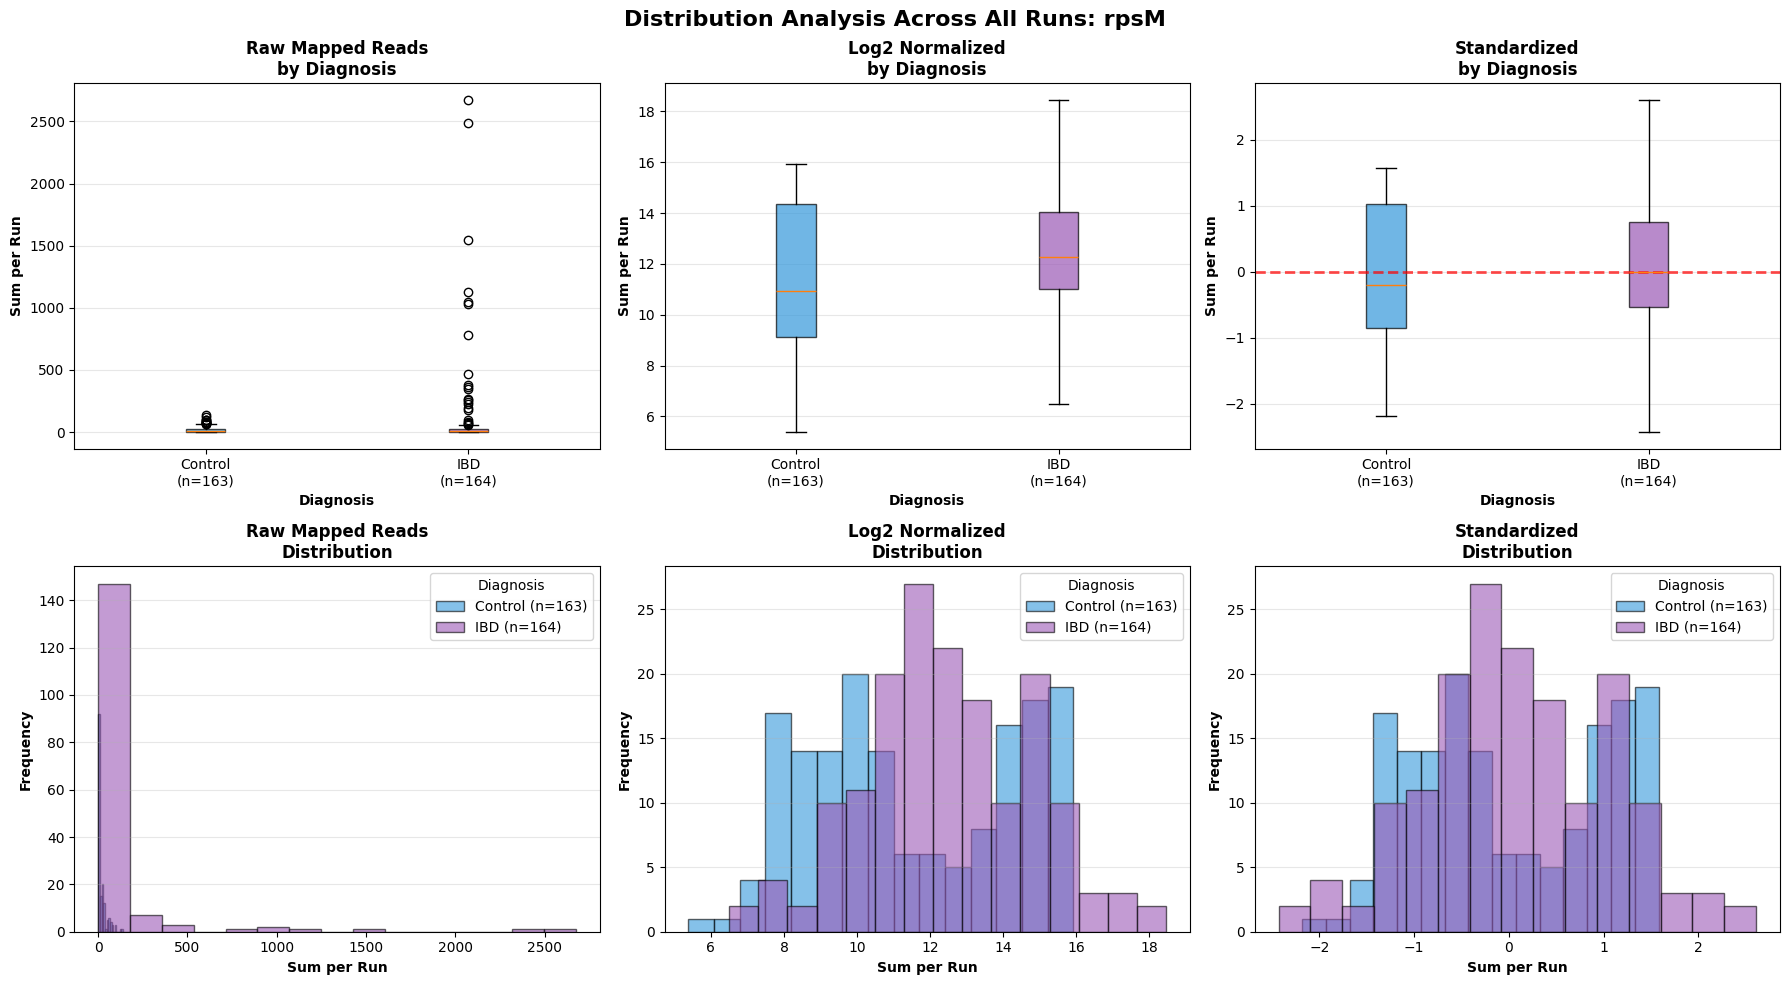

In [49]:
fig = visualize_distribution_across_runs(df_subset, gene_name='rpsM')
plt.show()

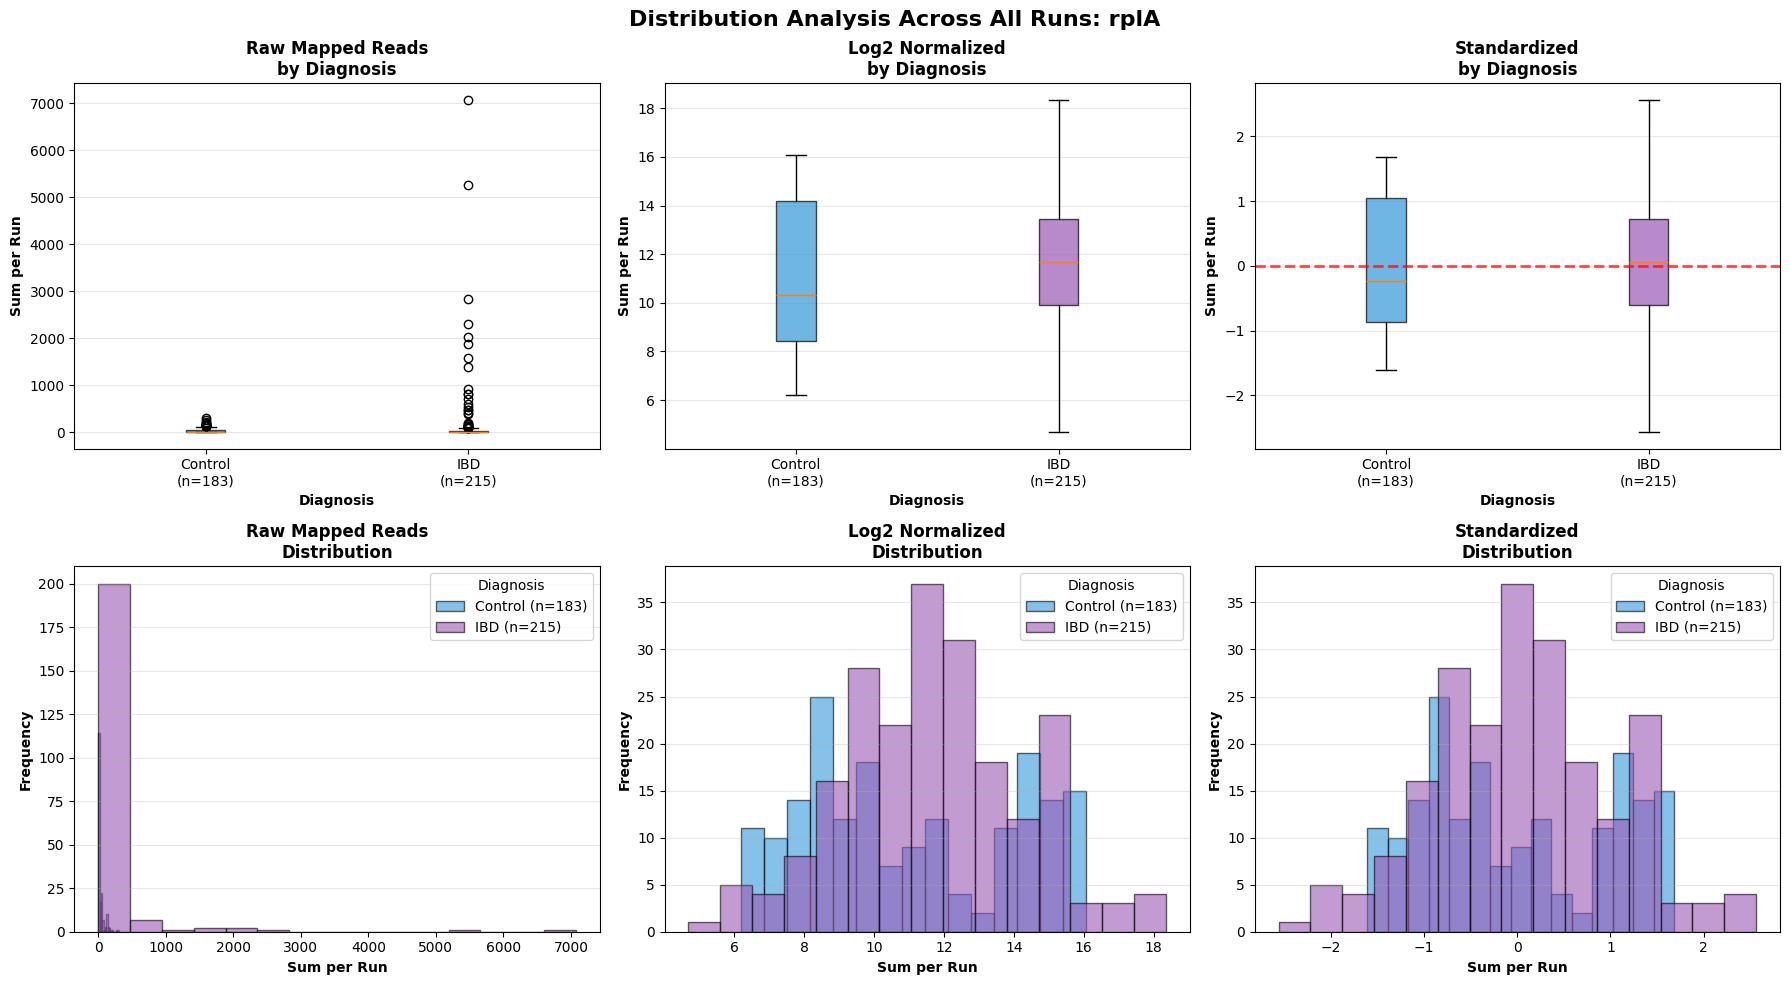

In [50]:
fig = visualize_distribution_across_runs(df_subset, gene_name='rplA')
plt.show()

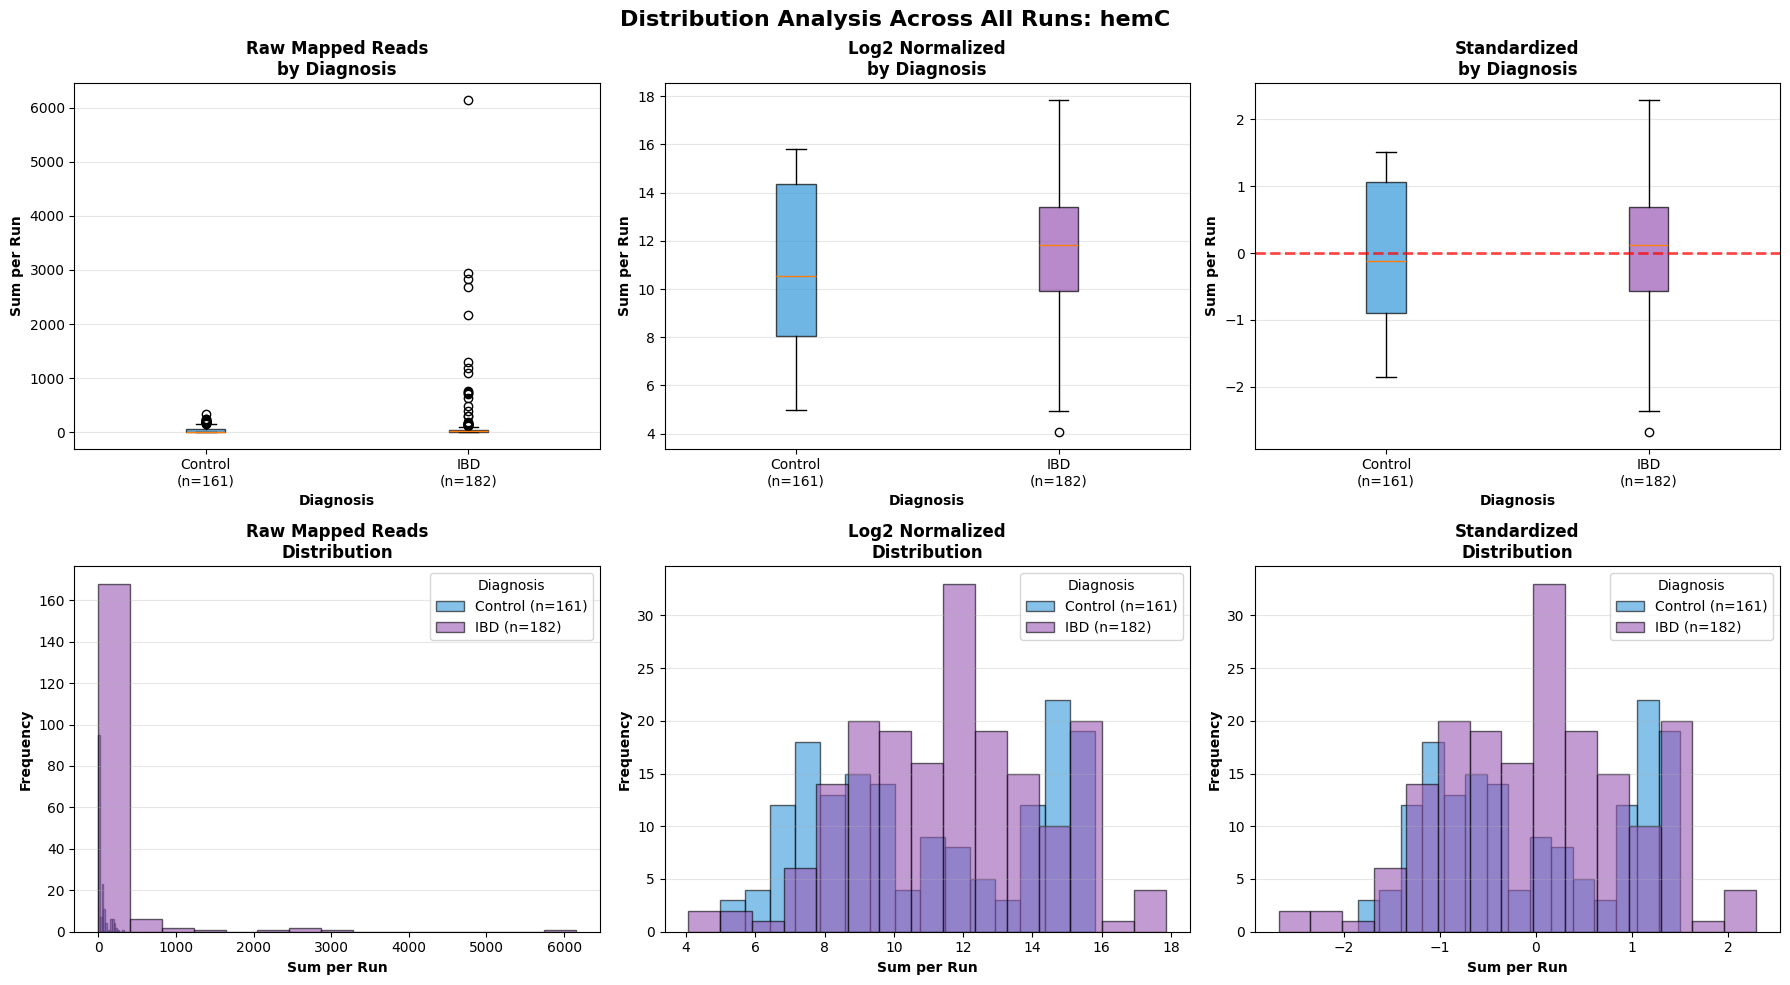

In [51]:
fig = visualize_distribution_across_runs(df_subset, gene_name='hemC')
plt.show()

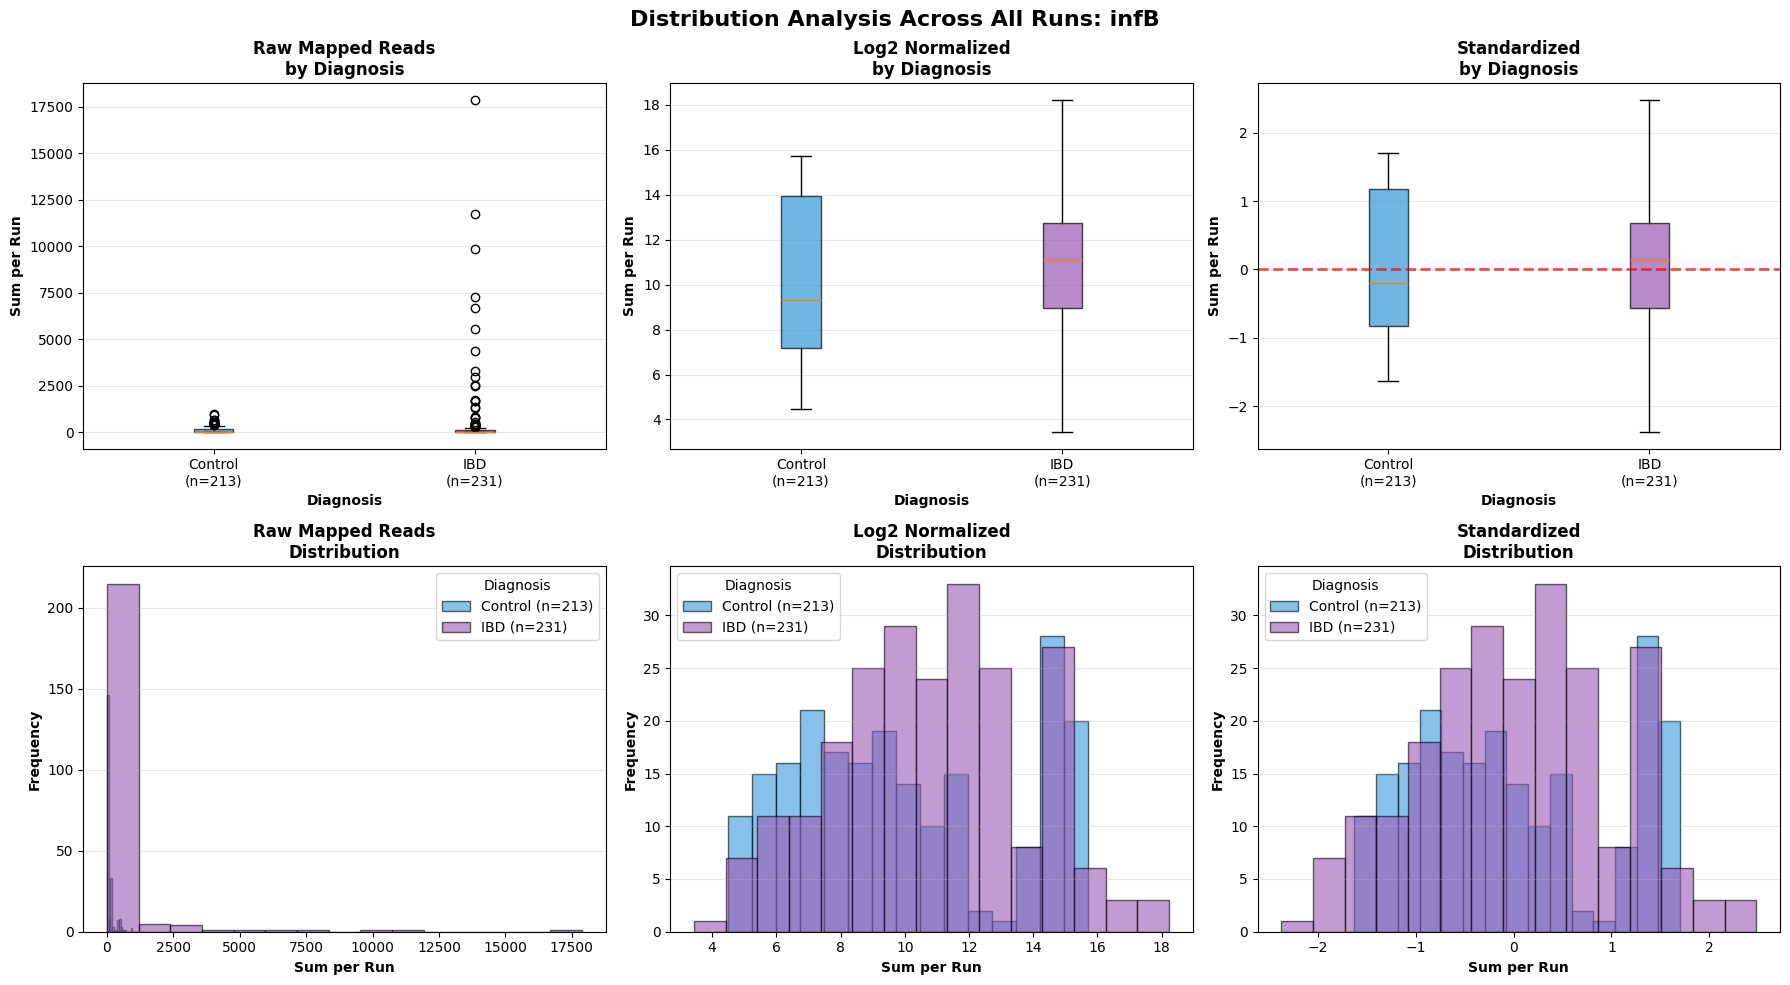

In [52]:
fig = visualize_distribution_across_runs(df_subset, gene_name='infB') #not subsetting skews data to IBD
plt.show()

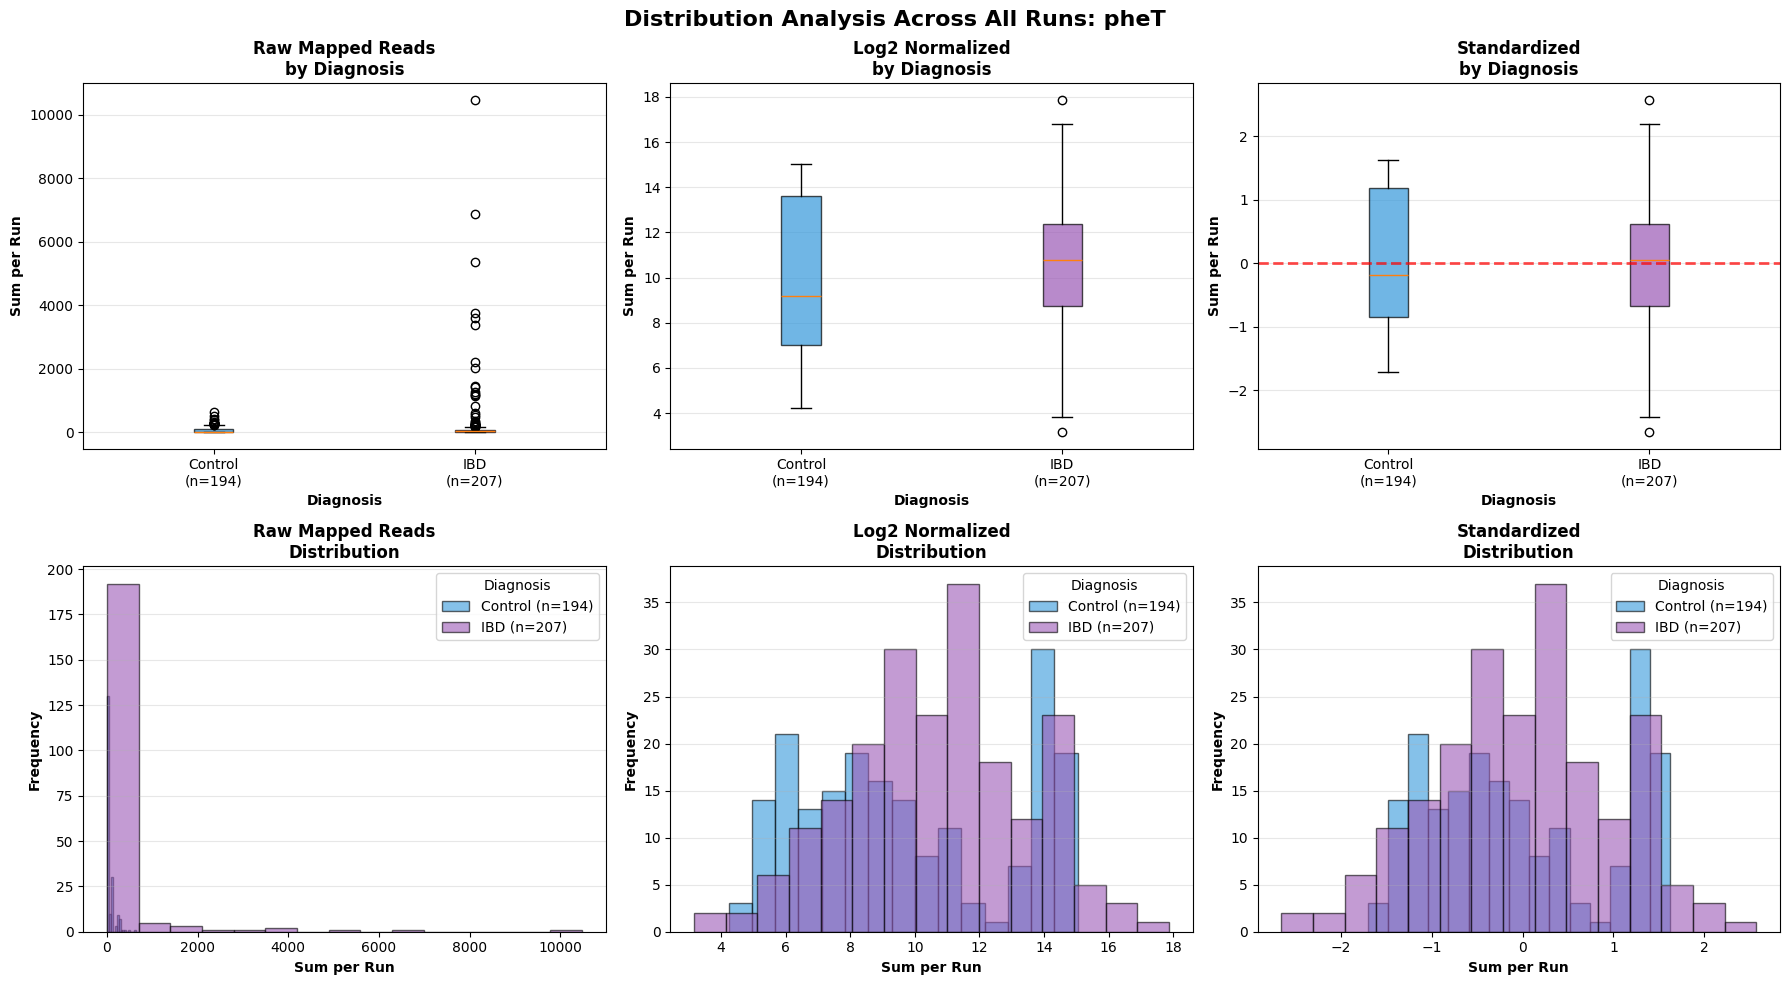

In [53]:
fig = visualize_distribution_across_runs(df_subset, gene_name='pheT') #not subsetting skews data to IBD
plt.show()

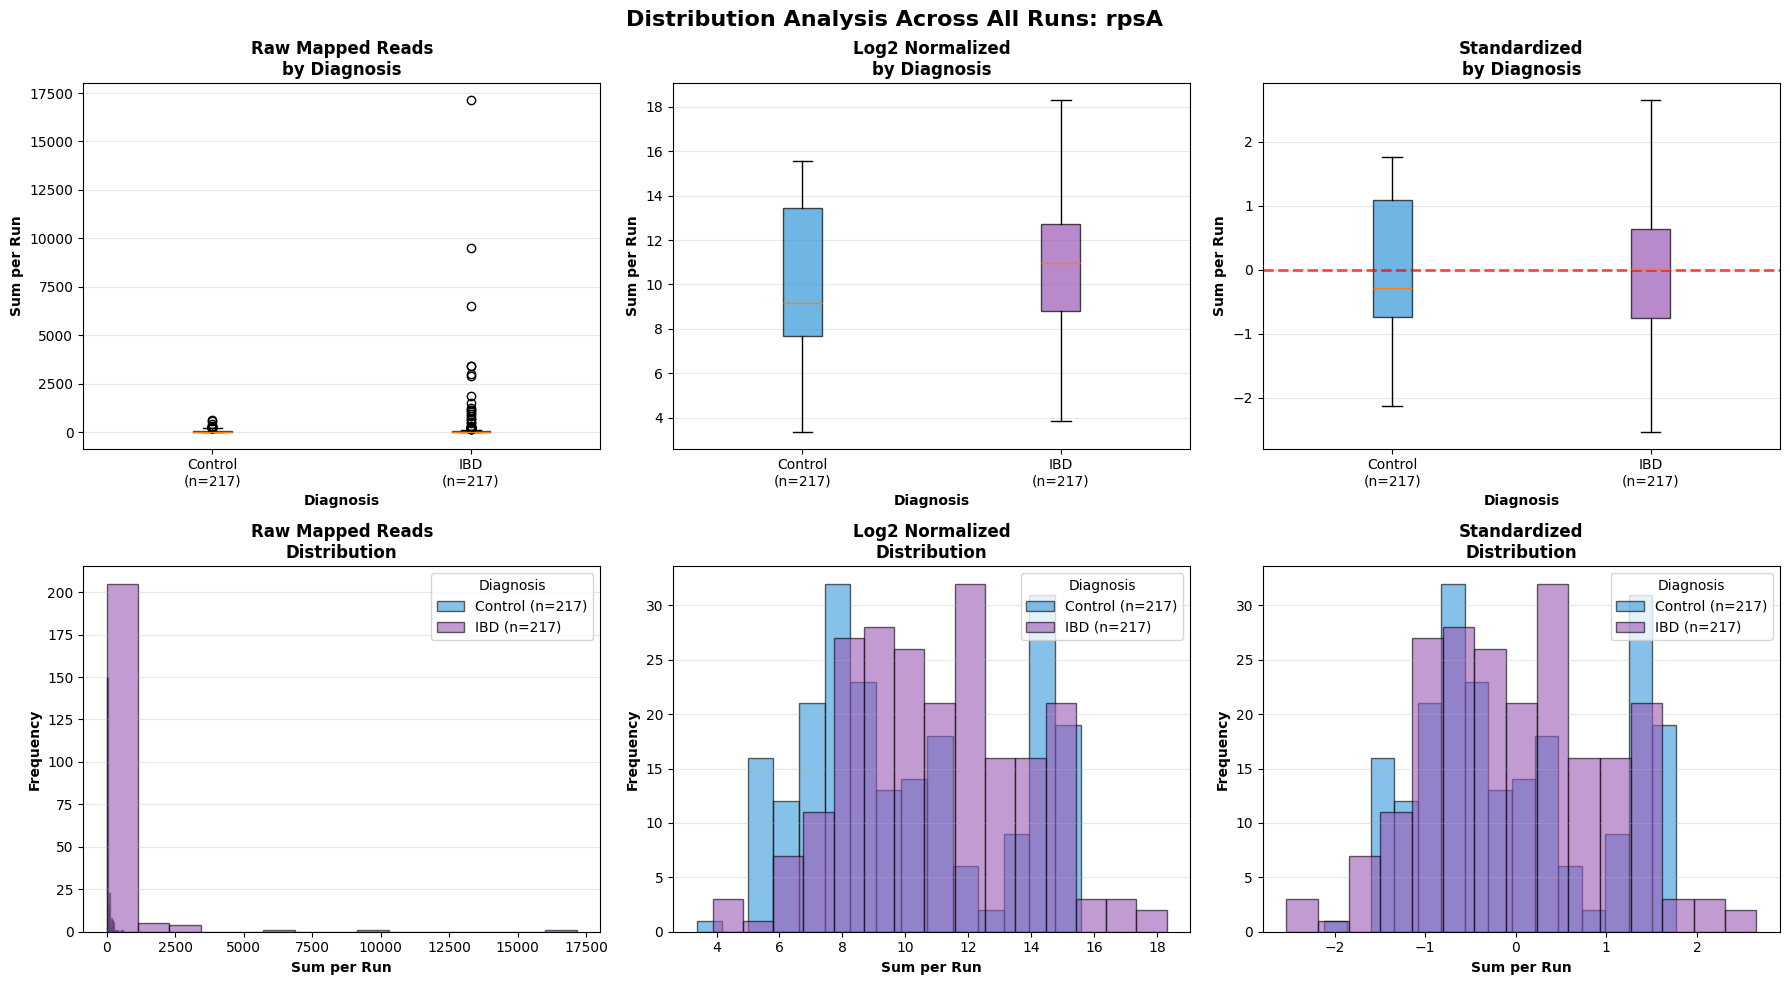

In [54]:
fig = visualize_distribution_across_runs(df_subset, gene_name='rpsA') #not subsetting skews data to IBD
plt.show()

In [55]:
print(df_subset.head())

   index                                             contig         run  \
0      0  GCF_907175785.1_lcl|NZ_CAJSIV010000001.1_cds_W...  SRR6468546   
1      1  GCF_900480325.1_lcl|NZ_UDAQ01000033.1_cds_WP_0...  SRR6468546   
2      3  GCF_900536585.1_lcl|NZ_UNQF01000043.1_cds_WP_0...  SRR6468546   
3      4  GCF_900195445.1_lcl|NZ_FZFM01000005.1_cds_WP_0...  SRR6468546   
4      5  GCF_949281785.1_lcl|NZ_CASDNJ010000003.1_cds_W...  SRR6468546   

  diagnosis  read_count  length  mapped  unmapped  net_mapped  average_depth  \
0   Control    13984243    2388       2         0           2           0.08   
1   Control    13984243    2673       2         0           2           0.07   
2   Control    13984243     279       1         0           1           0.36   
3   Control    13984243     726       1         1           0           0.04   
4   Control    13984243     375       2         0           2           0.38   

   ...                                           organism  \
0  ... 

In [56]:
pivot_data = df_subset.pivot_table(
    index='run',
    columns='gene_name',
    values='standardized_norm', #'log_map_norm_standardized',
    aggfunc='mean'
)

print("Pivoted data shape:", pivot_data.shape)
print("\nFirst few rows:")
print(pivot_data.head())

print(f"\nMissing values per gene:\n{pivot_data.isnull().sum()}")
print(f"\nTotal missing values: {pivot_data.isnull().sum().sum()}")

diagnosis_map = df_subset.groupby('run')['diagnosis'].first()
pivot_data['diagnosis'] = pivot_data.index.map(diagnosis_map)

X = pivot_data.drop('diagnosis', axis=1)
y = pivot_data['diagnosis']

Pivoted data shape: (634, 41)

First few rows:
gene_name  STM3354  STM3355      hemC      infB      pheS      pheT      rnhB  \
run                                                                             
ERR011087      NaN      NaN       NaN       NaN       NaN       NaN       NaN   
ERR011088      NaN      NaN       NaN       NaN       NaN       NaN       NaN   
ERR011089      NaN      NaN -0.590826 -0.443902 -0.979086 -0.867352 -1.081023   
ERR011090      NaN      NaN -1.107435 -0.758683 -0.916751 -0.901097 -1.232359   
ERR011091      NaN      NaN -0.713177 -0.745913 -1.680379 -0.654552 -1.051772   

gene_name      rplA      rplB      rplC  ...      rpsJ      rpsK      rpsL  \
run                                      ...                                 
ERR011087 -1.128123       NaN -1.282520  ...       NaN       NaN -1.374400   
ERR011088       NaN       NaN       NaN  ...       NaN       NaN       NaN   
ERR011089 -0.438104 -0.884290       NaN  ... -0.373788 -0.008515 -0.47071


Samples: 634
Genes: 41
Diagnoses: {'Control': 317, 'IBD': 317}

=== Gene Expression Statistics ===
gene_name     STM3354     STM3355        hemC        infB        pheS  \
count      634.000000  634.000000  634.000000  634.000000  634.000000   
mean        -0.130973   -0.046534   -0.053941   -0.299273   -0.117152   
std          0.390238    0.314781    0.798263    0.999806    0.737335   
min         -2.046063   -2.860329   -2.752031   -2.981125   -2.225037   
25%          0.000000    0.000000   -0.245373   -0.941696   -0.516606   
50%          0.000000    0.000000    0.000000    0.000000    0.000000   
75%          0.000000    0.000000    0.074754    0.026362    0.000000   
max          1.168088    1.070676    2.284414    2.420514    2.263981   

gene_name        pheT        rnhB        rplA        rplB        rplC  ...  \
count      634.000000  634.000000  634.000000  634.000000  634.000000  ...   
mean        -0.313961   -0.003046   -0.047124   -0.062619   -0.019351  ...   
std     

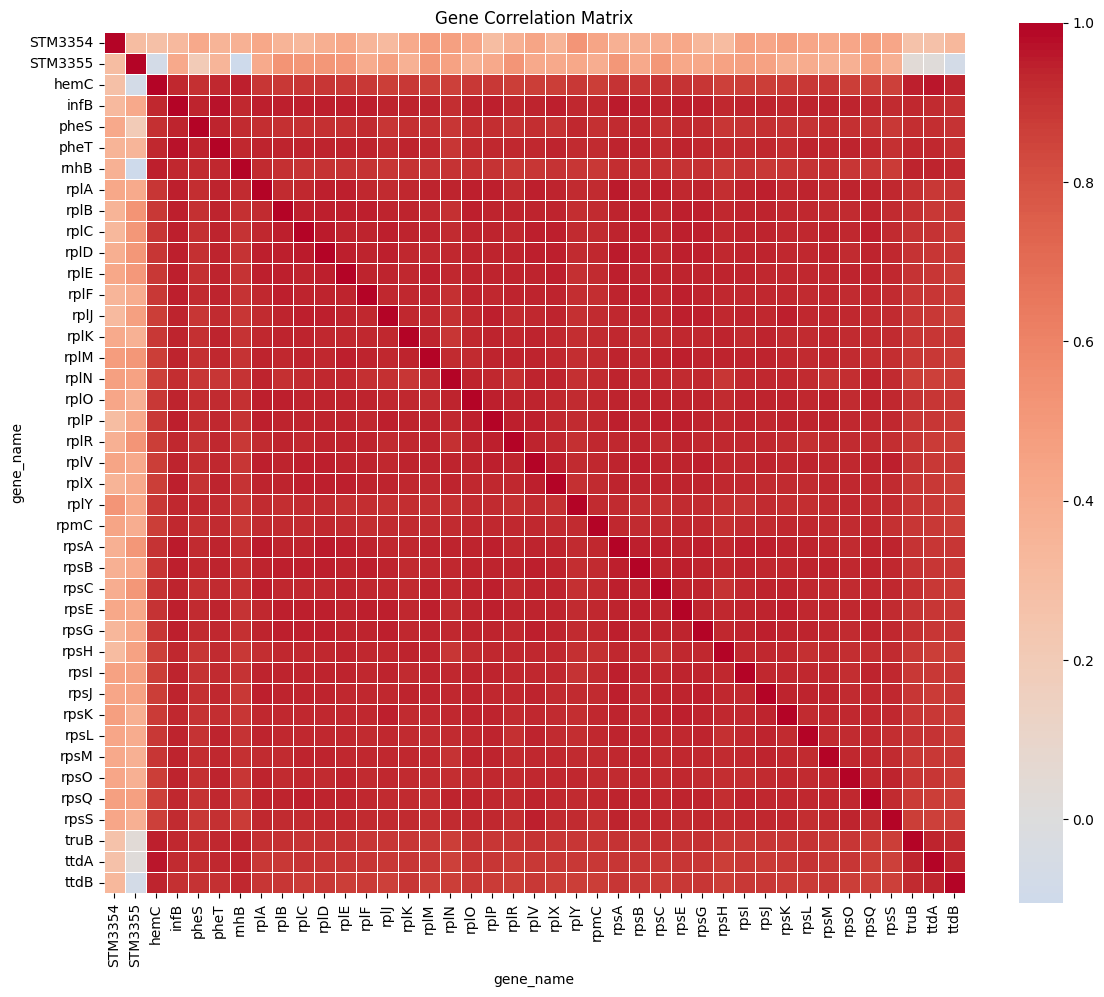


Heatmap dimensions: 634 samples x 41 genes


/home/colton/miniconda3/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/colton/miniconda3/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1400x800 with 0 Axes>

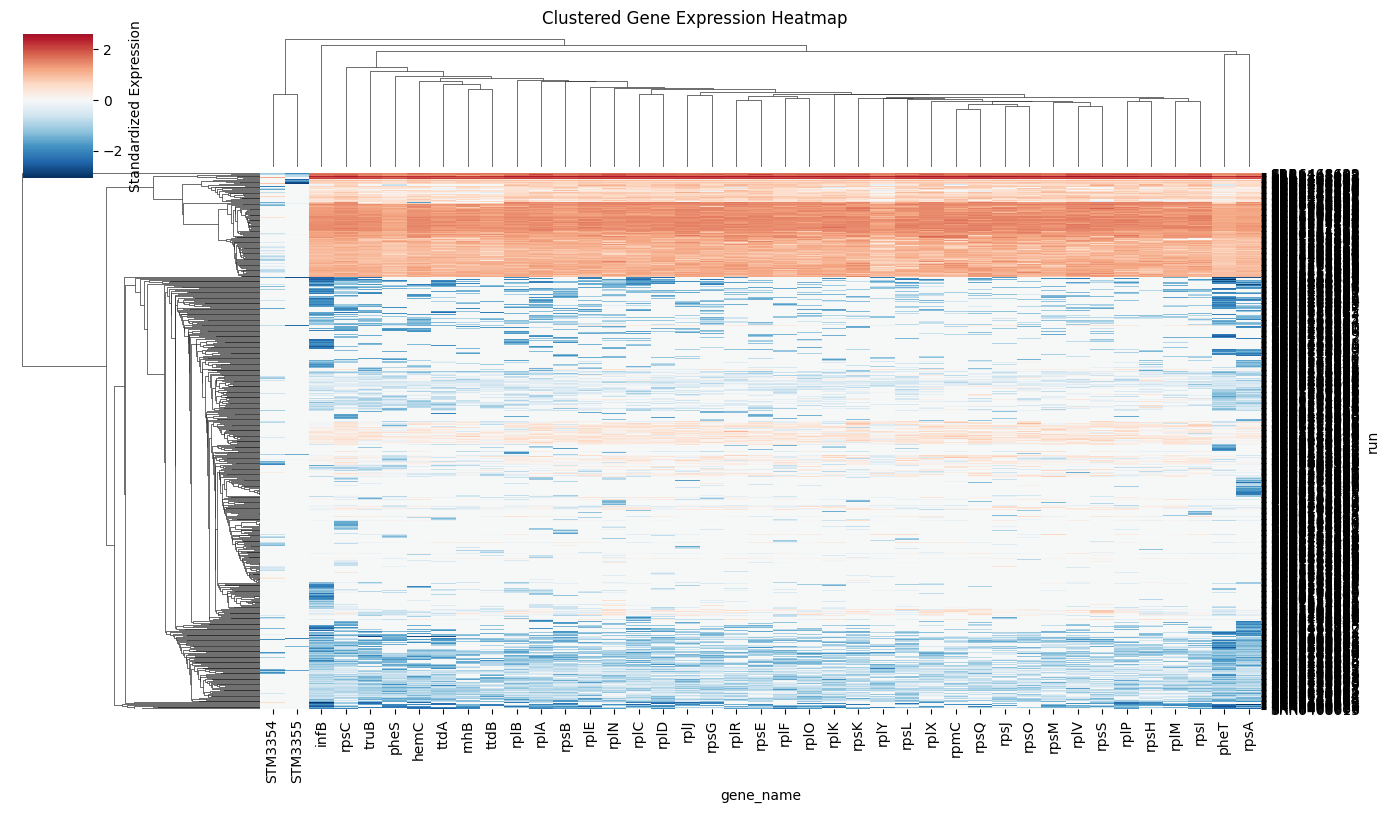


=== Most Common Genes ===
gene_name
STM3354    634
STM3355    634
hemC       634
infB       634
pheS       634
pheT       634
rnhB       634
rplA       634
rplB       634
rplC       634
rplD       634
rplE       634
rplF       634
rplJ       634
rplK       634
rplM       634
rplN       634
rplO       634
rplP       634
rplR       634
dtype: int64

=== Gene Group Comparison ===
Group 1: 20 genes
Group 2: 21 genes
T-statistic: -10.6831
P-value: 0.0000


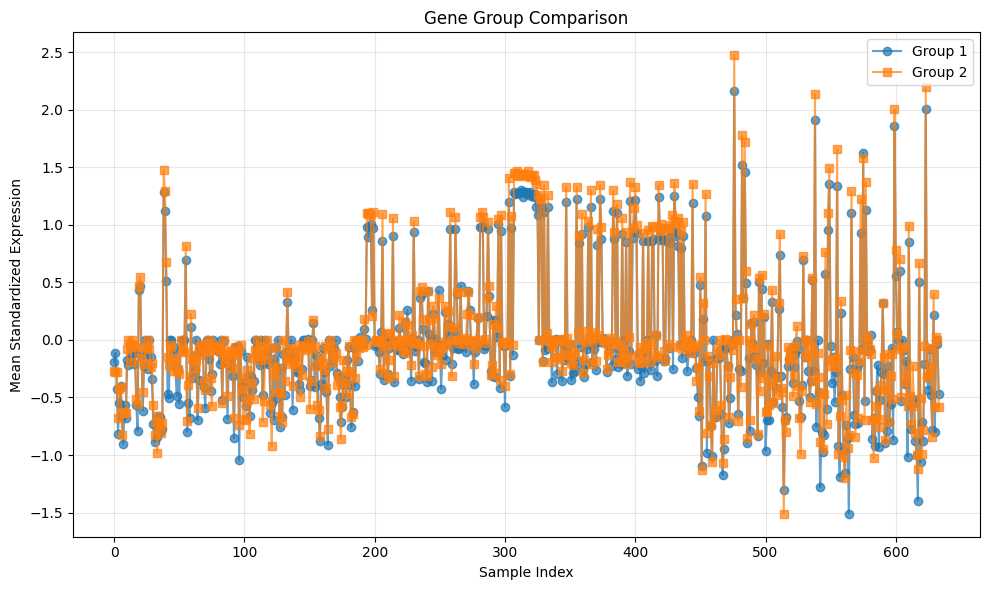

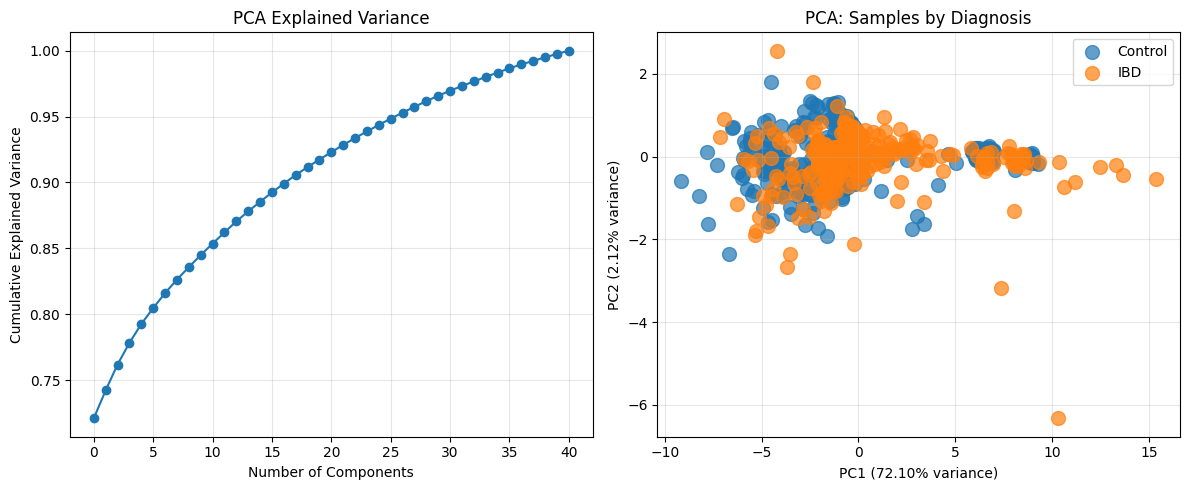

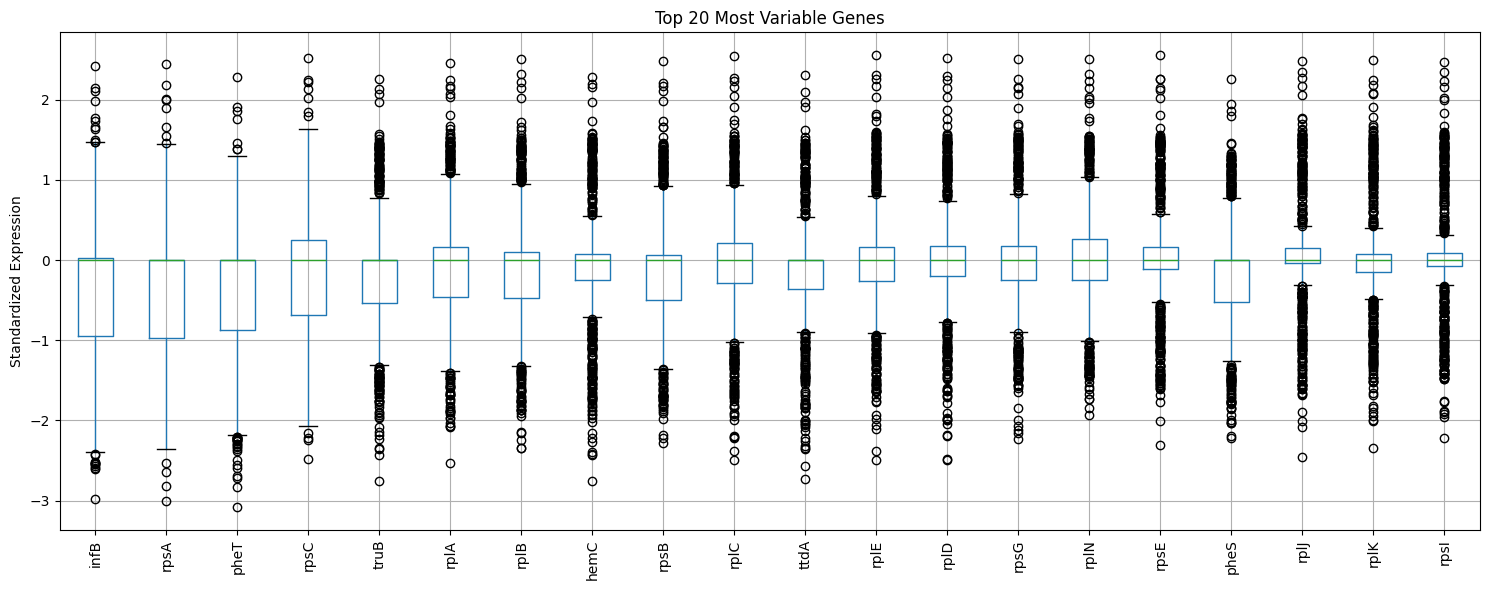


=== Differential Expression Analysis ===

Top 10 Differentially Expressed Genes:
       gene  t_statistic   p_value  mean_difference  Control_mean  IBD_mean  \
16     rplN    -3.695000  0.000239        -0.215507     -0.085564  0.129942   
34     rpsM    -3.419443  0.000668        -0.184034     -0.019893  0.164141   
24     rpsA    -3.308007  0.000993        -0.240451     -0.394753 -0.154302   
36     rpsQ    -3.002270  0.002786        -0.157305      0.039083  0.196388   
26     rpsC    -2.957765  0.003215        -0.202536     -0.219874 -0.017338   
35     rpsO    -2.938223  0.003421        -0.149087      0.037088  0.186175   
9      rplC    -2.834343  0.004739        -0.175284     -0.106993  0.068291   
1   STM3355     2.799409  0.005276         0.069619     -0.011725 -0.081344   
33     rpsL    -2.732179  0.006468        -0.148374     -0.026802  0.121571   
17     rplO    -2.731660  0.006478        -0.151944     -0.029342  0.122602   

    Control_n  IBD_n  
16        317    317  
34

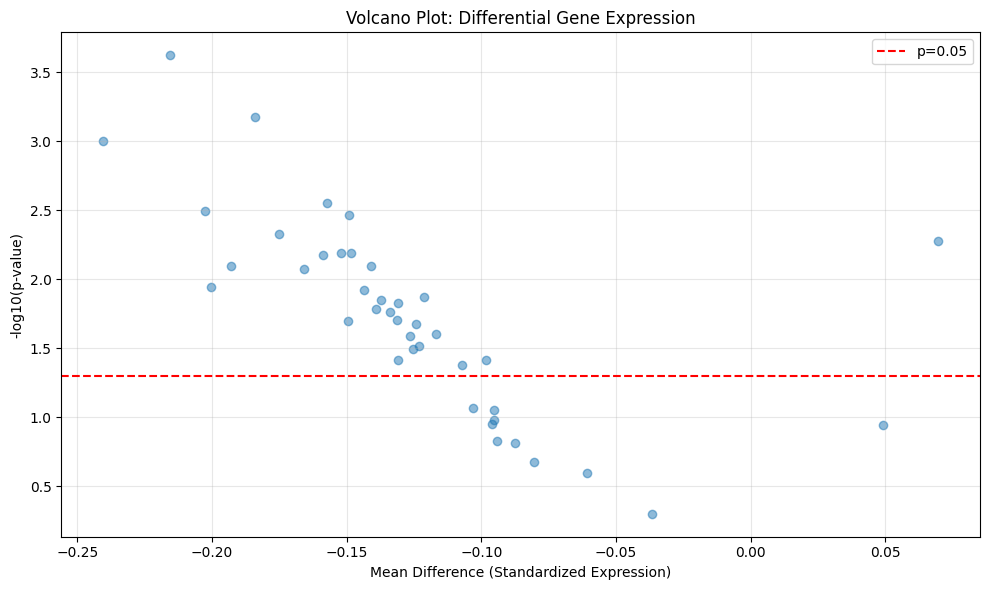


=== Top 10 Most Variable Genes ===
gene_name
infB    0.999611
rpsA    0.850583
pheT    0.843034
rpsC    0.752299
truB    0.669204
rplA    0.659178
rplB    0.650200
hemC    0.637224
rpsB    0.631752
rplC    0.612924
dtype: float64


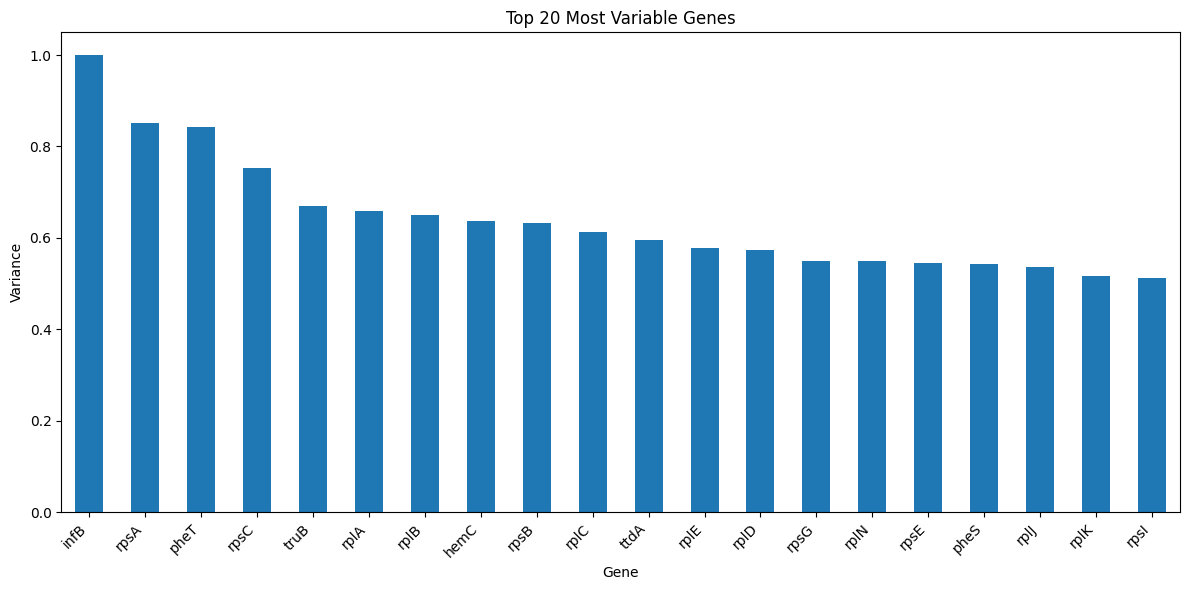


=== Analysis Complete ===
All plots saved to current directory


In [57]:
# IMPORTANT: Handle missing values
# Option 1: Fill with 0 (assuming standardized data, 0 = mean)
X_clean = X.fillna(0)

# Option 2: Drop genes with too many missing values (uncomment if preferred)
# threshold = 0.5  # Drop genes missing in >50% of samples
# X_clean = X.dropna(axis=1, thresh=int(threshold * len(X)))

# Option 3: Drop samples with too many missing values (uncomment if preferred)
# X_clean = X.dropna(axis=0, thresh=int(0.8 * len(X.columns)))

print(f"\nSamples: {len(X_clean)}")
print(f"Genes: {len(X_clean.columns)}")
print(f"Diagnoses: {y.value_counts().to_dict()}")

# ===== ANALYSIS 1: Basic Statistics =====
print("\n=== Gene Expression Statistics ===")
print(X_clean.describe())

# ===== ANALYSIS 2: Correlation Matrix Heatmap =====
# Only use genes present in enough samples for meaningful correlation
genes_with_data = X_clean.columns[X_clean.notna().sum() > len(X_clean) * 0.5]
X_for_corr = X_clean[genes_with_data]

if len(X.columns) > 1:
    plt.figure(figsize=(12, 10))
    correlation = X.corr()
    sns.heatmap(correlation, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5)
    plt.title('Gene Correlation Matrix')
    plt.tight_layout()
    plt.savefig('gene_correlation.png', dpi=300, bbox_inches='tight')
    plt.show()

# ===== ANALYSIS 3: Expression Heatmap (FIXED) =====
# Remove genes/samples with too many missing values for clustering
min_data_threshold = 0.7  # Require 70% non-missing data

# Filter genes and samples
genes_mask = X_clean.notna().sum() >= len(X_clean) * min_data_threshold
samples_mask = X_clean.notna().sum(axis=1) >= len(X_clean.columns) * min_data_threshold

X_for_heatmap = X_clean.loc[samples_mask, genes_mask].fillna(0)

print(f"\nHeatmap dimensions: {X_for_heatmap.shape[0]} samples x {X_for_heatmap.shape[1]} genes")

if X_for_heatmap.shape[0] > 1 and X_for_heatmap.shape[1] > 1:
    try:
        plt.figure(figsize=(14, 8))
        g = sns.clustermap(X_for_heatmap, cmap='RdBu_r', center=0, 
                           row_cluster=True, col_cluster=True,
                           figsize=(14, 8), 
                           cbar_kws={'label': 'Standardized Expression'},
                           yticklabels=True)
        g.fig.suptitle('Clustered Gene Expression Heatmap', y=1.01)
        plt.savefig('expression_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Could not create clustermap: {e}")
        # Fallback to simple heatmap
        plt.figure(figsize=(14, 8))
        sns.heatmap(X_for_heatmap.T, cmap='RdBu_r', center=0,
                   cbar_kws={'label': 'Standardized Expression'})
        plt.xlabel('Samples')
        plt.ylabel('Genes')
        plt.title('Gene Expression Heatmap (No Clustering)')
        plt.tight_layout()
        plt.savefig('expression_heatmap_simple.png', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("Not enough data for heatmap after filtering")

# ===== ANALYSIS 4: Compare Gene Groups =====
# Get the most common genes
gene_counts = X_clean.notna().sum().sort_values(ascending=False)
print("\n=== Most Common Genes ===")
print(gene_counts.head(20))

# Define your gene groups based on genes that actually exist
available_genes = gene_counts[gene_counts > len(X_clean) * 0.5].index.tolist()

# Example groupings - modify based on your actual genes
if len(available_genes) >= 4:
    group1_genes = available_genes[:len(available_genes)//2]
    group2_genes = available_genes[len(available_genes)//2:]
    
    group1_mean = X_clean[group1_genes].mean(axis=1)
    group2_mean = X_clean[group2_genes].mean(axis=1)
    
    # Paired t-test
    t_stat, p_value = stats.ttest_rel(group1_mean, group2_mean)
    print(f"\n=== Gene Group Comparison ===")
    print(f"Group 1: {len(group1_genes)} genes")
    print(f"Group 2: {len(group2_genes)} genes")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    # Visualize
    plt.figure(figsize=(10, 6))
    plt.plot(group1_mean.values, label='Group 1', marker='o', alpha=0.7)
    plt.plot(group2_mean.values, label='Group 2', marker='s', alpha=0.7)
    plt.xlabel('Sample Index')
    plt.ylabel('Mean Standardized Expression')
    plt.legend()
    plt.title('Gene Group Comparison')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('gene_group_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# ===== ANALYSIS 5: PCA =====
# Use only complete cases or filled data
X_pca = X_clean.fillna(0)

pca = PCA()
pca_result = pca.fit_transform(X_pca)

# Scree plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True, alpha=0.3)

# PCA scatter plot colored by diagnosis
plt.subplot(1, 2, 2)
for diagnosis in y.unique():
    mask = y == diagnosis
    plt.scatter(pca_result[mask, 0], pca_result[mask, 1], 
               label=diagnosis, alpha=0.7, s=100)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA: Samples by Diagnosis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()



# ===== ANALYSIS 6: Boxplot by Gene =====
# Show top 20 most variable genes
top_genes = X_clean.var().sort_values(ascending=False).head(20).index
if len(top_genes) > 0:
    plt.figure(figsize=(15, 6))
    X_clean[top_genes].boxplot(rot=90)
    plt.ylabel('Standardized Expression')
    plt.title('Top 20 Most Variable Genes')
    plt.tight_layout()
    plt.savefig('gene_boxplots.png', dpi=300, bbox_inches='tight')
    plt.show()

# ===== ANALYSIS 7: Differential Expression by Diagnosis =====
if len(y.unique()) == 2:
    print("\n=== Differential Expression Analysis ===")
    
    diagnosis_groups = y.unique()
    group1_samples = y == diagnosis_groups[0]
    group2_samples = y == diagnosis_groups[1]
    
    diff_results = []
    for gene in X_clean.columns:
        group1_expr = X_clean.loc[group1_samples, gene].dropna()
        group2_expr = X_clean.loc[group2_samples, gene].dropna()
        
        if len(group1_expr) > 2 and len(group2_expr) > 2:  # Need at least 3 samples
            t_stat, p_val = stats.ttest_ind(group1_expr, group2_expr)
            mean_diff = group1_expr.mean() - group2_expr.mean()
            
            diff_results.append({
                'gene': gene,
                't_statistic': t_stat,
                'p_value': p_val,
                'mean_difference': mean_diff,
                f'{diagnosis_groups[0]}_mean': group1_expr.mean(),
                f'{diagnosis_groups[1]}_mean': group2_expr.mean(),
                f'{diagnosis_groups[0]}_n': len(group1_expr),
                f'{diagnosis_groups[1]}_n': len(group2_expr)
            })
    
    if diff_results:
        diff_df = pd.DataFrame(diff_results).sort_values('p_value')
        print("\nTop 10 Differentially Expressed Genes:")
        print(diff_df.head(10))
        
        # Volcano plot
        plt.figure(figsize=(10, 6))
        plt.scatter(diff_df['mean_difference'], 
                   -np.log10(diff_df['p_value']),
                   alpha=0.5)
        plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
        plt.xlabel('Mean Difference (Standardized Expression)')
        plt.ylabel('-log10(p-value)')
        plt.title('Volcano Plot: Differential Gene Expression')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('volcano_plot.png', dpi=300, bbox_inches='tight')
        plt.show()

# ===== ANALYSIS 8: Gene Variance =====
gene_variance = X_clean.var().sort_values(ascending=False)
print("\n=== Top 10 Most Variable Genes ===")
print(gene_variance.head(10))

plt.figure(figsize=(12, 6))
gene_variance.head(20).plot(kind='bar')
plt.ylabel('Variance')
plt.xlabel('Gene')
plt.title('Top 20 Most Variable Genes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('gene_variance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Analysis Complete ===")
print(f"All plots saved to current directory")


=== Differential Expression Analysis ===
['Control' 'IBD'] Control IBD

Top 10 Differentially Expressed Genes:
       gene  t_statistic   p_value  mean_difference  Control_mean  IBD_mean  \
16     rplN    -3.695000  0.000239         0.215507     -0.085564  0.129942   
34     rpsM    -3.419443  0.000668         0.184034     -0.019893  0.164141   
24     rpsA    -3.308007  0.000993         0.240451     -0.394753 -0.154302   
36     rpsQ    -3.002270  0.002786         0.157305      0.039083  0.196388   
26     rpsC    -2.957765  0.003215         0.202536     -0.219874 -0.017338   
35     rpsO    -2.938223  0.003421         0.149087      0.037088  0.186175   
9      rplC    -2.834343  0.004739         0.175284     -0.106993  0.068291   
1   STM3355     2.799409  0.005276        -0.069619     -0.011725 -0.081344   
33     rpsL    -2.732179  0.006468         0.148374     -0.026802  0.121571   
17     rplO    -2.731660  0.006478         0.151944     -0.029342  0.122602   

    Control_n  IBD

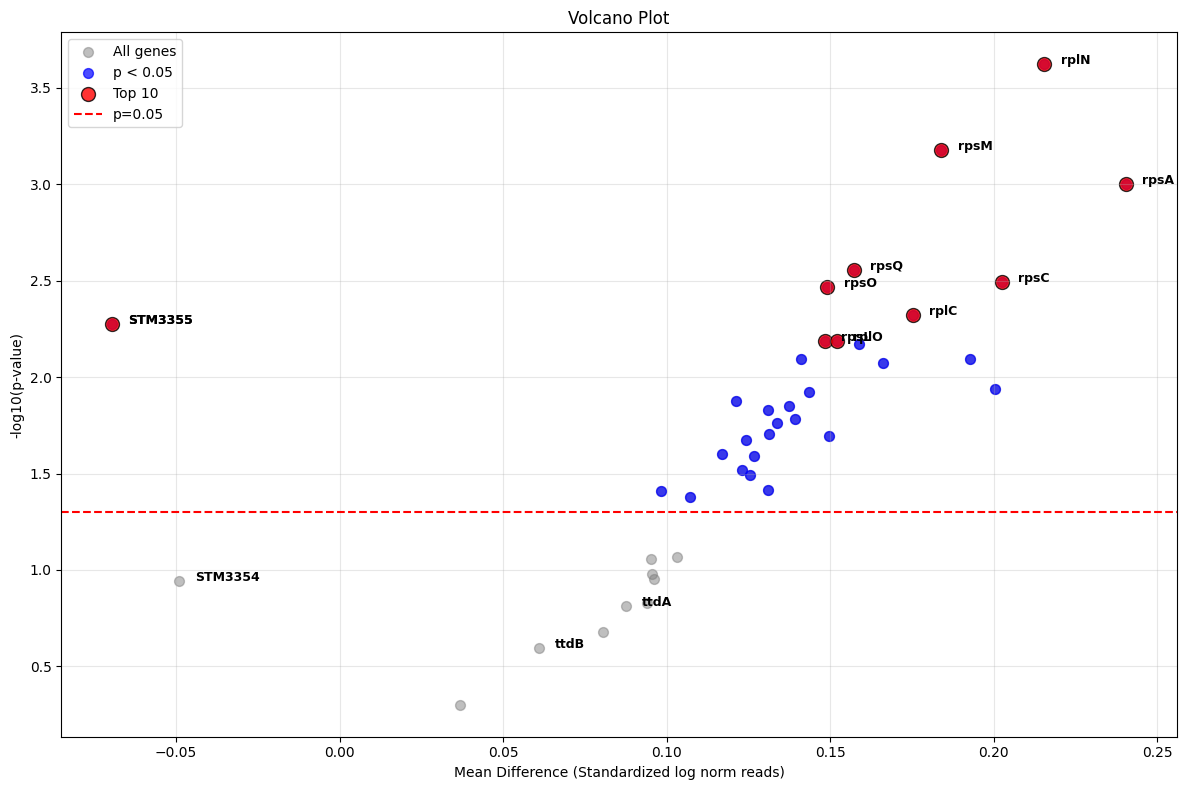

In [58]:
if len(y.unique()) == 2:
    print("\n=== Differential Expression Analysis ===")
    
    diagnosis_groups = y.unique()
    print(diagnosis_groups, diagnosis_groups[0], diagnosis_groups[1])
    control_samples = y == diagnosis_groups[0]
    ibd_samples = y == diagnosis_groups[1]
    
    diff_results = []
    for gene in X_clean.columns:
        control_expr = X_clean.loc[control_samples, gene].dropna()
        ibd_expr = X_clean.loc[ibd_samples, gene].dropna()
        
        if len(control_expr) > 2 and len(ibd_expr) > 2:  # Need at least 3 samples
            t_stat, p_val = stats.ttest_ind(control_expr, ibd_expr)
            mean_diff = ibd_expr.mean() - control_expr.mean()
            
            diff_results.append({
                'gene': gene,
                't_statistic': t_stat,
                'p_value': p_val,
                'mean_difference': mean_diff,
                f'{diagnosis_groups[0]}_mean': control_expr.mean(),
                f'{diagnosis_groups[1]}_mean': ibd_expr.mean(),
                f'{diagnosis_groups[0]}_n': len(control_expr),
                f'{diagnosis_groups[1]}_n': len(ibd_expr)
            })
    
    if diff_results:
        diff_df = pd.DataFrame(diff_results).sort_values('p_value')
        print("\nTop 10 Differentially Expressed Genes:")
        print(diff_df.head(10))
        
        plt.figure(figsize=(12, 8))
        
        # Plot all points
        plt.scatter(diff_df['mean_difference'], 
                   -np.log10(diff_df['p_value']),
                   alpha=0.5, s=50, c='gray', label='All genes')
        
        # Highlight significant genes (p < 0.05)
        significant = diff_df[diff_df['p_value'] < 0.05]
        if len(significant) > 0:
            plt.scatter(significant['mean_difference'], 
                       -np.log10(significant['p_value']),
                       alpha=0.7, s=50, c='blue', label='p < 0.05')
        
        # Get top 10 most significant genes
        top_10 = diff_df.head(10)
        
        # Plot top 10 with different color
        plt.scatter(top_10['mean_difference'], 
                   -np.log10(top_10['p_value']),
                   alpha=0.8, s=100, c='red', label='Top 10', 
                   edgecolors='black', linewidths=1)
        
        # Add labels for top 10
        texts = []
        for idx, row in top_10.iterrows():
            texts.append(plt.text(row['mean_difference']+.005, 
                                 -np.log10(row['p_value']),
                                 row['gene'],
                                 fontsize=9,
                                 weight='bold'))
            
        specific_genes = ['ttdA', 'ttdB', 'STM3355', 'STM3354']  # Add your genes of interest
        
        for gene_name in specific_genes:
            if gene_name in diff_df['gene'].values:
                gene_row = diff_df[diff_df['gene'] == gene_name].iloc[0]
                texts.append(plt.text(gene_row['mean_difference'] + 0.005, 
                                     -np.log10(gene_row['p_value']),
                                     gene_name,
                                     fontsize=9,
                                     weight='bold'))
            
        plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
        plt.xlabel('Mean Difference (Standardized log norm reads)')
        plt.ylabel('-log10(p-value)')
        plt.title('Volcano Plot')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('volcano_plot.png', dpi=300, bbox_inches='tight')
        plt.show()



=== Differential Expression Analysis (Robust) ===
       gene  u_statistic   p_value  mean_difference  median_difference  \
24     rpsA      18705.0  0.000212         0.351257           0.663733   
30     rpsI      11797.0  0.023523         0.234872           0.404733   
34     rpsM      10568.0  0.001065         0.355961           0.483993   
36     rpsQ      10110.0  0.009875         0.313569           0.373435   
21     rplX      11514.0  0.019637         0.247233           0.307753   
27     rpsE      12573.0  0.008080         0.288373           0.389794   
15     rplM      10668.0  0.012868         0.276028           0.313200   
17     rplO      11380.0  0.010144         0.288754           0.371070   
23     rpmC       8229.0  0.026517         0.259839           0.258906   
22     rplY       8373.0  0.036200         0.217385           0.281591   
31     rpsJ      10612.0  0.027534         0.223791           0.242137   
9      rplC      13946.0  0.003604         0.304020          

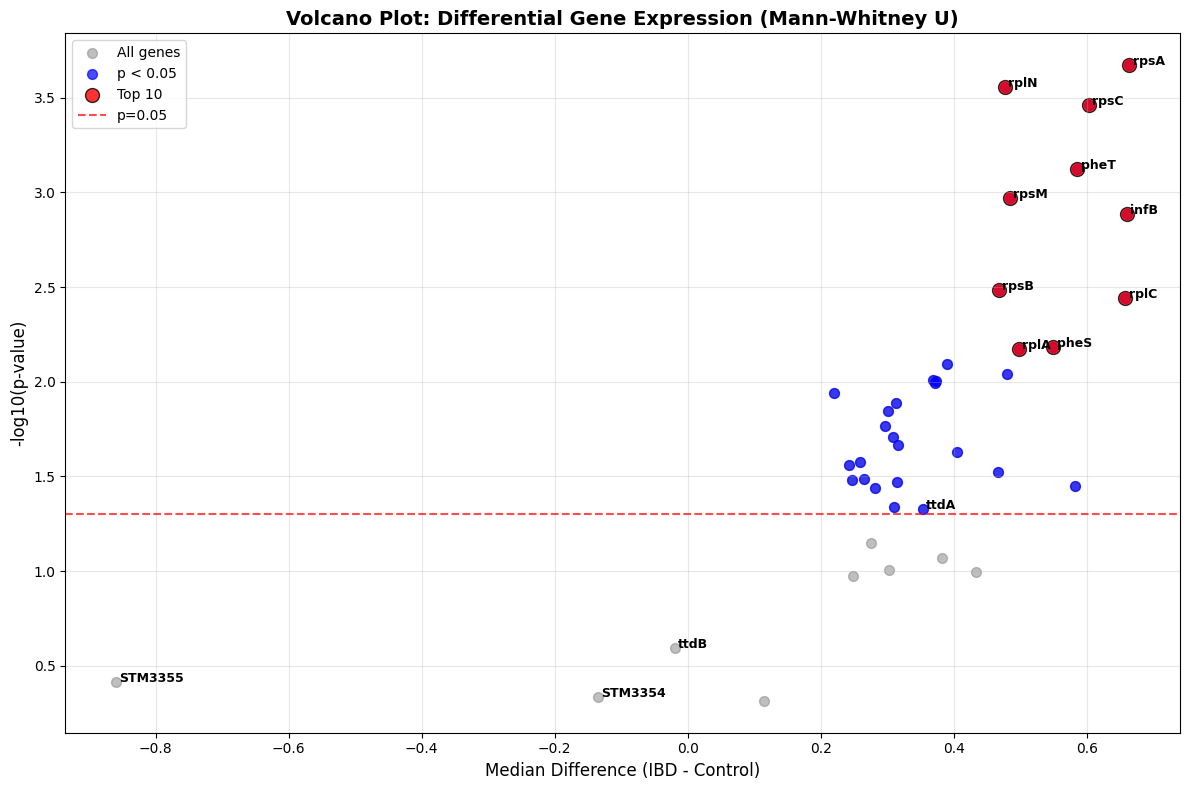

In [59]:
if len(y.unique()) == 2:
    print("\n=== Differential Expression Analysis (Robust) ===")
    
    diagnosis_groups = y.unique()
    control_samples = y == diagnosis_groups[0]
    ibd_samples = y == diagnosis_groups[1]
    
    min_prevalence = 0 # Require gene in 30% of samples per group
    
    diff_results = []
    for gene in X.columns:
        control_expr = X.loc[control_samples, gene].dropna()
        ibd_expr = X.loc[ibd_samples, gene].dropna()
        
        control_prevalence = len(control_expr) / control_samples.sum()
        ibd_prevalence = len(ibd_expr) / ibd_samples.sum()
        
        if (control_prevalence >= min_prevalence and 
            ibd_prevalence >= min_prevalence and
            len(control_expr) > 2 and len(ibd_expr) > 2):
            
            # Use Mann-Whitney U test (non-parametric)
            u_stat, p_val = stats.mannwhitneyu(control_expr, ibd_expr, alternative='two-sided')
            
            # Calculate both mean and median differences
            mean_diff = ibd_expr.mean() - control_expr.mean()
            median_diff = ibd_expr.median() - control_expr.median()
            prevalence_diff = ibd_prevalence - control_prevalence
            
            diff_results.append({
                'gene': gene,
                'u_statistic': u_stat,
                'p_value': p_val,
                'mean_difference': mean_diff,
                'median_difference': median_diff,
                'prevalence_difference': prevalence_diff,
                f'{diagnosis_groups[0]}_mean': control_expr.mean(),
                f'{diagnosis_groups[1]}_mean': ibd_expr.mean(),
                f'{diagnosis_groups[0]}_median': control_expr.median(),
                f'{diagnosis_groups[1]}_median': ibd_expr.median(),
                f'{diagnosis_groups[0]}_n': len(control_expr),
                f'{diagnosis_groups[1]}_n': len(ibd_expr),
                f'{diagnosis_groups[0]}_prevalence': control_prevalence,
                f'{diagnosis_groups[1]}_prevalence': ibd_prevalence,
            })
    
    if diff_results:
        diff_df = pd.DataFrame(diff_results).sort_values('p_value')
        print(diff_df.sort_values('prevalence_difference'))
        print(f"\nAnalyzed {len(diff_df)} genes with ≥{min_prevalence*100}% prevalence")
        print("\nTop 10 Differentially Expressed Genes:")
        print(diff_df[['gene', 'p_value', 'median_difference', 
                       f'{diagnosis_groups[0]}_prevalence', 
                       f'{diagnosis_groups[1]}_prevalence']].head(10))
        
        # Volcano plot using MEDIAN difference
        plt.figure(figsize=(12, 8))
        
        plt.scatter(diff_df['median_difference'], 
                   -np.log10(diff_df['p_value']),
                   alpha=0.5, s=50, c='gray', label='All genes')
        
        significant = diff_df[diff_df['p_value'] < 0.05]
        if len(significant) > 0:
            plt.scatter(significant['median_difference'], 
                       -np.log10(significant['p_value']),
                       alpha=0.7, s=50, c='blue', label='p < 0.05')
        
        top_10 = diff_df.head(10)
        plt.scatter(top_10['median_difference'], 
                   -np.log10(top_10['p_value']),
                   alpha=0.8, s=100, c='red', label='Top 10', 
                   edgecolors='black', linewidths=1)
        
        texts = []
        for idx, row in top_10.iterrows():
            texts.append(plt.text(row['median_difference'] + 0.005, 
                                 -np.log10(row['p_value']),
                                 row['gene'],
                                 fontsize=9,
                                 weight='bold'))
        

        specific_genes = ['ttdA', 'ttdB', 'STM3354', 'STM3355']  # Add your genes of interest
        
        for gene_name in specific_genes:
            if gene_name in diff_df['gene'].values:
                gene_row = diff_df[diff_df['gene'] == gene_name].iloc[0]
                texts.append(plt.text(gene_row['median_difference'] + 0.005, 
                                     -np.log10(gene_row['p_value']),
                                     gene_name,
                                     fontsize=9,
                                     weight='bold'))
        
        plt.axhline(-np.log10(0.05), color='red', linestyle='--', 
                   linewidth=1.5, label='p=0.05', alpha=0.7)
        
        plt.xlabel(f'Median Difference (IBD - Control)', fontsize=12)
        plt.ylabel('-log10(p-value)', fontsize=12)
        plt.title('Volcano Plot: Differential Gene Expression (Mann-Whitney U)', 
                 fontsize=14, weight='bold')
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('volcano_plot_robust.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        diff_df.to_csv('differential_expression_robust.csv', index=False)

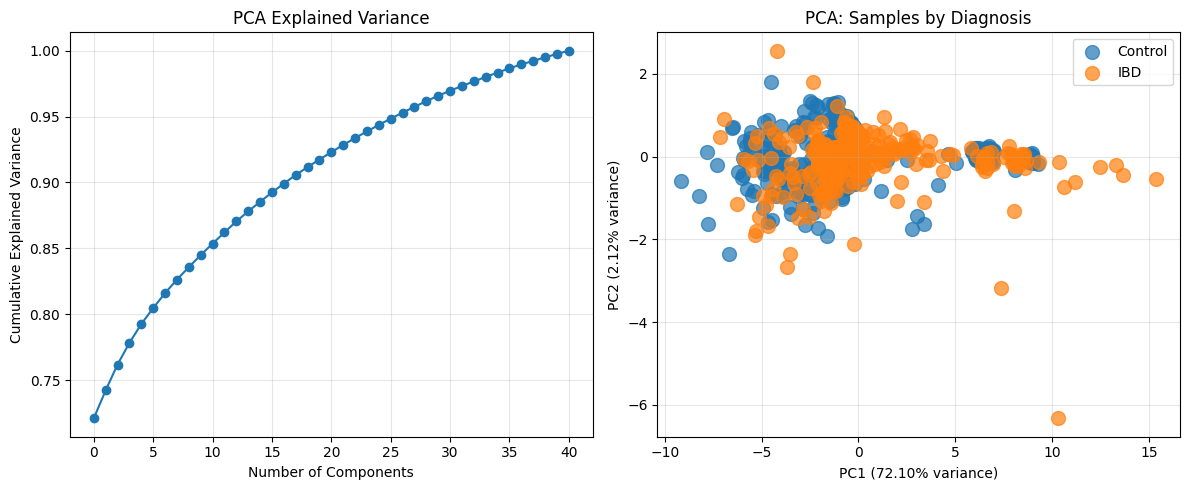


PCA created 41 components for 41 genes

=== Top 10 Genes Contributing to PC1 ===
gene_name
infB    0.205540
rpsA    0.188691
pheT    0.185925
rpsC    0.180152
rplA    0.174705
rplB    0.173250
rplC    0.171805
rpsB    0.170817
truB    0.169716
rplD    0.169177
Name: PC1, dtype: float64

=== Top 10 Genes Contributing to PC2 ===
gene_name
infB    0.404330
truB    0.376733
ttdA    0.365177
hemC    0.344341
pheT    0.327563
ttdB    0.162689
rplV    0.140488
rnhB    0.138204
rplN    0.136012
rpsB    0.134493
Name: PC2, dtype: float64


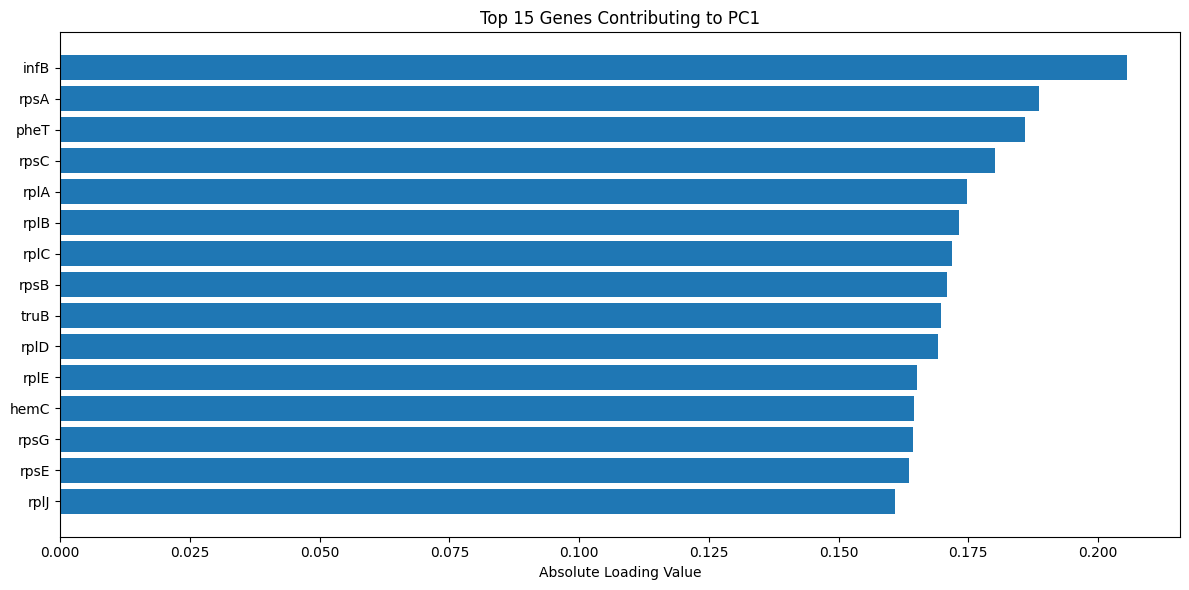

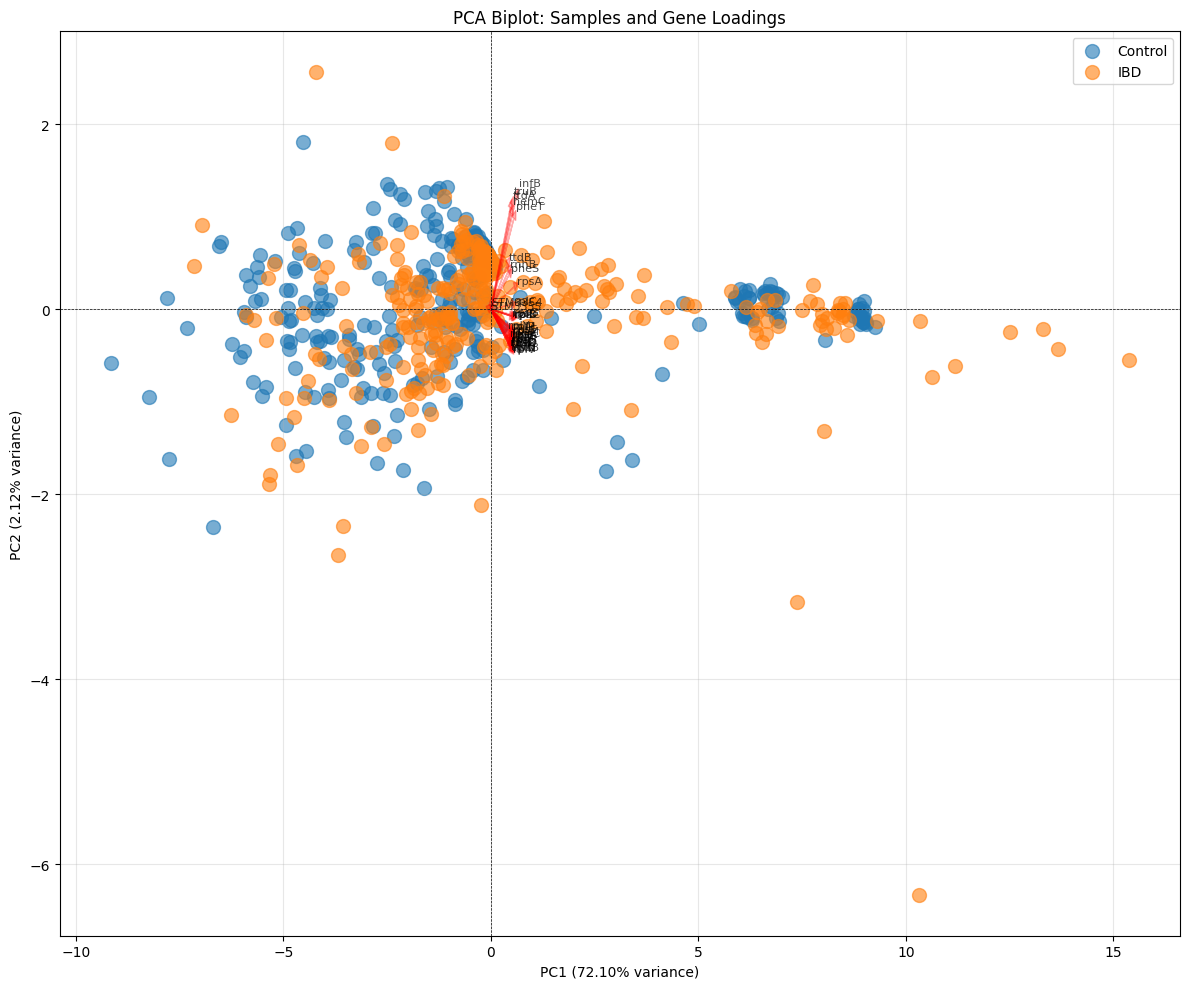

In [60]:
# ===== ANALYSIS 5: PCA (FIXED) =====
# Use only complete cases or filled data
X_pca = X_clean.fillna(0)

pca = PCA()
pca_result = pca.fit_transform(X_pca)

# Scree plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True, alpha=0.3)

# PCA scatter plot colored by diagnosis
plt.subplot(1, 2, 2)
for diagnosis in y.unique():
    mask = y == diagnosis
    plt.scatter(pca_result[mask, 0], pca_result[mask, 1], 
               label=diagnosis, alpha=0.7, s=100)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA: Samples by Diagnosis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Gene loadings for PC1 (FIXED)
# Number of components equals min(n_samples, n_features)
n_components = pca.components_.shape[0]
n_genes = len(X_clean.columns)

print(f"\nPCA created {n_components} components for {n_genes} genes")

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],  # Use actual number of components
    index=X_clean.columns
)

print("\n=== Top 10 Genes Contributing to PC1 ===")
print(loadings['PC1'].abs().sort_values(ascending=False).head(10))

# Show loadings for first few components
print("\n=== Top 10 Genes Contributing to PC2 ===")
if 'PC2' in loadings.columns:
    print(loadings['PC2'].abs().sort_values(ascending=False).head(10))

# Visualize top gene loadings
plt.figure(figsize=(12, 6))
top_loading_genes = loadings['PC1'].abs().sort_values(ascending=False).head(15)
plt.barh(range(len(top_loading_genes)), top_loading_genes.values)
plt.yticks(range(len(top_loading_genes)), top_loading_genes.index)
plt.xlabel('Absolute Loading Value')
plt.title('Top 15 Genes Contributing to PC1')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=300, bbox_inches='tight')
plt.show()

# Biplot (if you have relatively few genes)
if len(X_clean.columns) <= 50:
    plt.figure(figsize=(12, 10))
    
    # Plot samples
    for diagnosis in y.unique():
        mask = y == diagnosis
        plt.scatter(pca_result[mask, 0], pca_result[mask, 1], 
                   label=diagnosis, alpha=0.6, s=100)
    
    # Plot gene vectors (scaled for visibility)
    scale_factor = 3
    for i, gene in enumerate(X_clean.columns):
        plt.arrow(0, 0, 
                 pca.components_[0, i] * scale_factor,
                 pca.components_[1, i] * scale_factor,
                 head_width=0.1, head_length=0.1, 
                 fc='red', ec='red', alpha=0.3)
        plt.text(pca.components_[0, i] * scale_factor * 1.1,
                pca.components_[1, i] * scale_factor * 1.1,
                gene, fontsize=8, alpha=0.7)
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    plt.title('PCA Biplot: Samples and Gene Loadings')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.tight_layout()
    plt.savefig('pca_biplot.png', dpi=300, bbox_inches='tight')
    plt.show()

In [61]:
# Define your genes of interest
genes_of_interest = ['STM3354', 'STM3355', 'ttdA', 'ttdB']

# Filter to genes that exist in the data
genes_of_interest = [g for g in genes_of_interest if g in X_clean.columns]

print(f"Analyzing genes: {genes_of_interest}")

# Calculate z-score for each gene relative to all other genes in each sample
comparison_results = []

for sample in X_clean.index:
    sample_data = X_clean.loc[sample].dropna()
    
    # Calculate mean and std of all genes in this sample
    all_genes_mean = sample_data.mean()
    all_genes_std = sample_data.std()
    
    # Get values for genes of interest
    for gene in genes_of_interest:
        if gene in sample_data.index:
            gene_value = sample_data[gene]
            
            # Calculate z-score relative to all genes in this sample
            z_score = (gene_value - all_genes_mean) / all_genes_std if all_genes_std > 0 else 0
            
            # Calculate percentile rank
            percentile = stats.percentileofscore(sample_data.values, gene_value)
            
            comparison_results.append({
                'sample': sample,
                'diagnosis': y[sample],
                'gene': gene,
                'value': gene_value,
                'sample_mean': all_genes_mean,
                'sample_std': all_genes_std,
                'z_score_vs_all': z_score,
                'percentile': percentile,
                'rank': sample_data.rank(ascending=False)[gene],
                'total_genes': len(sample_data)
            })

comparison_df = pd.DataFrame(comparison_results)
print("\nComparison of genes of interest vs all other genes:")
print(comparison_df.head(20))

# Save results
comparison_df.to_csv('genes_of_interest_comparison.csv', index=False)

Analyzing genes: ['STM3354', 'STM3355', 'ttdA', 'ttdB']

Comparison of genes of interest vs all other genes:
       sample diagnosis     gene     value  sample_mean  sample_std  \
0   ERR011087   Control  STM3354  0.000000    -0.231982    0.540743   
1   ERR011087   Control  STM3355  0.000000    -0.231982    0.540743   
2   ERR011087   Control     ttdA  0.000000    -0.231982    0.540743   
3   ERR011087   Control     ttdB  0.000000    -0.231982    0.540743   
4   ERR011088   Control  STM3354  0.000000    -0.198108    0.497867   
5   ERR011088   Control  STM3355  0.000000    -0.198108    0.497867   
6   ERR011088   Control     ttdA  0.000000    -0.198108    0.497867   
7   ERR011088   Control     ttdB  0.000000    -0.198108    0.497867   
8   ERR011089   Control  STM3354  0.000000    -0.349849    0.362076   
9   ERR011089   Control  STM3355  0.000000    -0.349849    0.362076   
10  ERR011089   Control     ttdA -0.208498    -0.349849    0.362076   
11  ERR011089   Control     ttdB -1.088

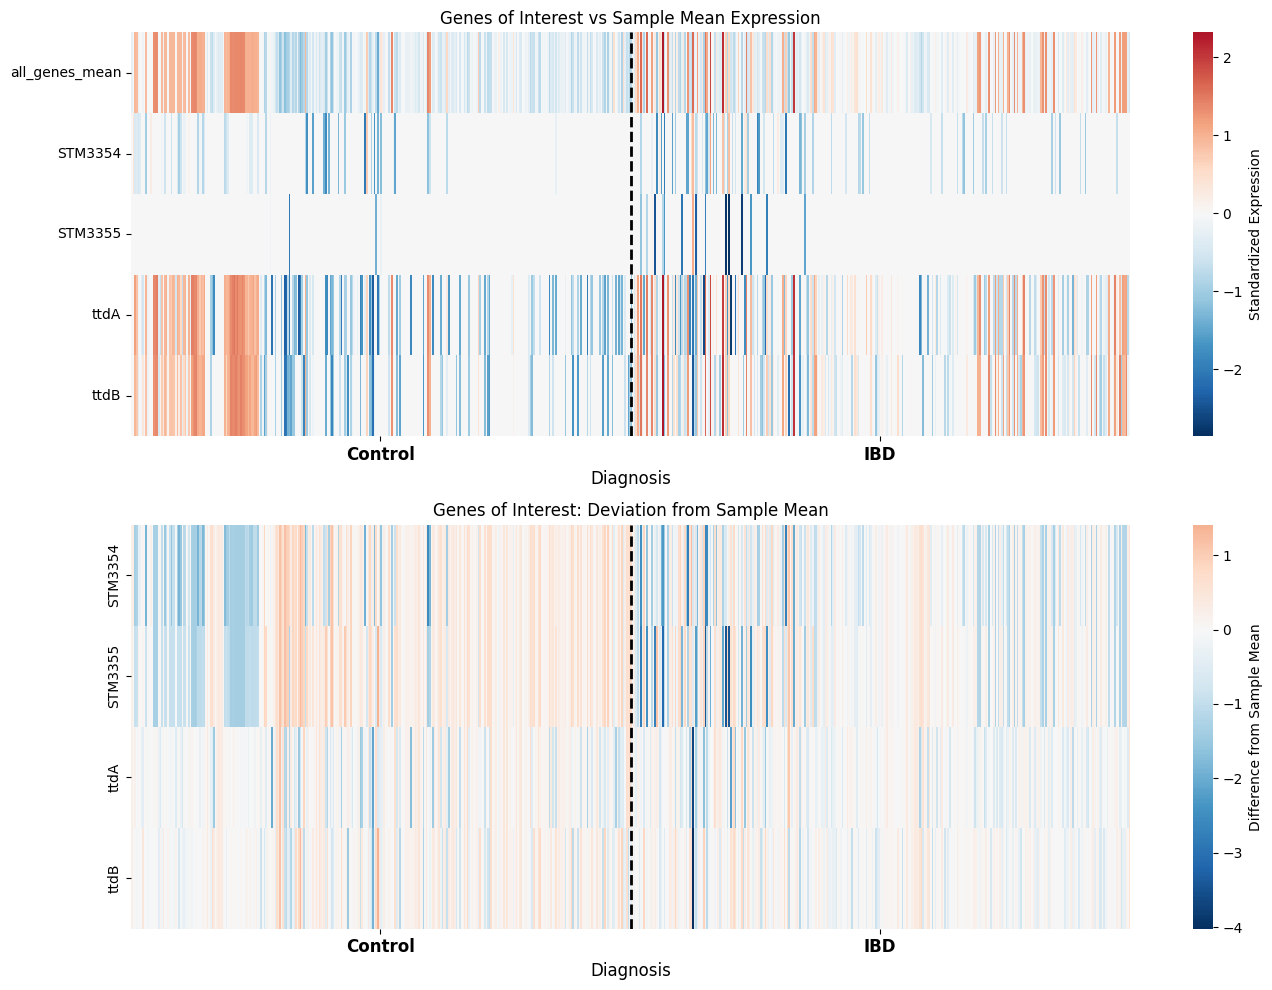


=== Summary Statistics by Diagnosis ===

STM3354:
           count     mean       std       min       25%       50%       75%  \
diagnosis                                                                     
Control    317.0 -0.03727  0.731739 -2.549783 -0.010782  0.123207  0.412365   
IBD        317.0 -0.21205  0.665069 -2.742046 -0.554206  0.023494  0.185396   

                max  
diagnosis            
Control    1.255028  
IBD        1.228200  

STM3355:
           count      mean       std       min       25%       50%       75%  \
diagnosis                                                                      
Control    317.0  0.057451  0.622476 -1.381149  0.024145  0.135570  0.440438   
IBD        317.0 -0.137892  0.745942 -3.458370 -0.195753  0.045548  0.252414   

                max  
diagnosis            
Control    1.408598  
IBD        1.113397  

ttdA:
           count     mean       std       min       25%       50%       75%  \
diagnosis                              

In [62]:
# Create visualization comparing genes of interest to sample means
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Gene values vs sample mean
plot_data = []
for sample in X_clean.index:
    sample_data = X_clean.loc[sample].dropna()
    sample_mean = sample_data.mean()
    
    row = {'sample': sample, 'diagnosis': y[sample], 'all_genes_mean': sample_mean}
    for gene in genes_of_interest:
        if gene in sample_data.index:
            row[gene] = sample_data[gene]
        else:
            row[gene] = np.nan
    plot_data.append(row)

plot_df = pd.DataFrame(plot_data).set_index('sample')

# Separate by diagnosis
diagnosis_col = plot_df['diagnosis']
plot_df = plot_df.drop('diagnosis', axis=1)

# Sort by diagnosis
plot_df['diagnosis'] = diagnosis_col
plot_df = plot_df.sort_values('diagnosis')
diagnosis_sorted = plot_df['diagnosis']
plot_df = plot_df.drop('diagnosis', axis=1)

# Create x-axis labels: show diagnosis only once per group
x_labels = []
current_diag = None
group_positions = []  # Store middle position of each group
group_names = []      # Store group names

for i, diag in enumerate(diagnosis_sorted):
    if diag != current_diag:
        if current_diag is not None:
            # Calculate middle position of previous group
            group_positions.append((group_start + i - 1) / 2)
            group_names.append(current_diag)
        group_start = i
        current_diag = diag
    x_labels.append('')

# Add the last group
if current_diag is not None:
    group_positions.append((group_start + len(diagnosis_sorted) - 1) / 2)
    group_names.append(current_diag)

# Heatmap 1
ax1 = axes[0]
sns.heatmap(plot_df.T, cmap='RdBu_r', center=0, 
            ax=ax1, cbar_kws={'label': 'Standardized Expression'},
            xticklabels=False, yticklabels=True)
ax1.set_ylabel('')
ax1.set_title('Genes of Interest vs Sample Mean Expression')

# Set custom x-axis with diagnosis labels at group centers
ax1.set_xticks(group_positions)
ax1.set_xticklabels(group_names, rotation=0, ha='center', fontsize=12, weight='bold')
ax1.set_xlabel('Diagnosis', fontsize=12)

# Add visual separator between diagnosis groups
current_diag = None
for i, diag in enumerate(diagnosis_sorted):
    if current_diag is not None and diag != current_diag:
        ax1.axvline(i, color='black', linewidth=2, linestyle='--')
    current_diag = diag

# Plot 2: Difference from mean
diff_data = plot_df.copy()
for col in genes_of_interest:
    if col in diff_data.columns:
        diff_data[col] = diff_data[col] - diff_data['all_genes_mean']

diff_data = diff_data.drop('all_genes_mean', axis=1)

ax2 = axes[1]
sns.heatmap(diff_data.T, cmap='RdBu_r', center=0, 
            ax=ax2, cbar_kws={'label': 'Difference from Sample Mean'},
            xticklabels=False, yticklabels=True)
ax2.set_ylabel('')
ax2.set_title('Genes of Interest: Deviation from Sample Mean')

# Set custom x-axis with diagnosis labels at group centers
ax2.set_xticks(group_positions)
ax2.set_xticklabels(group_names, rotation=0, ha='center', fontsize=12, weight='bold')
ax2.set_xlabel('Diagnosis', fontsize=12)

# Add visual separator between diagnosis groups
current_diag = None
for i, diag in enumerate(diagnosis_sorted):
    if current_diag is not None and diag != current_diag:
        ax2.axvline(i, color='black', linewidth=2, linestyle='--')
    current_diag = diag

plt.tight_layout()
plt.savefig('genes_of_interest_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics by diagnosis
print("\n=== Summary Statistics by Diagnosis ===")
for gene in genes_of_interest:
    if gene in diff_data.columns:
        print(f"\n{gene}:")
        summary_data = pd.DataFrame({
            'diagnosis': diagnosis_sorted.values,
            'difference_from_mean': diff_data[gene].values
        })
        print(summary_data.groupby('diagnosis')['difference_from_mean'].describe())

In [63]:
# For each gene of interest, test if it's significantly different from other genes
print("\n=== Statistical Tests: Genes of Interest vs All Other Genes ===\n")

for gene in genes_of_interest:
    if gene not in X_clean.columns:
        print(f"{gene}: Not found in data")
        continue
    
    gene_values = X_clean[gene].dropna()
    
    # For each sample with this gene, compare to all other genes
    comparisons = []
    for sample in gene_values.index:
        gene_val = gene_values[sample]
        other_genes = X_clean.loc[sample].drop(gene).dropna()
        
        if len(other_genes) > 0:
            # Test if this gene is significantly different from others
            t_stat, p_val = stats.ttest_1samp(other_genes, gene_val)
            comparisons.append({
                'sample': sample,
                'gene_value': gene_val,
                'other_mean': other_genes.mean(),
                'other_median': other_genes.median(),
                'difference': gene_val - other_genes.mean(),
                't_statistic': t_stat,
                'p_value': p_val
            })
    
    comp_df = pd.DataFrame(comparisons)
    
    print(f"\n{gene}:")
    print(f"  Present in {len(gene_values)} samples")
    print(f"  Mean difference from sample average: {comp_df['difference'].mean():.3f}")
    print(f"  Median difference from sample average: {comp_df['difference'].median():.3f}")
    print(f"  Significantly different (p<0.05) in {(comp_df['p_value'] < 0.05).sum()} samples")


=== Statistical Tests: Genes of Interest vs All Other Genes ===


STM3354:
  Present in 634 samples
  Mean difference from sample average: -0.128
  Median difference from sample average: 0.062
  Significantly different (p<0.05) in 469 samples

STM3355:
  Present in 634 samples
  Mean difference from sample average: -0.041
  Median difference from sample average: 0.086
  Significantly different (p<0.05) in 448 samples

ttdA:
  Present in 634 samples
  Mean difference from sample average: -0.087
  Median difference from sample average: 0.035
  Significantly different (p<0.05) in 370 samples

ttdB:
  Present in 634 samples
  Mean difference from sample average: 0.000
  Median difference from sample average: 0.044
  Significantly different (p<0.05) in 378 samples


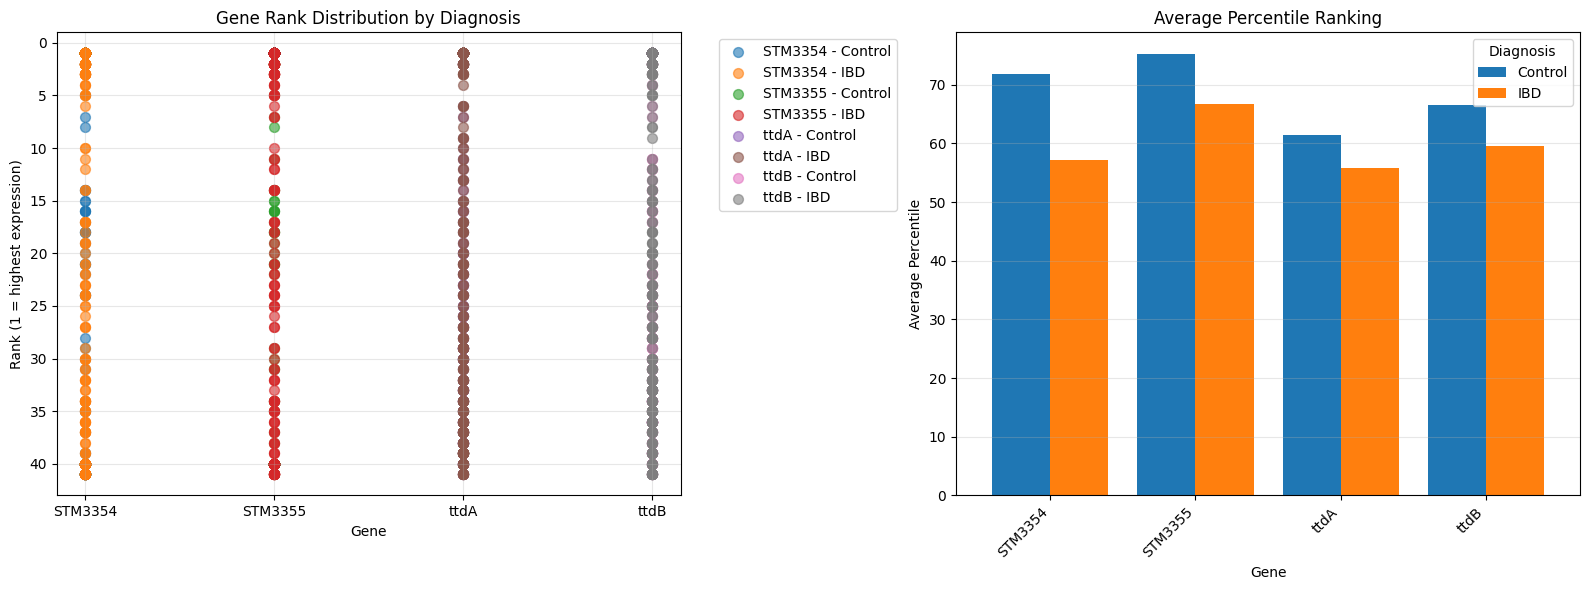


=== Average Rankings ===
                        rank  percentile
gene    diagnosis                       
STM3354 Control    11.583596   71.747326
        IBD        17.552050   57.190121
STM3355 Control    10.179811   75.171193
        IBD        13.621451   66.776949
ttdA    Control    15.823344   61.406478
        IBD        18.141956   55.751327
ttdB    Control    13.744479   66.476879
        IBD        16.561514   59.606063


In [64]:
# Show rank of genes of interest within each sample
rank_results = []

for sample in X_clean.index:
    sample_data = X_clean.loc[sample].dropna()
    
    # Rank all genes (1 = highest expression)
    ranks = sample_data.rank(ascending=False, method='min')
    
    for gene in genes_of_interest:
        if gene in ranks.index:
            rank_results.append({
                'sample': sample,
                'diagnosis': y[sample],
                'gene': gene,
                'value': sample_data[gene],
                'rank': int(ranks[gene]),
                'total_genes': len(sample_data),
                'percentile': (1 - ranks[gene] / len(sample_data)) * 100
            })

rank_df = pd.DataFrame(rank_results)

# Visualize rankings
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Rank distribution by diagnosis
for gene in genes_of_interest:
    gene_data = rank_df[rank_df['gene'] == gene]
    for diagnosis in y.unique():
        diag_data = gene_data[gene_data['diagnosis'] == diagnosis]
        if len(diag_data) > 0:
            axes[0].scatter([gene] * len(diag_data), diag_data['rank'], 
                          label=f'{gene} - {diagnosis}', alpha=0.6, s=50)

axes[0].set_ylabel('Rank (1 = highest expression)')
axes[0].set_xlabel('Gene')
axes[0].set_title('Gene Rank Distribution by Diagnosis')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)

# Plot 2: Average rank by gene and diagnosis
avg_ranks = rank_df.groupby(['gene', 'diagnosis'])['percentile'].mean().unstack()
avg_ranks.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_ylabel('Average Percentile')
axes[1].set_xlabel('Gene')
axes[1].set_title('Average Percentile Ranking')
axes[1].legend(title='Diagnosis')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('genes_of_interest_rankings.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Average Rankings ===")
print(rank_df.groupby(['gene', 'diagnosis'])[['rank', 'percentile']].mean())

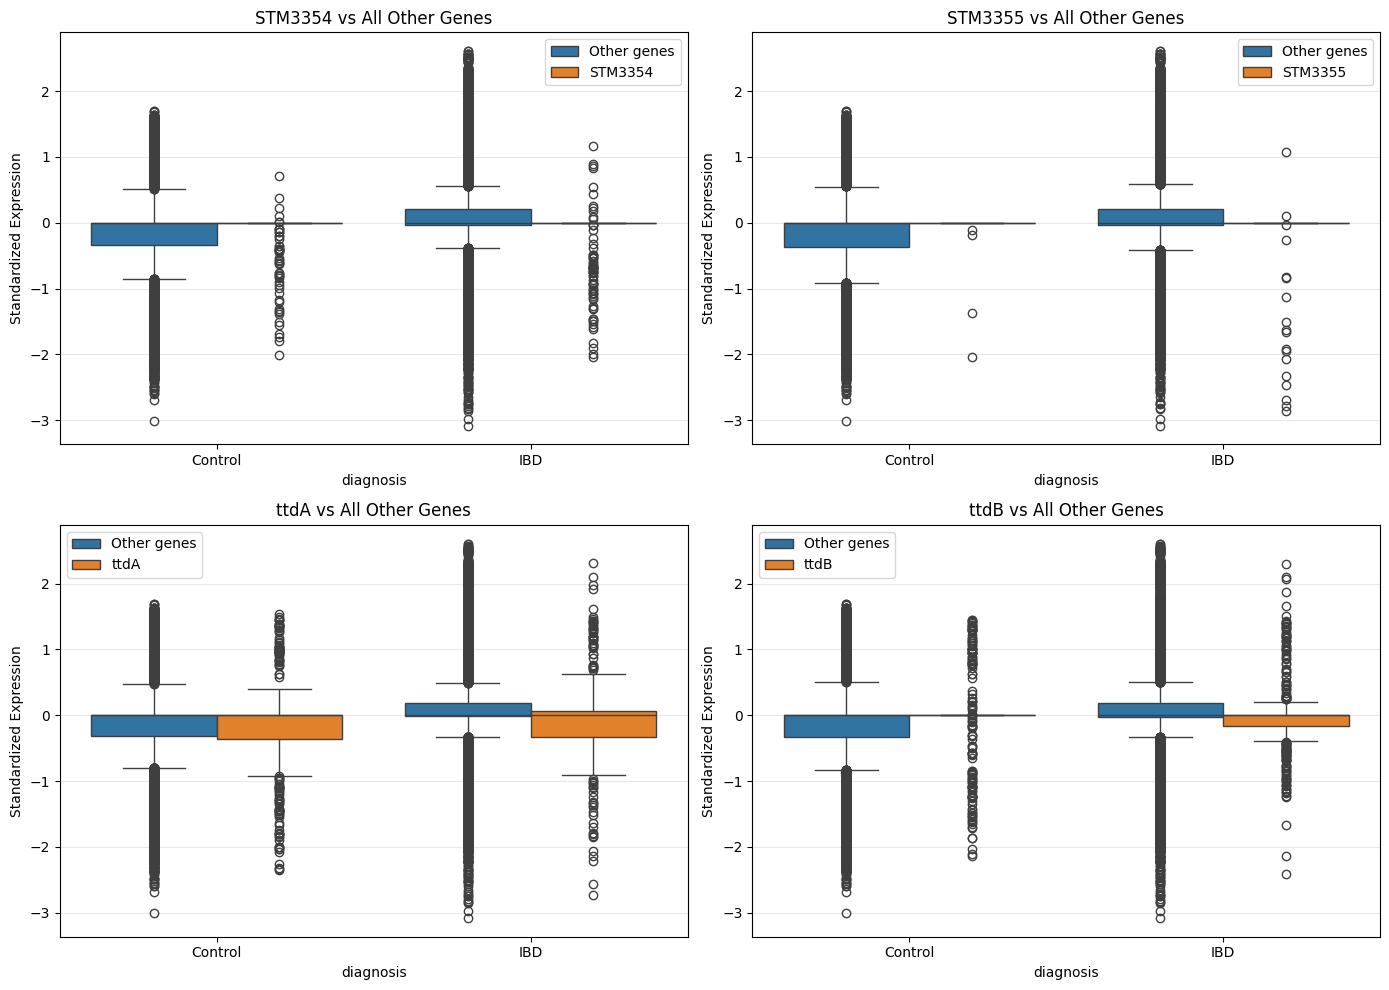

In [65]:
# Create box plots showing distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, gene in enumerate(genes_of_interest):
    if gene not in X_clean.columns:
        continue
    
    ax = axes[idx]
    
    # Prepare data for plotting
    plot_data = []
    for sample in X_clean.index:
        sample_data = X_clean.loc[sample].dropna()
        
        # All other genes
        other_genes = sample_data.drop(gene) if gene in sample_data.index else sample_data
        for val in other_genes.values:
            plot_data.append({
                'sample': sample,
                'diagnosis': y[sample],
                'type': 'Other genes',
                'value': val
            })
        
        # Gene of interest
        if gene in sample_data.index:
            plot_data.append({
                'sample': sample,
                'diagnosis': y[sample],
                'type': gene,
                'value': sample_data[gene]
            })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create box plot
    sns.boxplot(data=plot_df, x='diagnosis', y='value', hue='type', ax=ax)
    ax.set_title(f'{gene} vs All Other Genes')
    ax.set_ylabel('Standardized Expression')
    ax.legend(title='', loc='best')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('genes_of_interest_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

Analyzing genes: ['STM3354', 'STM3355', 'ttdA', 'ttdB']

=== Outlier Removal Summary ===
           n_outliers  outlier_percentage  mean_change
diagnosis                                             
Control      0.634069            3.180216     0.013029
IBD          0.810726            3.437379     0.013695

Total outliers removed: 458
Average outliers per sample: 0.72


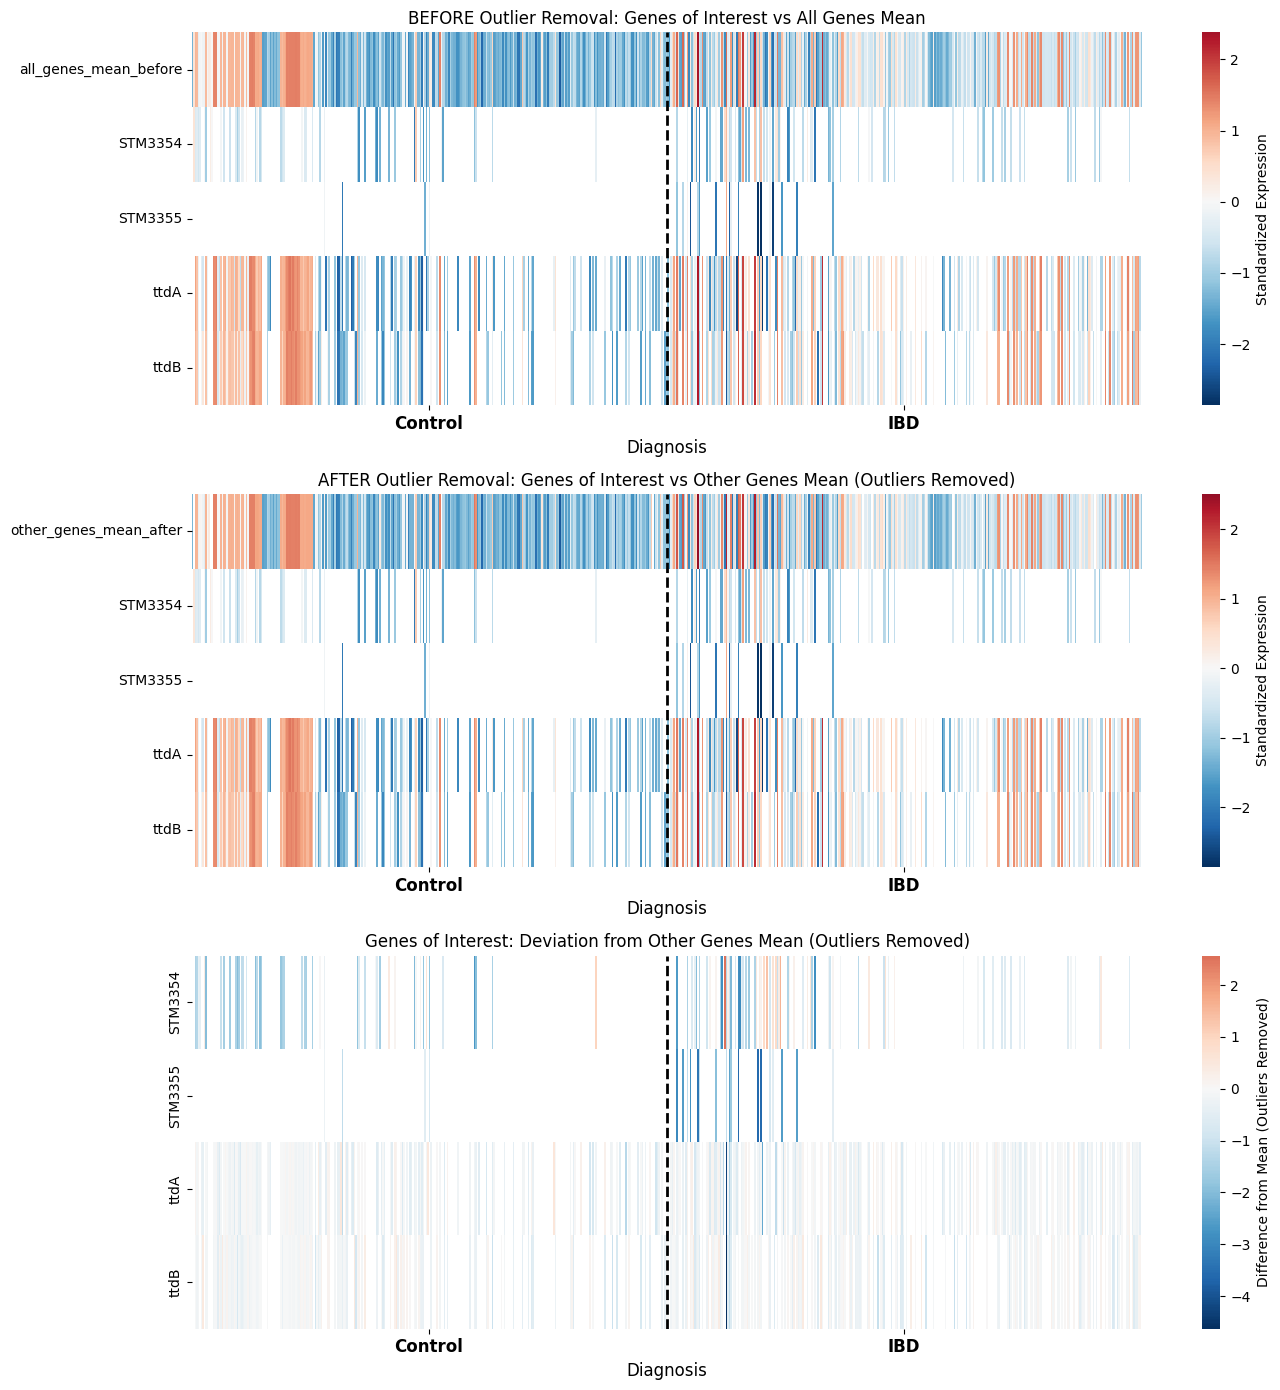


=== Summary Statistics by Diagnosis (After Outlier Removal) ===

STM3354:
           count      mean       std       min       25%       50%       75%  \
diagnosis                                                                      
Control     47.0 -1.081934  0.831687 -2.679414 -1.608825 -1.402360 -0.509681   
IBD         68.0 -0.531629  1.061769 -2.949690 -1.133326 -0.556798  0.175057   

                max  
diagnosis            
Control    1.015656  
IBD        2.566004  

STM3355:
           count      mean       std       min       25%       50%       75%  \
diagnosis                                                                      
Control      4.0 -0.681745  0.392137 -1.164652 -0.895273 -0.651948 -0.438420   
IBD         18.0 -2.152371  1.084885 -3.603080 -2.895535 -2.516590 -1.136022   

                max  
diagnosis            
Control   -0.258430  
IBD       -0.478491  

ttdA:
           count      mean       std       min       25%       50%       75%  \
diagnosis 

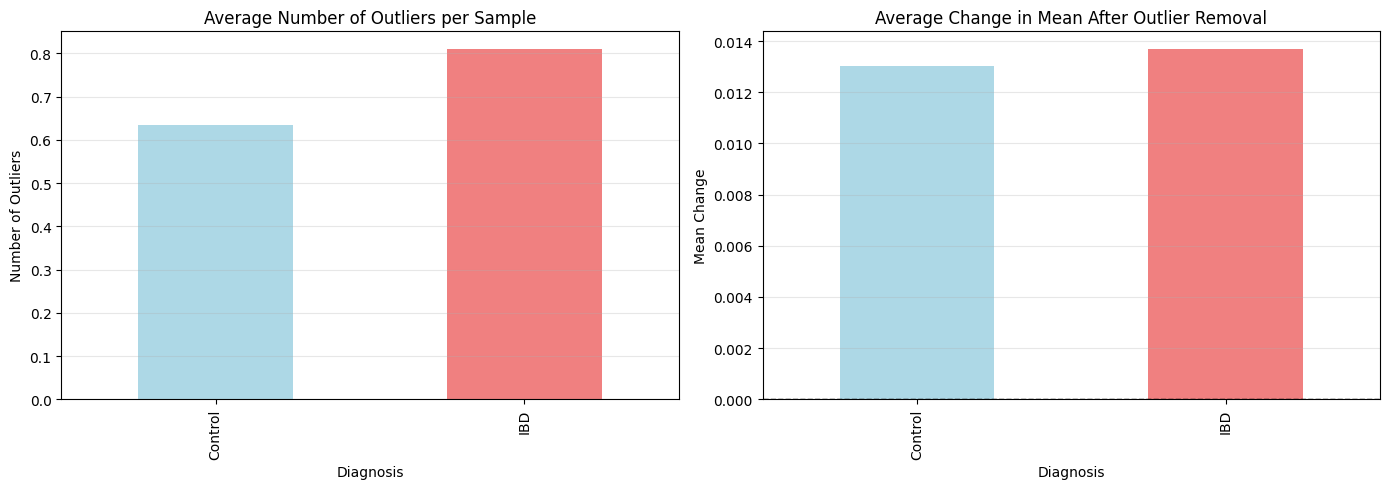

In [66]:
# Define your genes of interest
genes_of_interest = ['STM3354', 'STM3355', 'ttdA', 'ttdB']

# Filter to genes that exist in the data
genes_of_interest = [g for g in genes_of_interest if g in X.columns]

print(f"Analyzing genes: {genes_of_interest}")

# Function to remove outliers using IQR method
def remove_outliers_iqr(data, multiplier=1.5):
    """
    Remove outliers using IQR method
    multiplier: typically 1.5 for outliers, 3.0 for extreme outliers
    """
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    # Return data without outliers and outlier info
    mask = (data >= lower_bound) & (data <= upper_bound)
    return data[mask], lower_bound, upper_bound, (~mask).sum()

# Alternative: Z-score method
def remove_outliers_zscore(data, threshold=3):
    """
    Remove outliers using z-score method
    threshold: typically 3 (values beyond 3 standard deviations)
    """
    z_scores = np.abs(stats.zscore(data, nan_policy='omit'))
    mask = z_scores < threshold
    return data[mask], threshold, (~mask).sum()

# Create visualization comparing genes of interest to sample means (WITH OUTLIER REMOVAL)
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Plot 1: Gene values vs sample mean (BEFORE outlier removal)
plot_data_before = []
outlier_stats = []

for sample in X.index:
    sample_data = X.loc[sample].dropna()
    
    # Separate genes of interest from other genes
    other_genes = sample_data.drop([g for g in genes_of_interest if g in sample_data.index])
    
    # Calculate stats BEFORE outlier removal
    sample_mean_before = sample_data.mean()
    other_mean_before = other_genes.mean()
    
    # Remove outliers from "other genes"
    other_genes_clean, lower, upper, n_outliers = remove_outliers_iqr(other_genes, multiplier=1.5)
    
    # Calculate stats AFTER outlier removal
    other_mean_after = other_genes_clean.mean()
    sample_mean_after = pd.concat([other_genes_clean, 
                                   sample_data[[g for g in genes_of_interest if g in sample_data.index]]]).mean()
    
    outlier_stats.append({
        'sample': sample,
        'diagnosis': y[sample],
        'n_outliers': n_outliers,
        'total_other_genes': len(other_genes),
        'outlier_percentage': (n_outliers / len(other_genes) * 100) if len(other_genes) > 0 else 0,
        'mean_before': other_mean_before,
        'mean_after': other_mean_after,
        'mean_change': other_mean_after - other_mean_before
    })
    
    # Store data with outlier removal
    row = {
        'sample': sample, 
        'diagnosis': y[sample], 
        'all_genes_mean_before': sample_mean_before,
        'all_genes_mean_after': sample_mean_after,
        'other_genes_mean_after': other_mean_after
    }
    for gene in genes_of_interest:
        if gene in sample_data.index:
            row[gene] = sample_data[gene]
        else:
            row[gene] = np.nan
    plot_data_before.append(row)

outlier_df = pd.DataFrame(outlier_stats)
print("\n=== Outlier Removal Summary ===")
print(outlier_df.groupby('diagnosis')[['n_outliers', 'outlier_percentage', 'mean_change']].mean())
print(f"\nTotal outliers removed: {outlier_df['n_outliers'].sum()}")
print(f"Average outliers per sample: {outlier_df['n_outliers'].mean():.2f}")

plot_df = pd.DataFrame(plot_data_before).set_index('sample')

# Separate by diagnosis
diagnosis_col = plot_df['diagnosis']
plot_df_values = plot_df.drop('diagnosis', axis=1)

# Sort by diagnosis
plot_df_values['diagnosis'] = diagnosis_col
plot_df_values = plot_df_values.sort_values('diagnosis')
diagnosis_sorted = plot_df_values['diagnosis']
plot_df_values = plot_df_values.drop('diagnosis', axis=1)

# Create x-axis labels: show diagnosis only once per group
x_labels = []
current_diag = None
group_positions = []
group_names = []

for i, diag in enumerate(diagnosis_sorted):
    if diag != current_diag:
        if current_diag is not None:
            group_positions.append((group_start + i - 1) / 2)
            group_names.append(current_diag)
        group_start = i
        current_diag = diag
    x_labels.append('')

if current_diag is not None:
    group_positions.append((group_start + len(diagnosis_sorted) - 1) / 2)
    group_names.append(current_diag)

# Plot 1: Before outlier removal
ax1 = axes[0]
plot_before = plot_df_values[['all_genes_mean_before'] + genes_of_interest]
sns.heatmap(plot_before.T, cmap='RdBu_r', center=0, 
            ax=ax1, cbar_kws={'label': 'Standardized Expression'},
            xticklabels=False, yticklabels=True)
ax1.set_ylabel('')
ax1.set_title('BEFORE Outlier Removal: Genes of Interest vs All Genes Mean')
ax1.set_xticks(group_positions)
ax1.set_xticklabels(group_names, rotation=0, ha='center', fontsize=12, weight='bold')
ax1.set_xlabel('Diagnosis', fontsize=12)

current_diag = None
for i, diag in enumerate(diagnosis_sorted):
    if current_diag is not None and diag != current_diag:
        ax1.axvline(i, color='black', linewidth=2, linestyle='--')
    current_diag = diag

# Plot 2: After outlier removal
ax2 = axes[1]
plot_after = plot_df_values[['other_genes_mean_after'] + genes_of_interest]
sns.heatmap(plot_after.T, cmap='RdBu_r', center=0, 
            ax=ax2, cbar_kws={'label': 'Standardized Expression'},
            xticklabels=False, yticklabels=True)
ax2.set_ylabel('')
ax2.set_title('AFTER Outlier Removal: Genes of Interest vs Other Genes Mean (Outliers Removed)')
ax2.set_xticks(group_positions)
ax2.set_xticklabels(group_names, rotation=0, ha='center', fontsize=12, weight='bold')
ax2.set_xlabel('Diagnosis', fontsize=12)

current_diag = None
for i, diag in enumerate(diagnosis_sorted):
    if current_diag is not None and diag != current_diag:
        ax2.axvline(i, color='black', linewidth=2, linestyle='--')
    current_diag = diag

# Plot 3: Difference from mean (AFTER outlier removal)
diff_data = plot_df_values[genes_of_interest].copy()
for col in genes_of_interest:
    if col in diff_data.columns:
        diff_data[col] = diff_data[col] - plot_df_values['other_genes_mean_after']

ax3 = axes[2]
sns.heatmap(diff_data.T, cmap='RdBu_r', center=0, 
            ax=ax3, cbar_kws={'label': 'Difference from Mean (Outliers Removed)'},
            xticklabels=False, yticklabels=True)
ax3.set_ylabel('')
ax3.set_title('Genes of Interest: Deviation from Other Genes Mean (Outliers Removed)')
ax3.set_xticks(group_positions)
ax3.set_xticklabels(group_names, rotation=0, ha='center', fontsize=12, weight='bold')
ax3.set_xlabel('Diagnosis', fontsize=12)

current_diag = None
for i, diag in enumerate(diagnosis_sorted):
    if current_diag is not None and diag != current_diag:
        ax3.axvline(i, color='black', linewidth=2, linestyle='--')
    current_diag = diag

plt.tight_layout()
plt.savefig('genes_of_interest_heatmap_outliers_removed.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed summary statistics by diagnosis
print("\n=== Summary Statistics by Diagnosis (After Outlier Removal) ===")
for gene in genes_of_interest:
    if gene in diff_data.columns:
        print(f"\n{gene}:")
        summary_data = pd.DataFrame({
            'diagnosis': diagnosis_sorted.values,
            'difference_from_mean': diff_data[gene].values
        })
        print(summary_data.groupby('diagnosis')['difference_from_mean'].describe())

# Save outlier statistics
outlier_df.to_csv('outlier_removal_stats.csv', index=False)
print("\nOutlier statistics saved to 'outlier_removal_stats.csv'")

# Visualize outlier distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot outlier counts by diagnosis
outlier_df.groupby('diagnosis')['n_outliers'].mean().plot(kind='bar', ax=axes[0], color=['lightblue', 'lightcoral'])
axes[0].set_title('Average Number of Outliers per Sample')
axes[0].set_ylabel('Number of Outliers')
axes[0].set_xlabel('Diagnosis')
axes[0].grid(True, alpha=0.3, axis='y')

# Plot mean change due to outlier removal
outlier_df.groupby('diagnosis')['mean_change'].mean().plot(kind='bar', ax=axes[1], color=['lightblue', 'lightcoral'])
axes[1].set_title('Average Change in Mean After Outlier Removal')
axes[1].set_ylabel('Mean Change')
axes[1].set_xlabel('Diagnosis')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outlier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [67]:
def find_outlier_genes_rowwise(df, threshold=3.5):
    outliers = {}

    for run, row in df.iterrows():
        values = row.dropna()
        if len(values) < 3:
            continue

        median = values.median()
        mad = np.median(np.abs(values - median))

        if mad == 0:
            continue

        robust_z = 0.6745 * (values - median) / mad
        bad = robust_z.abs() > threshold

        if bad.any():
            outliers[run] = values[bad].sort_values()

    return outliers

In [68]:
outliers = find_outlier_genes_rowwise(X)

outlier_genes = set()
for run, genes in outliers.items():
    print(run)
    print(genes)
    print()
    outlier_genes.update(genes.index)

#print(outlier_genes)

ERR011087
gene_name
rpsA   -2.162782
rpsO   -0.836014
Name: ERR011087, dtype: float64

ERR011103
gene_name
rpsQ   -0.971016
Name: ERR011103, dtype: float64

ERR011107
gene_name
pheS   -0.673162
rpmC   -0.542558
Name: ERR011107, dtype: float64

ERR011108
gene_name
pheS   -0.761161
pheT   -0.461468
Name: ERR011108, dtype: float64

ERR011118
gene_name
pheT   -1.939767
Name: ERR011118, dtype: float64

ERR011123
gene_name
ttdA   -2.008961
Name: ERR011123, dtype: float64

ERR011126
gene_name
STM3354   -1.168635
Name: ERR011126, dtype: float64

ERR011127
gene_name
STM3354   -0.615185
ttdB       0.999541
ttdA       1.019651
pheT       1.019826
Name: ERR011127, dtype: float64

ERR011128
gene_name
STM3354   -0.765320
ttdB      -0.308480
rnhB      -0.168158
Name: ERR011128, dtype: float64

ERR011150
gene_name
ttdB    0.363962
Name: ERR011150, dtype: float64

ERR011154
gene_name
pheT   -2.111286
Name: ERR011154, dtype: float64

ERR011156
gene_name
pheS   -1.453958
pheT   -0.793402
rpsL   -0.462719

In [69]:
dataframe_outliers = ['infB','rpsA','pheT','rpsC','rpsB','rplA','pheS','rplB','rplN','rpsM']

Analyzing genes: ['STM3354', 'STM3355', 'ttdA', 'ttdB']
Removing outlier genes from all_genes: {'rpsK', 'rpsH', 'rpmC', 'rplA', 'truB', 'STM3354', 'hemC', 'rplC', 'rplF', 'pheS', 'rpsA', 'rnhB', 'ttdA', 'rpsB', 'rplR', 'rpsS', 'rplP', 'rplX', 'rpsJ', 'rpsI', 'rplD', 'rplM', 'rplY', 'rpsG', 'rpsL', 'rplK', 'ttdB', 'rpsQ', 'rpsC', 'pheT', 'rpsE', 'STM3355', 'rplN', 'infB', 'rplO', 'rplB', 'rpsM', 'rplV', 'rpsO'}

=== Outlier Removal Summary ===
           n_outliers  outlier_percentage  mean_change
diagnosis                                             
Control           0.0                 0.0          0.0
IBD               0.0                 0.0          0.0

Total outliers removed: 0
Average outliers per sample: 0.00


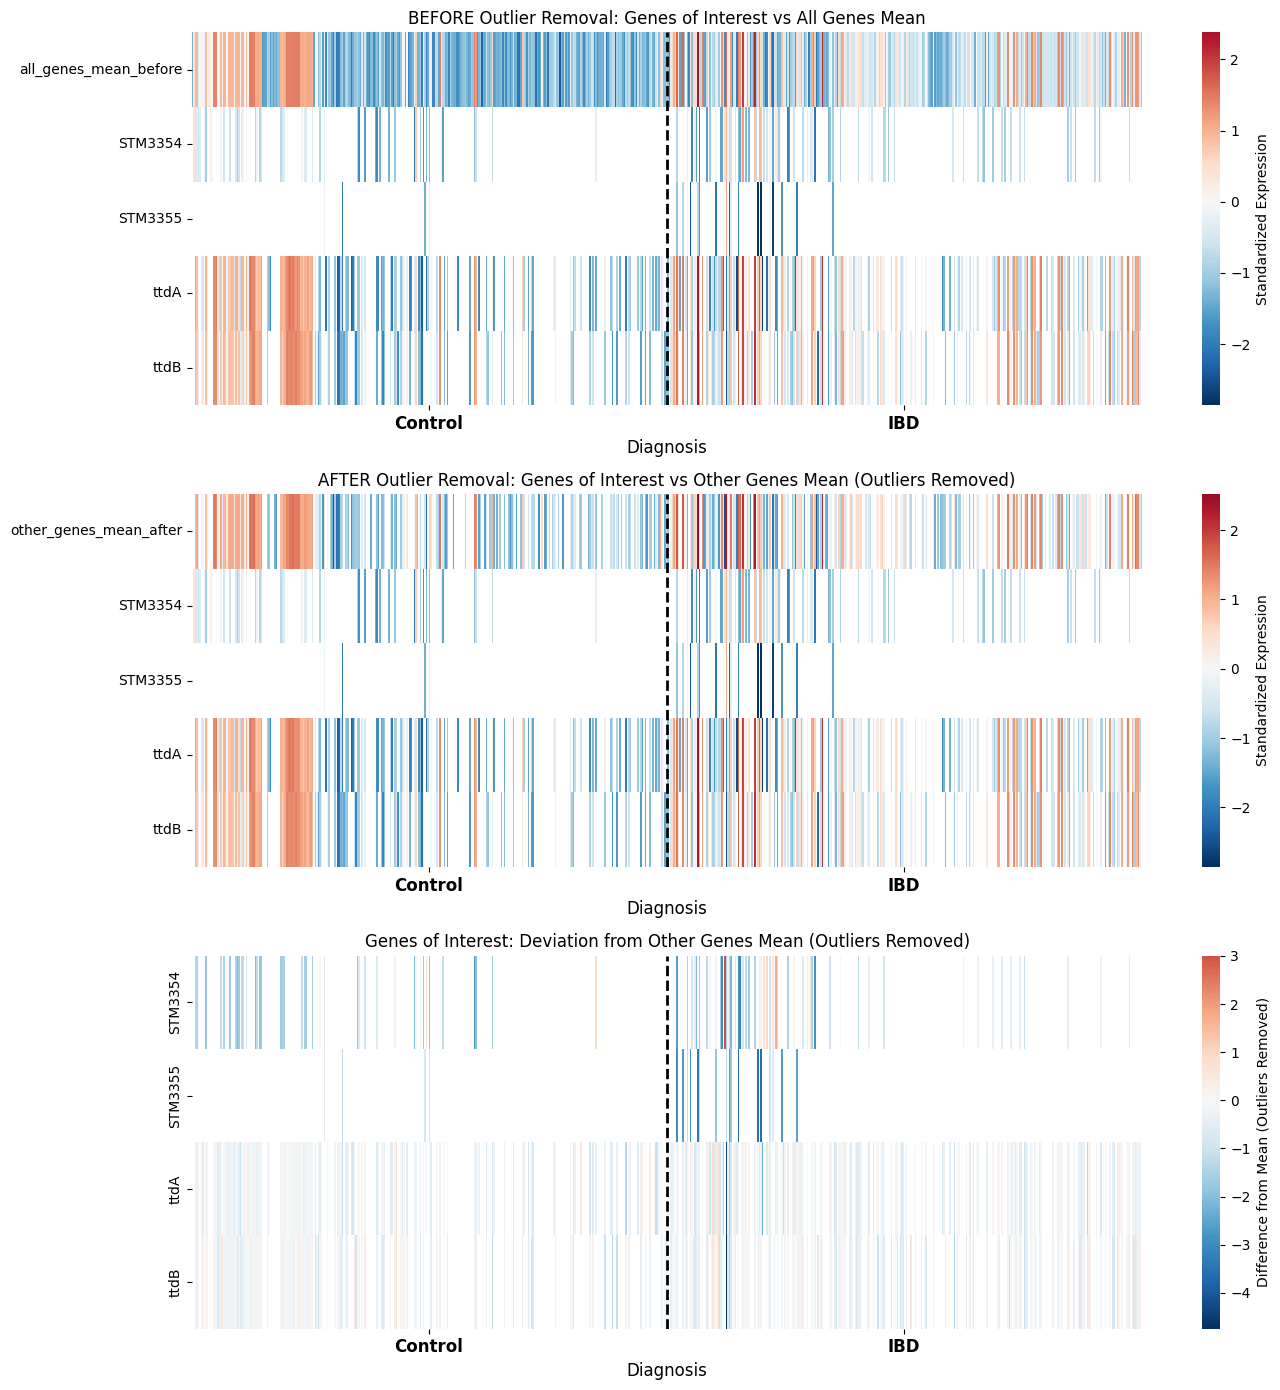


=== Summary Statistics by Diagnosis (After Outlier Removal) ===

STM3354:
           count      mean       std       min       25%       50%       75%  \
diagnosis                                                                      
Control     42.0 -1.218784  0.780528 -2.656700 -1.705699 -1.487175 -0.934079   
IBD         54.0 -0.711315  1.154051 -3.058596 -1.433809 -0.719447  0.073989   

                max  
diagnosis            
Control    0.872628  
IBD        3.003934  

STM3355:
           count      mean       std       min       25%       50%       75%  \
diagnosis                                                                      
Control      4.0 -0.839119  0.309914 -1.227321 -0.958933 -0.827859 -0.708045   
IBD         17.0 -2.304749  1.008445 -3.635944 -2.917218 -2.625587 -1.257577   

                max  
diagnosis            
Control   -0.473438  
IBD       -0.634466  

ttdA:
           count      mean       std       min       25%       50%       75%  \
diagnosis 

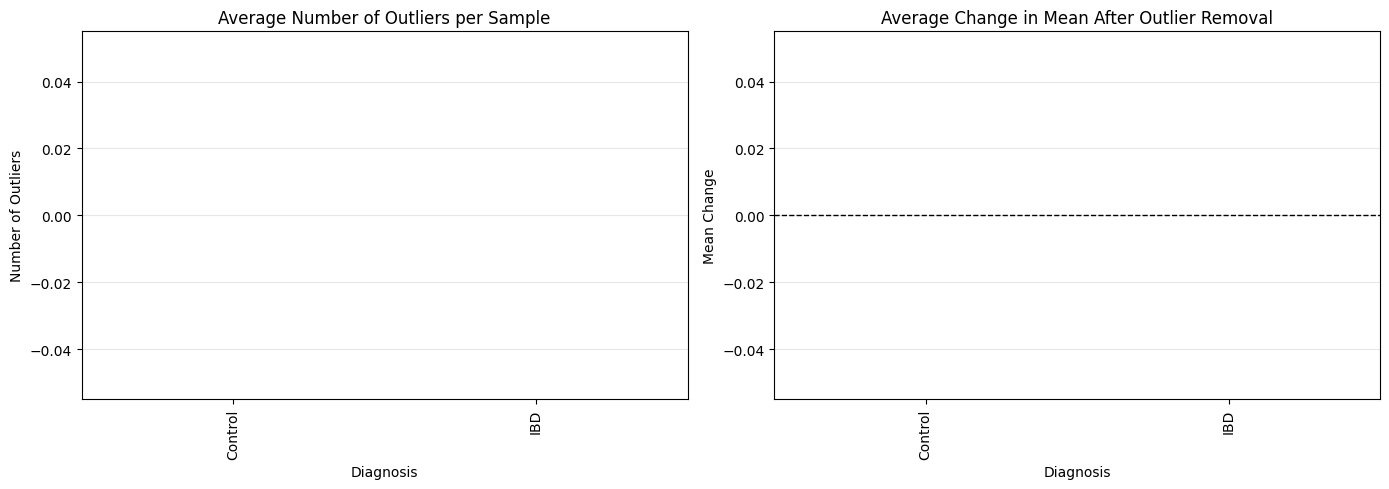

In [70]:
# Define your genes of interest
genes_of_interest = ['STM3354', 'STM3355', 'ttdA', 'ttdB']

# Filter to genes that exist in the data
genes_of_interest = [g for g in genes_of_interest if g in X.columns]

print(f"Analyzing genes: {genes_of_interest}")
print(f"Removing outlier genes from all_genes: {outlier_genes}")

# Function to remove outliers using IQR method
def remove_outliers_iqr(data, multiplier=1.5):
    """
    Remove outliers using IQR method
    multiplier: typically 1.5 for outliers, 3.0 for extreme outliers
    """
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    # Return data without outliers and outlier info
    mask = (data >= lower_bound) & (data <= upper_bound)
    return data[mask], lower_bound, upper_bound, (~mask).sum()

# Alternative: Z-score method
def remove_outliers_zscore(data, threshold=3):
    """
    Remove outliers using z-score method
    threshold: typically 3 (values beyond 3 standard deviations)
    """
    z_scores = np.abs(stats.zscore(data, nan_policy='omit'))
    mask = z_scores < threshold
    return data[mask], threshold, (~mask).sum()

# Create visualization comparing genes of interest to sample means (WITH OUTLIER REMOVAL)
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Plot 1: Gene values vs sample mean (BEFORE outlier removal)
plot_data_before = []
outlier_stats = []

for sample in X.index:
    sample_data = X.loc[sample].dropna()
    
    # Separate genes of interest from other genes
    other_genes = sample_data.drop([g for g in outlier_genes if g in sample_data.index])
    #print(other_genes)
    
    # Calculate stats BEFORE outlier removal
    sample_mean_before = sample_data.mean()
    other_mean_before = other_genes.mean()
    
    # Remove outliers from "other genes"
    other_genes_clean, lower, upper, n_outliers = remove_outliers_iqr(other_genes, multiplier=1.5)
    
    # Calculate stats AFTER outlier removal
    other_mean_after = other_genes_clean.mean()
    sample_mean_after = pd.concat([other_genes_clean, 
                                   sample_data[[g for g in outlier_genes if g in sample_data.index]]]).mean()
    
    outlier_stats.append({
        'sample': sample,
        'diagnosis': y[sample],
        'n_outliers': n_outliers,
        'total_other_genes': len(other_genes),
        'outlier_percentage': (n_outliers / len(other_genes) * 100) if len(other_genes) > 0 else 0,
        'mean_before': other_mean_before,
        'mean_after': other_mean_after,
        'mean_change': other_mean_after - other_mean_before
    })
    
    # Store data with outlier removal
    row = {
        'sample': sample, 
        'diagnosis': y[sample], 
        'all_genes_mean_before': sample_mean_before,
        'all_genes_mean_after': sample_mean_after,
        'other_genes_mean_after': other_mean_after
    }
    for gene in genes_of_interest:
        if gene in sample_data.index:
            row[gene] = sample_data[gene]
        else:
            row[gene] = np.nan
    plot_data_before.append(row)

outlier_df = pd.DataFrame(outlier_stats)
print("\n=== Outlier Removal Summary ===")
print(outlier_df.groupby('diagnosis')[['n_outliers', 'outlier_percentage', 'mean_change']].mean())
print(f"\nTotal outliers removed: {outlier_df['n_outliers'].sum()}")
print(f"Average outliers per sample: {outlier_df['n_outliers'].mean():.2f}")

plot_df = pd.DataFrame(plot_data_before).set_index('sample')

# Separate by diagnosis
diagnosis_col = plot_df['diagnosis']
plot_df_values = plot_df.drop('diagnosis', axis=1)

# Sort by diagnosis
plot_df_values['diagnosis'] = diagnosis_col
plot_df_values = plot_df_values.sort_values('diagnosis')
diagnosis_sorted = plot_df_values['diagnosis']
plot_df_values = plot_df_values.drop('diagnosis', axis=1)

# Create x-axis labels: show diagnosis only once per group
x_labels = []
current_diag = None
group_positions = []
group_names = []

for i, diag in enumerate(diagnosis_sorted):
    if diag != current_diag:
        if current_diag is not None:
            group_positions.append((group_start + i - 1) / 2)
            group_names.append(current_diag)
        group_start = i
        current_diag = diag
    x_labels.append('')

if current_diag is not None:
    group_positions.append((group_start + len(diagnosis_sorted) - 1) / 2)
    group_names.append(current_diag)

# Plot 1: Before outlier removal
ax1 = axes[0]
plot_before = plot_df_values[['all_genes_mean_before'] + genes_of_interest]
sns.heatmap(plot_before.T, cmap='RdBu_r', center=0, 
            ax=ax1, cbar_kws={'label': 'Standardized Expression'},
            xticklabels=False, yticklabels=True)
ax1.set_ylabel('')
ax1.set_title('BEFORE Outlier Removal: Genes of Interest vs All Genes Mean')
ax1.set_xticks(group_positions)
ax1.set_xticklabels(group_names, rotation=0, ha='center', fontsize=12, weight='bold')
ax1.set_xlabel('Diagnosis', fontsize=12)

current_diag = None
for i, diag in enumerate(diagnosis_sorted):
    if current_diag is not None and diag != current_diag:
        ax1.axvline(i, color='black', linewidth=2, linestyle='--')
    current_diag = diag

# Plot 2: After outlier removal
ax2 = axes[1]
plot_after = plot_df_values[['other_genes_mean_after'] + genes_of_interest]
sns.heatmap(plot_after.T, cmap='RdBu_r', center=0, 
            ax=ax2, cbar_kws={'label': 'Standardized Expression'},
            xticklabels=False, yticklabels=True)
ax2.set_ylabel('')
ax2.set_title('AFTER Outlier Removal: Genes of Interest vs Other Genes Mean (Outliers Removed)')
ax2.set_xticks(group_positions)
ax2.set_xticklabels(group_names, rotation=0, ha='center', fontsize=12, weight='bold')
ax2.set_xlabel('Diagnosis', fontsize=12)

current_diag = None
for i, diag in enumerate(diagnosis_sorted):
    if current_diag is not None and diag != current_diag:
        ax2.axvline(i, color='black', linewidth=2, linestyle='--')
    current_diag = diag

# Plot 3: Difference from mean (AFTER outlier removal)
diff_data = plot_df_values[genes_of_interest].copy()
for col in genes_of_interest:
    if col in diff_data.columns:
        diff_data[col] = diff_data[col] - plot_df_values['other_genes_mean_after']

ax3 = axes[2]
sns.heatmap(diff_data.T, cmap='RdBu_r', center=0, 
            ax=ax3, cbar_kws={'label': 'Difference from Mean (Outliers Removed)'},
            xticklabels=False, yticklabels=True)
ax3.set_ylabel('')
ax3.set_title('Genes of Interest: Deviation from Other Genes Mean (Outliers Removed)')
ax3.set_xticks(group_positions)
ax3.set_xticklabels(group_names, rotation=0, ha='center', fontsize=12, weight='bold')
ax3.set_xlabel('Diagnosis', fontsize=12)

current_diag = None
for i, diag in enumerate(diagnosis_sorted):
    if current_diag is not None and diag != current_diag:
        ax3.axvline(i, color='black', linewidth=2, linestyle='--')
    current_diag = diag

plt.tight_layout()
plt.savefig('genes_of_interest_heatmap_outliers_removed.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Summary Statistics by Diagnosis (After Outlier Removal) ===")
for gene in genes_of_interest:
    if gene in diff_data.columns:
        print(f"\n{gene}:")
        summary_data = pd.DataFrame({
            'diagnosis': diagnosis_sorted.values,
            'difference_from_mean': diff_data[gene].values
        })
        print(summary_data.groupby('diagnosis')['difference_from_mean'].describe())

outlier_df.to_csv('outlier_removal_stats.csv', index=False)
print("\nOutlier statistics saved to 'outlier_removal_stats.csv'")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

outlier_df.groupby('diagnosis')['n_outliers'].mean().plot(kind='bar', ax=axes[0], color=['lightblue', 'lightcoral'])
axes[0].set_title('Average Number of Outliers per Sample')
axes[0].set_ylabel('Number of Outliers')
axes[0].set_xlabel('Diagnosis')
axes[0].grid(True, alpha=0.3, axis='y')

outlier_df.groupby('diagnosis')['mean_change'].mean().plot(kind='bar', ax=axes[1], color=['lightblue', 'lightcoral'])
axes[1].set_title('Average Change in Mean After Outlier Removal')
axes[1].set_ylabel('Mean Change')
axes[1].set_xlabel('Diagnosis')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outlier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

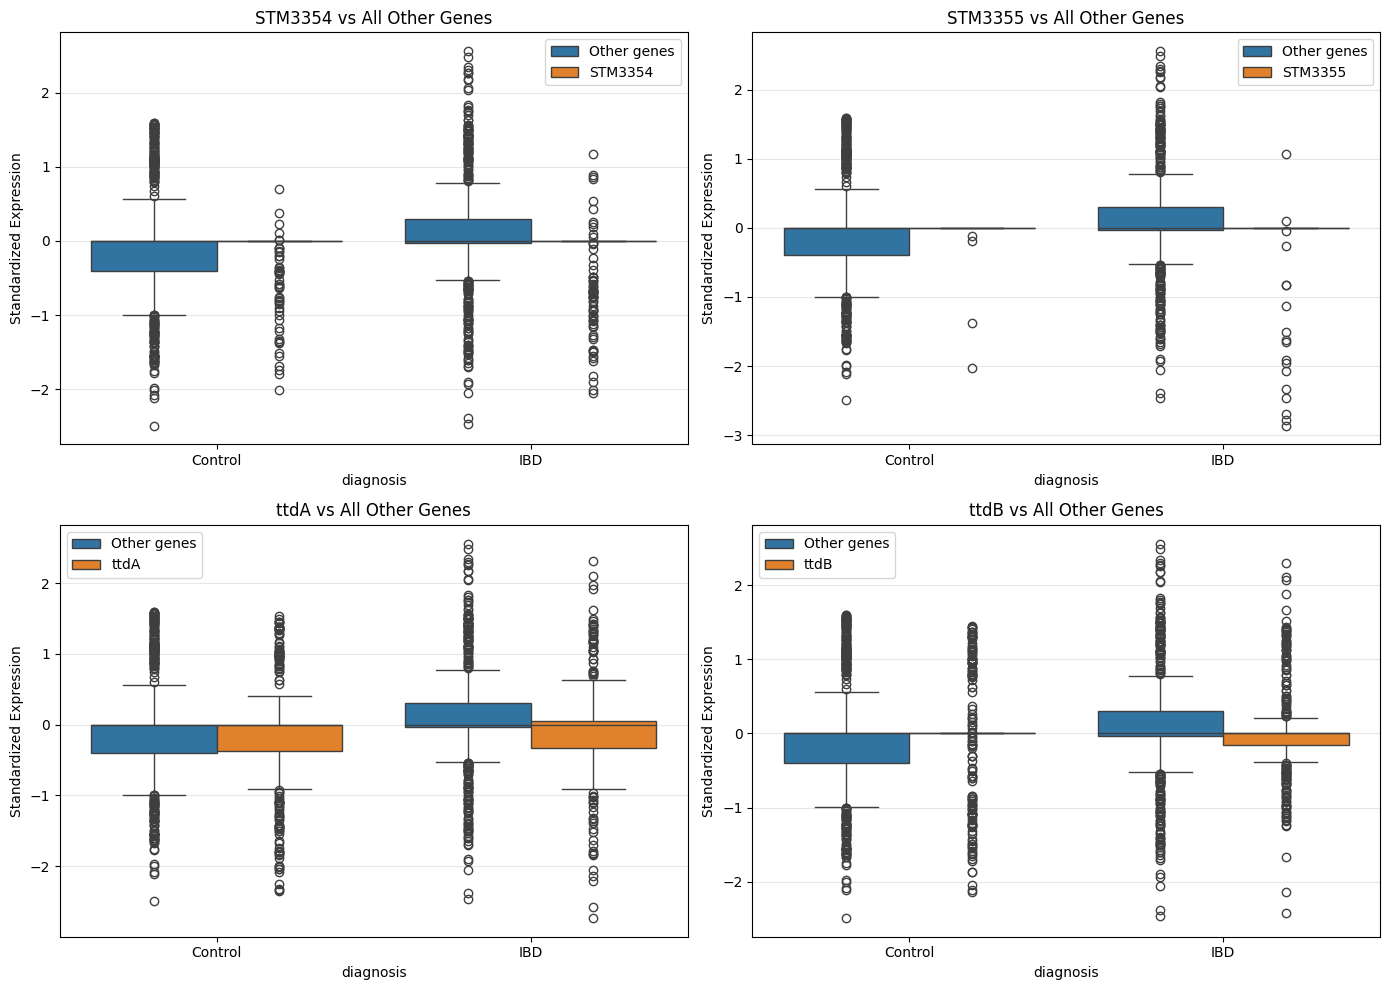

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, gene in enumerate(genes_of_interest):
    if gene not in X_clean.columns:
        continue
    
    ax = axes[idx]
    
    plot_data = []
    for sample in X_clean.index:
        sample_data = X_clean.loc[sample].dropna()
        
#        other_genes = sample_data.drop(gene) if gene in sample_data.index else sample_data
        other_genes = sample_data.drop([g for g in outlier_genes if g in sample_data.index])

        for val in other_genes.values:
            plot_data.append({
                'sample': sample,
                'diagnosis': y[sample],
                'type': 'Other genes',
                'value': val
            })
        
        # Gene of interest
        if gene in sample_data.index:
            plot_data.append({
                'sample': sample,
                'diagnosis': y[sample],
                'type': gene,
                'value': sample_data[gene]
            })
    
    plot_df = pd.DataFrame(plot_data)
    
    sns.boxplot(data=plot_df, x='diagnosis', y='value', hue='type', ax=ax)
    ax.set_title(f'{gene} vs All Other Genes')
    ax.set_ylabel('Standardized Expression')
    ax.legend(title='', loc='best')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('genes_of_interest_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()